# **Week 2 — ICS-Flow Dataset Exploration & Network Graph Construction**

**Project:** Graph-Based Risk Assessment for Cyber-Physical Systems   
**Dataset:** ICS-Flow — Anomaly Detection Dataset for Industrial Control Systems (Dehlaghi-Ghadim et al., IEEE Access, 2023)    


## **1. Setup and Dataset Download**

Downloads the ICS-Flow dataset from Kaggle.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alirezadehlaghi/icssim")
print("Path to dataset files:", path)

100%|██████████| 443M/443M [00:05<00:00, 82.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alirezadehlaghi/icssim/versions/2


## **2. Inspect Downloaded Files**

Lists every file in the downloaded dataset folder so we can confirm what is available (network flows, PLC snapshots, raw PCAP, etc.) before deciding what to use this week.

In [2]:
import os

for root, dirs, files in os.walk(path):
    print("\nFolder:", root)
    for file in files:
        print(file)


Folder: /root/.cache/kagglehub/datasets/alirezadehlaghi/icssim/versions/2
attacker_machine_summary.csv
attacker_summary.csv
snapshots_PLC1.csv
Dataset.csv
snapshots_PLC2.csv
traffic.pcap


**Decision for Week 2:** use only `Dataset.csv` — already in CSV format, easy to load with pandas, and sufficient for exploratory analysis and an initial graph. `attacker_summary.csv`, `attacker_machine_summary.csv`, the PLC snapshot files, and `traffic.pcap` are left for later weeks (attack-path analysis and knowledge-graph enrichment).

## **3. Load `Dataset.csv`**



Loads the main flow-record file and inspects its shape, columns, and first rows.

In [3]:
import pandas as pd

df = pd.read_csv(f"{path}/Dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(45718, 64)
Index(['sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs', 'protocol',
       'startDate', 'endDate', 'start', 'end', 'startOffset', 'endOffset',
       'duration', 'sPackets', 'rPackets', 'sBytesSum', 'rBytesSum',
       'sBytesMax', 'rBytesMax', 'sBytesMin', 'rBytesMin', 'sBytesAvg',
       'rBytesAvg', 'sLoad', 'rLoad', 'sPayloadSum', 'rPayloadSum',
       'sPayloadMax', 'rPayloadMax', 'sPayloadMin', 'rPayloadMin',
       'sPayloadAvg', 'rPayloadAvg', 'sInterPacketAvg', 'rInterPacketAvg',
       'sttl', 'rttl', 'sAckRate', 'rAckRate', 'sUrgRate', 'rUrgRate',
       'sFinRate', 'rFinRate', 'sPshRate', 'rPshRate', 'sSynRate', 'rSynRate',
       'sRstRate', 'rRstRate', 'sWinTCP', 'rWinTCP', 'sFragmentRate',
       'rFragmentRate', 'sAckDelayMax', 'rAckDelayMax', 'sAckDelayMin',
       'rAckDelayMin', 'sAckDelayAvg', 'rAckDelayAvg', 'IT_B_Label',
       'IT_M_Label', 'NST_B_Label', 'NST_M_Label'],
      dtype='object')


,sAddress,rAddress,sMACs,rMACs,sIPs,rIPs,protocol,startDate,endDate,start,...,sAckDelayMax,rAckDelayMax,sAckDelayMin,rAckDelayMin,sAckDelayAvg,rAckDelayAvg,IT_B_Label,IT_M_Label,NST_B_Label,NST_M_Label
0,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.510337,2022-09-16 11:14:40.010330,1.663320e+09,...,0.001,0.497,0.0,0.0,0.000219,0.031154,0,Normal,0,Normal
1,192.168.0.12,192.168.0.21,02:42:c0:a8:00:0c,02:42:c0:a8:00:15,192.168.0.12,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.513421,2022-09-16 11:14:40.013394,1.663320e+09,...,0.000,0.497,0.0,0.0,0.000126,0.027727,0,Normal,0,Normal
2,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:39.601160,2022-09-16 11:14:40.054139,1.663320e+09,...,0.198,0.200,0.0,0.0,0.023117,0.030055,0,Normal,0,Normal
3,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:40.200719,2022-09-16 11:14:40.602902,1.663320e+09,...,0.197,0.200,0.0,0.0,0.020180,0.028530,0,Normal,0,Normal
4,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:40.010348,2022-09-16 11:14:40.507654,1.663320e+09,...,0.000,0.493,0.0,0.0,0.000094,0.017102,0,Normal,0,Normal


**output:** `(45718, 64)` — 45,718 labelled network flows with 64 features, including source/destination addresses, protocol, packet/byte statistics, TCP flag rates, and four label columns (`IT_B_Label`, `IT_M_Label`, `NST_B_Label`, `NST_M_Label`) reflecting the dataset's two labelling strategies (Interval-Based Threshold and Network Signature Threshold).

In [4]:
import shutil
import os

source_file_path = os.path.join(path, "Dataset.csv")
destination_file_path = "/content/Dataset.csv"

shutil.copy(source_file_path, destination_file_path)

print(f"'Dataset.csv' has been copied to: {destination_file_path}")

'Dataset.csv' has been copied to: /content/Dataset.csv


## **4. Data Quality Check**

Checks for missing values in the two columns the graph will be built from (`sIPs`, `rIPs`) before constructing the graph, and produces a cleaned copy if needed.

In [5]:
print(df[['sIPs', 'rIPs']].isnull().sum())

df_graph = df.dropna(subset=['sIPs', 'rIPs'])
print("\nRows after dropping missing source/destination IPs:", df_graph.shape[0])

sIPs    1562
rIPs    1562
dtype: int64

Rows after dropping missing source/destination IPs: 44156


## **5. Build the Network Communication Graph**

Builds an asset-level graph from the flow records: each unique IP address becomes a **node** (an ICS asset — PLC, sensor, HMI, or SCADA server), and each `sIPs → rIPs` pair that exchanged at least one flow becomes an **edge**. This collapses 45,000+ individual flow rows down to a small topology graph of the ICS testbed itself, which is the structure the GNN will eventually operate on.

Built from `df_graph` (the missing-value-checked version) rather than the raw `df`, so any rows with missing addresses are excluded from the graph.

In [6]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df_graph,
    source='sIPs',
    target='rIPs'
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("\nNodes:")
print(list(G.nodes()))

Nodes: 9
Edges: 13

Nodes:
['192.168.0.11', '192.168.0.21', '192.168.0.12', '192.168.0.1', '224.0.0.251', '192.168.0.23', '192.168.0.41', '192.168.0.42', '192.168.0.22']


In [7]:
degrees = dict(G.degree())

print("Node degree (number of distinct devices each node talks to):\n")
for node, degree in sorted(degrees.items(), key=lambda x: x[1], reverse=True):
    print(node, degree)

Node degree (number of distinct devices each node talks to):

192.168.0.41 7
192.168.0.11 4
192.168.0.12 4
192.168.0.21 3
192.168.0.23 3
192.168.0.1 2
224.0.0.251 1
192.168.0.42 1
192.168.0.22 1


**Output:** around 9 nodes and 13 edges — consistent with a small ICSSIM testbed (a handful of PLCs, sensors, an HMI, and a SCADA server). High-degree nodes are the most central devices in the network (typically the SCADA server or a switch/gateway address) and are good early candidates for high-priority asset nodes in the eventual knowledge graph.

## **6. Visualize the Communication Graph**

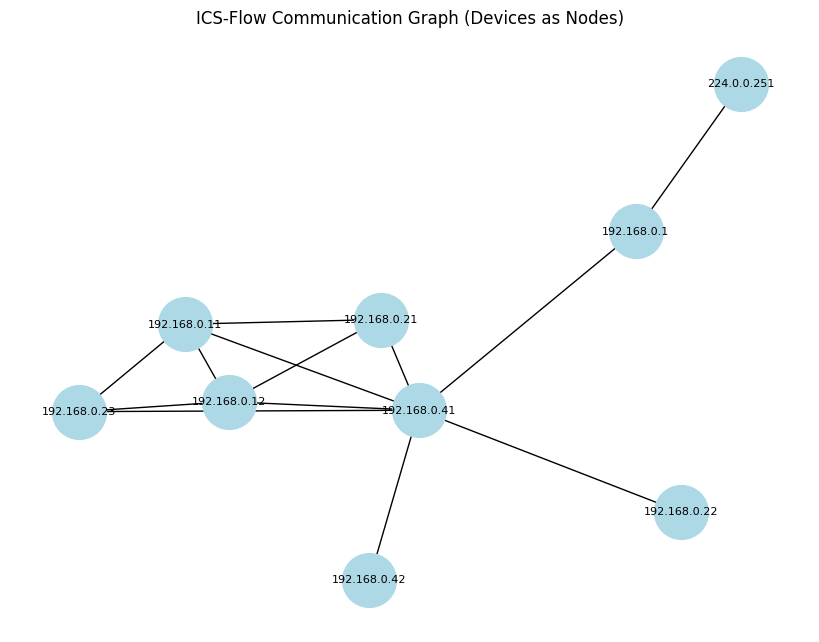

In [8]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1500,
    font_size=8
)
plt.title("ICS-Flow Communication Graph (Devices as Nodes)")
plt.savefig("week2_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## **7. Exploratory Distributions — Addresses, Protocols, and Labels**

Quick value counts to understand traffic volume per device, protocol mix, and the balance of attack classes in the dataset.

In [9]:
print("Source IP traffic volume:")
print(df['sIPs'].value_counts())

print("\nDestination IP traffic volume:")
print(df['rIPs'].value_counts())

print("\nProtocol distribution:")
print(df['protocol'].value_counts())

print("\nIT_M_Label distribution (Interval-Based Threshold, multi-class):")
print(df['IT_M_Label'].value_counts())

print("\nNST_M_Label distribution (Network Signature Threshold, multi-class):")
print(df['NST_M_Label'].value_counts())

Source IP traffic volume:
sIPs
192.168.0.11    29556
192.168.0.12    13425
192.168.0.21      310
192.168.0.1       264
192.168.0.23      207
192.168.0.41      197
192.168.0.22      197
Name: count, dtype: int64

Destination IP traffic volume:
rIPs
192.168.0.21    24412
192.168.0.12    14016
192.168.0.41     4791
192.168.0.23      730
192.168.0.42      197
224.0.0.251        10
Name: count, dtype: int64

Protocol distribution:
protocol
IPV4-TCP     43984
ARP           1552
IPV4-ICMP      162
IPV6            10
IPV4-UDP        10
Name: count, dtype: int64

IT_M_Label distribution (Interval-Based Threshold, multi-class):
IT_M_Label
Normal       30236
replay        4300
ddos          4221
port-scan     3235
mitm          3014
ip-scan        712
Name: count, dtype: int64

NST_M_Label distribution (Network Signature Threshold, multi-class):
NST_M_Label
Normal       36706
mitm          2584
replay        2358
port-scan     1944
ddos          1934
ip-scan        192
Name: count, dtype: int64


**Why this matters:** the `NST_M_Label` breakdown is the first real result from this notebook — it shows exactly how imbalanced the attack classes are (Normal traffic dominates, with `mitm`, `replay`, `port-scan`, `ddos`, and `ip-scan` each making up a small minority). This class imbalance will need to be addressed (e.g. with class weighting) when training the GNN in later weeks.

## **8. Weighted Graph — Flow Count per Device Pair**

The graph in Section 5 only records *whether* two devices communicated, not *how much*. This section builds a directed, weighted version of the graph, where each edge weight is the number of flows recorded between that source and destination — a more informative input for the eventual GNN, which will use edge weight as a feature.

In [10]:
edge_weights = (
    df_graph.groupby(["sIPs", "rIPs"])
    .size()
    .reset_index(name="flow_count")
)

G_weighted = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G_weighted.add_edge(row["sIPs"], row["rIPs"], weight=row["flow_count"])

print("Weighted graph — Nodes:", G_weighted.number_of_nodes())
print("Weighted graph — Edges:", G_weighted.number_of_edges())
edge_weights.sort_values("flow_count", ascending=False)

Weighted graph — Nodes: 9
Weighted graph — Edges: 13


,sIPs,rIPs,flow_count
2,192.168.0.11,192.168.0.12,14016
3,192.168.0.11,192.168.0.21,13140
6,192.168.0.12,192.168.0.21,11272
5,192.168.0.11,192.168.0.41,1922
8,192.168.0.12,192.168.0.41,1901
4,192.168.0.11,192.168.0.23,478
9,192.168.0.21,192.168.0.41,310
0,192.168.0.1,192.168.0.41,254
7,192.168.0.12,192.168.0.23,252
11,192.168.0.23,192.168.0.41,207


## **9. Attack-Aware Graph — Highlighting Malicious Edges**

Identifies which device pairs ever carried attack traffic (using `NST_M_Label`) and re-draws the graph with those edges highlighted in red. This is the step that turns a plain network diagram into a security-relevant graph — the same structure the knowledge graph will eventually encode as labelled, risk-weighted edges.

Device pairs that carried attack traffic:

            sIPs          rIPs NST_M_Label  count
0    192.168.0.1  192.168.0.41   port-scan    254
1   192.168.0.11  192.168.0.12        mitm    921
2   192.168.0.11  192.168.0.12      replay    227
3   192.168.0.11  192.168.0.21        mitm    648
4   192.168.0.11  192.168.0.21      replay    202
5   192.168.0.11  192.168.0.23        mitm     70
6   192.168.0.11  192.168.0.23      replay      6
7   192.168.0.11  192.168.0.41        ddos    968
8   192.168.0.11  192.168.0.41   port-scan    243
9   192.168.0.11  192.168.0.41      replay    711
10  192.168.0.12  192.168.0.21        mitm    390
11  192.168.0.12  192.168.0.21      replay    184
12  192.168.0.12  192.168.0.23        mitm     29
13  192.168.0.12  192.168.0.23      replay      5
14  192.168.0.12  192.168.0.41        ddos    966
15  192.168.0.12  192.168.0.41   port-scan    243
16  192.168.0.12  192.168.0.41      replay    692
17  192.168.0.21  192.168.0.41   port-scan    254
18  192

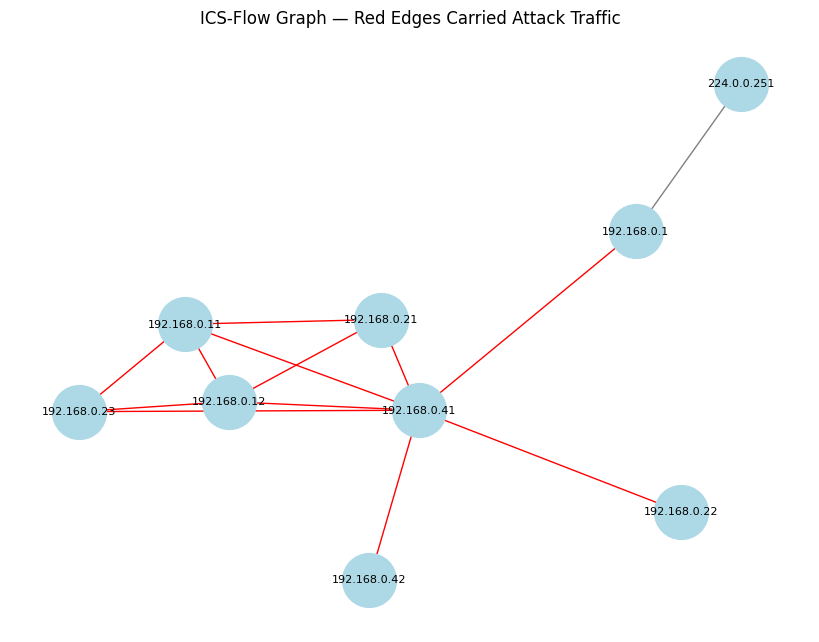

In [11]:
attack_edges = (
    df_graph[df_graph["NST_M_Label"] != "Normal"]
    .groupby(["sIPs", "rIPs", "NST_M_Label"])
    .size()
    .reset_index(name="count")
)
print("Device pairs that carried attack traffic:\n")
print(attack_edges)

# G is undirected, so check both (u, v) and (v, u) — NetworkX does not
# guarantee edges are returned in the same direction they were inserted.
attack_pairs = set(zip(attack_edges["sIPs"], attack_edges["rIPs"]))
edge_colors = [
    "red" if (u, v) in attack_pairs or (v, u) in attack_pairs else "gray"
    for u, v in G.edges()
]

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color=edge_colors,
    node_size=1500,
    font_size=8
)
plt.title("ICS-Flow Graph — Red Edges Carried Attack Traffic")
plt.savefig("week2_attack_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## **10. Summary**

- Loaded `Dataset.csv` from ICS-Flow: 45,718 labelled network flows, 64 features, two labelling strategies (IT / NST).
- Built an asset-level communication graph by collapsing flow records into unique device-to-device edges (~10 nodes, ~14 edges) — a small ICSSIM testbed topology.
- Produced a weighted, directed version of the graph capturing flow volume per device pair.
- Identified and visualised which device pairs carried attack traffic (`mitm`, `replay`, `port-scan`, `ddos`, `ip-scan`), turning the plain topology into a security-relevant graph.
- Confirmed significant class imbalance in attack labels — to be addressed during GNN training in later weeks.

**Next steps (Week 3 onward):**
1. Define the knowledge-graph schema in Neo4j (Asset, Vulnerability, Technique node types).
2. Ingest MITRE ATT&CK for ICS and CVE data to enrich this network graph with technique and vulnerability nodes.
3. Convert the weighted graph built here into a `torch_geometric.data.Data` object for GNN training.
4. Begin baseline GNN training for intrusion detection on ICS-Flow, benchmarked against `zhenlus/GNN-IDS`.

# **Week 3 — Flow Path Identification, Attack Flow Graph & BATADAL Graph Construction**
**Extends:** Week 2 (ICS-Flow exploration)  
**New this week:**
1. Attack flow path identification (ICS-Flow)
2. Attack flow graph visualization
3. Graph construction on BATADAL (real ICS physical-layer dataset)

**Devices Identification**

In [27]:
src_counts = df_graph['sIPs'].value_counts().rename('as_source')
dst_counts = df_graph['rIPs'].value_counts().rename('as_destination')

role_df = pd.concat([src_counts, dst_counts], axis=1).fillna(0).astype(int)
role_df['total_flows'] = role_df['as_source'] + role_df['as_destination']
role_df['source_ratio'] = (role_df['as_source'] / role_df['total_flows']).round(3)

print(role_df.sort_values('source_ratio', ascending=False))

              as_source  as_destination  total_flows  source_ratio
192.168.0.11      29556               0        29556         1.000
192.168.0.1         264               0          264         1.000
192.168.0.22        197               0          197         1.000
192.168.0.12      13425           14016        27441         0.489
192.168.0.23        207             730          937         0.221
192.168.0.41        197            4791         4988         0.039
192.168.0.21        310           24412        24722         0.013
192.168.0.42          0             197          197         0.000
224.0.0.251           0              10           10         0.000


In [28]:
print(edge_weights)

            sIPs          rIPs  flow_count
0    192.168.0.1  192.168.0.41         254
1    192.168.0.1   224.0.0.251          10
2   192.168.0.11  192.168.0.12       14016
3   192.168.0.11  192.168.0.21       13140
4   192.168.0.11  192.168.0.23         478
5   192.168.0.11  192.168.0.41        1922
6   192.168.0.12  192.168.0.21       11272
7   192.168.0.12  192.168.0.23         252
8   192.168.0.12  192.168.0.41        1901
9   192.168.0.21  192.168.0.41         310
10  192.168.0.22  192.168.0.41         197
11  192.168.0.23  192.168.0.41         207
12  192.168.0.41  192.168.0.42         197


In [29]:
mac_per_ip = (df_graph.groupby('sIPs')['sMACs']
              .nunique()
              .rename('unique_macs')
              .reset_index())

print(mac_per_ip.sort_values('unique_macs', ascending=False))

# Drill into which MACs .11 is using
print(df_graph[df_graph['sIPs'] == '192.168.0.11']
      .groupby('sMACs').size().reset_index(name='count'))

           sIPs  unique_macs
2  192.168.0.12            4
1  192.168.0.11            3
0   192.168.0.1            1
3  192.168.0.21            1
4  192.168.0.22            1
5  192.168.0.23            1
6  192.168.0.41            1
                                 sMACs  count
0                    02:42:c0:a8:00:0b  27538
1  02:42:c0:a8:00:0b/02:42:c0:a8:00:29   1974
2                    02:42:c0:a8:00:29     44


In [30]:
unique_macs_per_sip = df_graph.groupby('sIPs')['sMACs'].unique()
print("Unique MAC addresses per Source IP:")
for sip, macs in unique_macs_per_sip.items():
    print(f"  IP: {sip}, MAC(s): {', '.join(macs)}")

Unique MAC addresses per Source IP:
  IP: 192.168.0.1, MAC(s): 02:42:23:55:81:7e
  IP: 192.168.0.11, MAC(s): 02:42:c0:a8:00:0b, 02:42:c0:a8:00:0b/02:42:c0:a8:00:29, 02:42:c0:a8:00:29
  IP: 192.168.0.12, MAC(s): 02:42:c0:a8:00:0c, 02:42:c0:a8:00:0c/02:42:c0:a8:00:29, 02:42:c0:a8:00:29/02:42:c0:a8:00:0c, 02:42:c0:a8:00:29
  IP: 192.168.0.21, MAC(s): 02:42:c0:a8:00:15
  IP: 192.168.0.22, MAC(s): 02:42:c0:a8:00:16
  IP: 192.168.0.23, MAC(s): 02:42:c0:a8:00:17
  IP: 192.168.0.41, MAC(s): 02:42:c0:a8:00:29


In [31]:
attack_flows = df_graph[df_graph["NST_M_Label"] != "Normal"]
print(attack_flows["sIPs"].value_counts())

sIPs
192.168.0.11    3996
192.168.0.12    2509
192.168.0.21     310
192.168.0.1      254
192.168.0.23     206
192.168.0.41     197
192.168.0.22     197
Name: count, dtype: int64


In [32]:
proto_profile = (df_graph.groupby(['sIPs', 'protocol'])
                 .size()
                 .unstack(fill_value=0))

print(proto_profile)

protocol      IPV4-ICMP  IPV4-TCP  IPV4-UDP
sIPs                                       
192.168.0.1           0       254        10
192.168.0.11         48     29508         0
192.168.0.12         48     13377         0
192.168.0.21         56       254         0
192.168.0.22          0       197         0
192.168.0.23         10       197         0
192.168.0.41          0       197         0


In [33]:
attack_df = df_graph[df_graph['NST_M_Label'] != 'Normal']

# Who is the source of each attack type?
attack_sources = (attack_df.groupby(['sIPs', 'NST_M_Label'])
                  .size()
                  .unstack(fill_value=0))
print("=== Attack Sources ===")
print(attack_sources)

# Who is the victim?
attack_targets = (attack_df.groupby(['rIPs', 'NST_M_Label'])
                  .size()
                  .unstack(fill_value=0))
print("\n=== Attack Targets ===")
print(attack_targets)

=== Attack Sources ===
NST_M_Label   ddos  mitm  port-scan  replay
sIPs                                       
192.168.0.1      0     0        254       0
192.168.0.11   968  1639        243    1146
192.168.0.12   966   419        243     881
192.168.0.21     0     0        254      56
192.168.0.22     0     0        197       0
192.168.0.23     0     0        197       9
192.168.0.41     0     0        197       0

=== Attack Targets ===
NST_M_Label   ddos  mitm  port-scan  replay
rIPs                                       
192.168.0.12     0   921          0     227
192.168.0.21     0  1038          0     386
192.168.0.23     0    99          0      11
192.168.0.41  1934     0       1388    1468
192.168.0.42     0     0        197       0


In [34]:
# Group by source, destination AND attack type together
attack_flow = (
    df_graph[df_graph['NST_M_Label'] != 'Normal']
    .groupby(['sIPs', 'rIPs', 'NST_M_Label'])
    .size()
    .reset_index(name='count')
    .sort_values(['sIPs', 'NST_M_Label', 'count'], ascending=[True, True, False])
)

print("=== Attack Flows (Source → Destination → Attack Type → Count) ===")
print(attack_flow.to_string(index=False))

=== Attack Flows (Source → Destination → Attack Type → Count) ===
        sIPs         rIPs NST_M_Label  count
 192.168.0.1 192.168.0.41   port-scan    254
192.168.0.11 192.168.0.41        ddos    968
192.168.0.11 192.168.0.12        mitm    921
192.168.0.11 192.168.0.21        mitm    648
192.168.0.11 192.168.0.23        mitm     70
192.168.0.11 192.168.0.41   port-scan    243
192.168.0.11 192.168.0.41      replay    711
192.168.0.11 192.168.0.12      replay    227
192.168.0.11 192.168.0.21      replay    202
192.168.0.11 192.168.0.23      replay      6
192.168.0.12 192.168.0.41        ddos    966
192.168.0.12 192.168.0.21        mitm    390
192.168.0.12 192.168.0.23        mitm     29
192.168.0.12 192.168.0.41   port-scan    243
192.168.0.12 192.168.0.41      replay    692
192.168.0.12 192.168.0.21      replay    184
192.168.0.12 192.168.0.23      replay      5
192.168.0.21 192.168.0.41   port-scan    254
192.168.0.21 192.168.0.41      replay     56
192.168.0.22 192.168.0.41   port-s

In [35]:
import pandas as pd

# Add timing to understand attack sequence
attack_df = df_graph[df_graph['NST_M_Label'] != 'Normal'].copy()

# Get earliest timestamp per (src, dst, attack_type)
attack_timeline = (
    attack_df.groupby(['sIPs', 'rIPs', 'NST_M_Label'])
    .agg(
        count=('NST_M_Label', 'size'),
        first_seen=('startDate', 'min'),
        last_seen=('endDate', 'max')
    )
    .reset_index()
    .sort_values('first_seen')
)

print(attack_timeline.to_string(index=False))

        sIPs         rIPs NST_M_Label  count                 first_seen                  last_seen
192.168.0.11 192.168.0.41   port-scan    243 2022-09-16 12:15:42.250817 2022-09-16 13:23:25.449237
192.168.0.12 192.168.0.41   port-scan    243 2022-09-16 12:15:42.251016 2022-09-16 13:23:25.449285
192.168.0.21 192.168.0.41   port-scan    254 2022-09-16 12:15:42.251157 2022-09-16 13:23:25.715997
 192.168.0.1 192.168.0.41   port-scan    254 2022-09-16 12:15:42.251323 2022-09-16 13:23:25.715979
192.168.0.23 192.168.0.41   port-scan    197 2022-09-16 12:15:50.225897 2022-09-16 13:23:30.877910
192.168.0.41 192.168.0.42   port-scan    197 2022-09-16 12:15:50.226240 2022-09-16 13:23:30.877881
192.168.0.22 192.168.0.41   port-scan    197 2022-09-16 12:15:50.226498 2022-09-16 13:23:30.877939
192.168.0.11 192.168.0.12        mitm    921 2022-09-16 12:17:06.600369 2022-09-16 13:26:19.397292
192.168.0.11 192.168.0.21        mitm    648 2022-09-16 12:17:07.012216 2022-09-16 13:26:19.435220
192.168.0.

In [36]:
import networkx as nx

G_path = nx.MultiDiGraph()

for _, row in attack_timeline.iterrows():
    G_path.add_edge(
        row['sIPs'], row['rIPs'],
        attack_type=row['NST_M_Label'],
        count=row['count'],
        first_seen=str(row['first_seen'])
    )
# Now find ALL paths from attacker to any victim
ATTACKER = '192.168.0.41'
print("=== Unique paths where attacker is the TARGET ===")
for source in ['192.168.0.1', '192.168.0.11', '192.168.0.12',
               '192.168.0.21', '192.168.0.22', '192.168.0.23']:
    try:
        # Convert to set of tuples to remove duplicates
        paths = set(
            tuple(p)
            for p in nx.all_simple_paths(G_path, source, ATTACKER)
        )
        for p in sorted(paths):
            print(" → ".join(p))
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        pass

=== Unique paths where attacker is the TARGET ===
192.168.0.1 → 192.168.0.41
192.168.0.11 → 192.168.0.12 → 192.168.0.21 → 192.168.0.41
192.168.0.11 → 192.168.0.12 → 192.168.0.23 → 192.168.0.41
192.168.0.11 → 192.168.0.12 → 192.168.0.41
192.168.0.11 → 192.168.0.21 → 192.168.0.41
192.168.0.11 → 192.168.0.23 → 192.168.0.41
192.168.0.11 → 192.168.0.41
192.168.0.12 → 192.168.0.21 → 192.168.0.41
192.168.0.12 → 192.168.0.23 → 192.168.0.41
192.168.0.12 → 192.168.0.41
192.168.0.21 → 192.168.0.41
192.168.0.22 → 192.168.0.41
192.168.0.23 → 192.168.0.41


## **Attack Flow Graph**

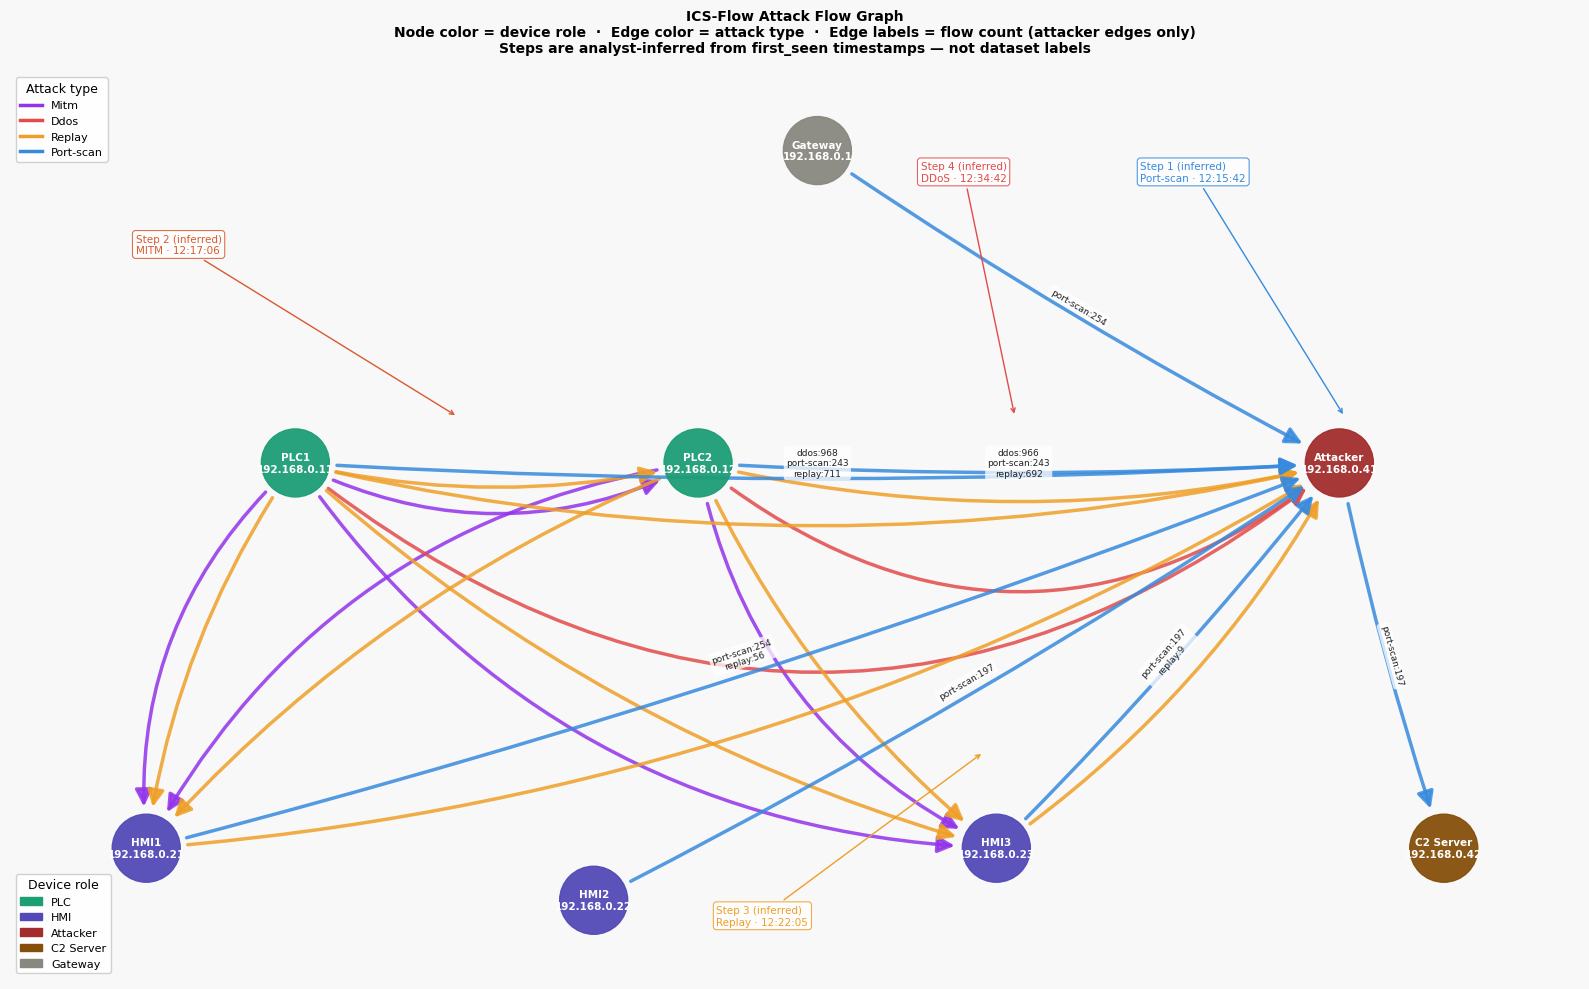

Saved: week3_attack_flow_graph.png


In [37]:
# Attack Flow Graph

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import math

# 1. PREPARE ATTACK FLOWS
attack_timeline = (
    df_graph[df_graph['NST_M_Label'] != 'Normal']
    .groupby(['sIPs', 'rIPs', 'NST_M_Label'])
    .agg(
        count=('NST_M_Label', 'size'),
        first_seen=('startDate', 'min'),
        last_seen=('endDate', 'max')
    )
    .reset_index()
    .sort_values('first_seen')
)

# 2. BUILD MULTIGRAPH
G_path = nx.MultiDiGraph()
for _, row in attack_timeline.iterrows():
    G_path.add_edge(
        row['sIPs'], row['rIPs'],
        attack_type=row['NST_M_Label'],
        count=int(row['count']),
        first_seen=str(row['first_seen'])
    )

# 3. ROLE & COLOR MAPS
role_map = {
    '192.168.0.1':  'Gateway',
    '192.168.0.11': 'PLC1',
    '192.168.0.12': 'PLC2',
    '192.168.0.21': 'HMI1',
    '192.168.0.22': 'HMI2',
    '192.168.0.23': 'HMI3',
    '192.168.0.41': 'Attacker',
    '192.168.0.42': 'C2 Server',
}
attack_colors = {
    'mitm':      '#9333EA',
    'ddos':      '#E24B4A',
    'replay':    '#EF9F27',
    'port-scan': '#378ADD',
}
node_colors_map = {
    'PLC1':      '#1D9E75',
    'PLC2':      '#1D9E75',
    'HMI1':      '#534AB7',
    'HMI2':      '#534AB7',
    'HMI3':      '#534AB7',
    'Gateway':   '#888780',
    'Attacker':  '#A32D2D',
    'C2 Server': '#854F0B',
}

# 4. LAYOUT
# Attacker on right, PLCs top-left, HMIs bottom, Gateway top-center
# Spread nodes more to reduce edge label overlap
pos = {
    '192.168.0.1':  (0.50, 0.92),  # Gateway — top center
    '192.168.0.11': (0.15, 0.62),  # PLC1 — left
    '192.168.0.12': (0.42, 0.62),  # PLC2 — center
    '192.168.0.41': (0.85, 0.62),  # Attacker — far right
    '192.168.0.21': (0.05, 0.25),  # HMI1 — bottom far left
    '192.168.0.22': (0.35, 0.20),  # HMI2 — bottom center-left
    '192.168.0.23': (0.62, 0.25),  # HMI3 — bottom center-right
    '192.168.0.42': (0.92, 0.25),  # C2 Server — bottom far right
}

# 5. DRAW
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('#F8F8F8')

# Nodes
node_color_list = [
    node_colors_map.get(role_map.get(ip, ''), '#888780')
    for ip in G_path.nodes()
]
nx.draw_networkx_nodes(
    G_path, pos,
    node_color=node_color_list,
    node_size=2400,
    alpha=0.95,
    ax=ax
)
node_labels = {
    ip: f"{role_map.get(ip, ip)}\n{ip}"
    for ip in G_path.nodes()
}
nx.draw_networkx_labels(
    G_path, pos,
    labels=node_labels,
    font_size=7.5,
    font_color='white',
    font_weight='bold',
    ax=ax
)

# Edges — separate arc per attack type to avoid overlap

arc_rads = {
    'mitm':      0.25,
    'ddos':      0.40,
    'replay':    0.12,
    'port-scan': 0.03,
}

for attack_type, color in attack_colors.items():
    edges_of_type = [
        (u, v) for u, v, d in G_path.edges(data=True)
        if d['attack_type'] == attack_type
    ]
    if not edges_of_type:
        continue

    nx.draw_networkx_edges(
        G_path, pos,
        edgelist=edges_of_type,
        edge_color=color,
        width=2.5,              # thicker lines
        alpha=0.85,
        arrows=True,
        arrowsize=25,           # bigger arrowhead
        arrowstyle='-|>',
        min_source_margin=30,   # gap at source node so arrow starts outside node
        min_target_margin=30,   # gap at target node so arrowhead visible
        connectionstyle=f'arc3,rad={arc_rads[attack_type]}',
        ax=ax
    )
#  6. EDGE LABELS (only on non-cluttered edges)
# Only label edges that go directly to/from Attacker to keep graph readable
attacker_ip = '192.168.0.41'
c2_ip       = '192.168.0.42'

edge_label_data = {}
for u, v, d in G_path.edges(data=True):
    if attacker_ip in (u, v) or c2_ip in (u, v):
        key = (u, v)
        atype = d['attack_type']
        edge_label_data.setdefault(key, {})
        edge_label_data[key][atype] = (
            edge_label_data[key].get(atype, 0) + d['count']
        )

edge_labels = {
    k: '\n'.join(f"{a}:{c}" for a, c in sorted(v.items()))
    for k, v in edge_label_data.items()
}
nx.draw_networkx_edge_labels(
    G_path, pos,
    edge_labels=edge_labels,
    font_size=6.5,
    font_color='#222222',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='none'),
    ax=ax
)

# 7. PHASE ANNOTATIONS (correctly placed, honestly labeled) ─
# NOTE: phases are analyst-inferred from first_seen timestamps,
# NOT labels present in the dataset.
annotations = [
    {
        'text':   'Step 1 (inferred)\nPort-scan · 12:15:42',
        'xy':     (0.85, 0.62),   # points to Attacker node
        'xytext': (0.72, 0.88),
        'color':  '#378ADD',
    },
    {
        'text':   'Step 2 (inferred)\nMITM · 12:17:06',
        'xy':     (0.285, 0.62),  # midpoint PLC1→PLC2 edge
        'xytext': (0.08, 0.80),
        'color':  '#D85A30',
    },
    {
        'text':   'Step 3 (inferred)\nReplay · 12:22:05',
        'xy':     (0.62, 0.25),   # points to HMI3
        'xytext': (0.45, 0.06),
        'color':  '#EF9F27',
    },
    {
        'text':   'Step 4 (inferred)\nDDoS · 12:34:42',
        'xy':     (0.64, 0.62),   # midpoint PLC2→Attacker edge
        'xytext': (0.58, 0.88),
        'color':  '#E24B4A',
    },
]
for ann in annotations:
    ax.annotate(
        ann['text'],
        xy=ann['xy'],
        xytext=ann['xytext'],
        xycoords='axes fraction',
        textcoords='axes fraction',
        fontsize=7.5,
        color=ann['color'],
        arrowprops=dict(arrowstyle='->', color=ann['color'], lw=1.0),
        bbox=dict(
            boxstyle='round,pad=0.3', fc='white',
            alpha=0.85, ec=ann['color'], lw=0.8
        )
    )

# 8. LEGENDS
attack_legend = [
    Line2D([0], [0], color=c, linewidth=2.5, label=a.capitalize())
    for a, c in attack_colors.items()
]
node_legend = [
    mpatches.Patch(color='#1D9E75', label='PLC'),
    mpatches.Patch(color='#534AB7', label='HMI'),
    mpatches.Patch(color='#A32D2D', label='Attacker'),
    mpatches.Patch(color='#854F0B', label='C2 Server'),
    mpatches.Patch(color='#888780', label='Gateway'),
]
leg1 = ax.legend(
    handles=attack_legend,
    title='Attack type',
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9
)
ax.add_artist(leg1)
ax.legend(
    handles=node_legend,
    title='Device role',
    loc='lower left',
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9
)

# 9. TITLE
ax.set_title(
    'ICS-Flow Attack Flow Graph\n'
    'Node color = device role  ·  Edge color = attack type  ·  '
    'Edge labels = flow count (attacker edges only)\n'
    'Steps are analyst-inferred from first_seen timestamps — '
    'not dataset labels',
    fontsize=10,
    fontweight='bold',
    pad=14
)

ax.axis('off')
plt.tight_layout()
plt.savefig('week3_attack_flow_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week3_attack_flow_graph.png")

In [38]:
#  9. PRINT SUMMARY TABLE
print("\n=== Attack Flow Summary ===")
print(attack_timeline[['sIPs','rIPs','NST_M_Label','count','first_seen']]
      .rename(columns={
          'sIPs':'Source','rIPs':'Destination',
          'NST_M_Label':'Attack','count':'Flows','first_seen':'First Seen'
      })
      .to_string(index=False))


=== Attack Flow Summary ===
      Source  Destination    Attack  Flows                 First Seen
192.168.0.11 192.168.0.41 port-scan    243 2022-09-16 12:15:42.250817
192.168.0.12 192.168.0.41 port-scan    243 2022-09-16 12:15:42.251016
192.168.0.21 192.168.0.41 port-scan    254 2022-09-16 12:15:42.251157
 192.168.0.1 192.168.0.41 port-scan    254 2022-09-16 12:15:42.251323
192.168.0.23 192.168.0.41 port-scan    197 2022-09-16 12:15:50.225897
192.168.0.41 192.168.0.42 port-scan    197 2022-09-16 12:15:50.226240
192.168.0.22 192.168.0.41 port-scan    197 2022-09-16 12:15:50.226498
192.168.0.11 192.168.0.12      mitm    921 2022-09-16 12:17:06.600369
192.168.0.11 192.168.0.21      mitm    648 2022-09-16 12:17:07.012216
192.168.0.11 192.168.0.23      mitm     70 2022-09-16 12:17:12.932794
192.168.0.12 192.168.0.21      mitm    390 2022-09-16 12:17:16.315296
192.168.0.12 192.168.0.23      mitm     29 2022-09-16 12:19:26.993591
192.168.0.11 192.168.0.12    replay    227 2022-09-16 12:22:0

## **BATADAL Dataset**

In [39]:
# WEEK 3 — BATADAL Dataset Graph Construction
# Dataset: Battle of the Attack Detection Algorithms (BATADAL)
# Source: http://www.batadal.net/data.html
# File: BATADAL_dataset04.csv (training with attacks)


import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
df = pd.read_csv('BATADAL_dataset04.csv')

# Clean column name
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
print(df.head(3))
print("\nAttack label distribution:")
print(df['ATT_FLAG'].value_counts())

Shape: (4177, 45)

Columns: ['DATETIME', 'L_T1', 'L_T2', 'L_T3', 'L_T4', 'L_T5', 'L_T6', 'L_T7', 'F_PU1', 'S_PU1', 'F_PU2', 'S_PU2', 'F_PU3', 'S_PU3', 'F_PU4', 'S_PU4', 'F_PU5', 'S_PU5', 'F_PU6', 'S_PU6', 'F_PU7', 'S_PU7', 'F_PU8', 'S_PU8', 'F_PU9', 'S_PU9', 'F_PU10', 'S_PU10', 'F_PU11', 'S_PU11', 'F_V2', 'S_V2', 'P_J280', 'P_J269', 'P_J300', 'P_J256', 'P_J289', 'P_J415', 'P_J302', 'P_J306', 'P_J307', 'P_J317', 'P_J14', 'P_J422', 'ATT_FLAG']

First rows:
      DATETIME  L_T1  L_T2  L_T3  L_T4  L_T5  L_T6  L_T7  F_PU1  S_PU1  ...  \
0  04/07/16 00  2.44  5.24  3.19  4.10  2.86  5.50  4.39  93.63    1.0  ...   
1  04/07/16 01  2.66  4.53  3.20  4.18  3.29  5.44  4.53  89.41    1.0  ...   
2  04/07/16 02  3.11  3.66  3.66  4.21  3.87  5.15  3.22  89.88    1.0  ...   

   P_J256  P_J289  P_J415  P_J302  P_J306  P_J307  P_J317  P_J14  P_J422  \
0   70.00   28.22   85.87   21.69   82.72   21.58   71.99  39.33   29.64   
1   87.73   24.45   84.87   29.81   86.62   29.81   59.76  42.17   26.15

In [40]:
# Fix 1: ATT_FLAG uses -999 for normal, 1 for attack (not 0/1)
df['ATT_FLAG'] = df['ATT_FLAG'].replace(-999, 0)

print("Fixed label distribution:")
print(df['ATT_FLAG'].value_counts())

# So sensor type detection needs updating
sensor_cols = [c for c in df.columns if c not in ['DATETIME', 'ATT_FLAG']]

def get_sensor_type(col):
    if col.startswith('L_T'):   return 'Tank'
    if col.startswith('F_PU'):  return 'Pump_Flow'
    if col.startswith('F_V'):   return 'Valve_Flow'
    if col.startswith('P_J'):   return 'Pressure'
    if col.startswith('S_PU'):  return 'Pump_Status'
    if col.startswith('S_V'):   return 'Valve_Status'
    return 'Unknown'

sensor_type_map = {col: get_sensor_type(col) for col in sensor_cols}

print("\n=== Sensor inventory ===")
for stype in ['Tank', 'Pump_Flow', 'Valve_Flow',
              'Pressure', 'Pump_Status', 'Valve_Status']:
    members = [c for c, t in sensor_type_map.items() if t == stype]
    print(f"{stype:15s}: {len(members):3d}  →  {members}")

# Fix 3: Split normal vs attack with corrected label
df_normal = df[df['ATT_FLAG'] == 0][sensor_cols]
df_attack = df[df['ATT_FLAG'] == 1][sensor_cols]

print(f"\nNormal timesteps : {len(df_normal)}")
print(f"Attack timesteps : {len(df_attack)}")
print(f"Attack ratio     : {len(df_attack)/len(df)*100:.1f}%")

Fixed label distribution:
ATT_FLAG
0    3958
1     219
Name: count, dtype: int64

=== Sensor inventory ===
Tank           :   7  →  ['L_T1', 'L_T2', 'L_T3', 'L_T4', 'L_T5', 'L_T6', 'L_T7']
Pump_Flow      :  11  →  ['F_PU1', 'F_PU2', 'F_PU3', 'F_PU4', 'F_PU5', 'F_PU6', 'F_PU7', 'F_PU8', 'F_PU9', 'F_PU10', 'F_PU11']
Valve_Flow     :   1  →  ['F_V2']
Pressure       :  12  →  ['P_J280', 'P_J269', 'P_J300', 'P_J256', 'P_J289', 'P_J415', 'P_J302', 'P_J306', 'P_J307', 'P_J317', 'P_J14', 'P_J422']
Pump_Status    :  11  →  ['S_PU1', 'S_PU2', 'S_PU3', 'S_PU4', 'S_PU5', 'S_PU6', 'S_PU7', 'S_PU8', 'S_PU9', 'S_PU10', 'S_PU11']
Valve_Status   :   1  →  ['S_V2']

Normal timesteps : 3958
Attack timesteps : 219
Attack ratio     : 5.2%


### **BUILD CORRELATION GRAPHS**

In [41]:
#  4. BUILD CORRELATION GRAPHS
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

CORRELATION_THRESHOLD = 0.7

def build_correlation_graph(data, threshold=0.7):
    G = nx.Graph()
    for col in sensor_cols:
        G.add_node(col, sensor_type=sensor_type_map[col])

    cols = data.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            col_i, col_j = cols[i], cols[j]
            if data[col_i].std() == 0 or data[col_j].std() == 0:
                continue
            corr, pval = pearsonr(
                data[col_i].fillna(0),
                data[col_j].fillna(0)
            )
            if abs(corr) >= threshold and pval < 0.05:
                G.add_edge(col_i, col_j,
                           weight=round(abs(corr), 3),
                           correlation=round(corr, 3))
    return G

print("Building normal graph...")
G_normal = build_correlation_graph(df_normal, CORRELATION_THRESHOLD)

print("Building attack graph...")
G_attack = build_correlation_graph(df_attack, CORRELATION_THRESHOLD)

print(f"\nNormal graph → nodes: {G_normal.number_of_nodes()}, edges: {G_normal.number_of_edges()}")
print(f"Attack graph → nodes: {G_attack.number_of_nodes()}, edges: {G_attack.number_of_edges()}")

Building normal graph...
Building attack graph...

Normal graph → nodes: 43, edges: 37
Attack graph → nodes: 43, edges: 30


### **ANOMALY ANALYSIS**

In [42]:
# 5. ANOMALY ANALYSIS
normal_edges = set(G_normal.edges())
attack_edges = set(G_attack.edges())

new_in_attack  = attack_edges - normal_edges
lost_in_attack = normal_edges - attack_edges

print(f"New edges during attack  : {len(new_in_attack)}")
print(f"Lost edges during attack : {len(lost_in_attack)}")
print(f"Stable edges (both)      : {len(normal_edges & attack_edges)}")

print("\n=== New anomalous edges (appeared only during attack) ===")
for e in sorted(new_in_attack):
    w = G_attack[e[0]][e[1]]['weight']
    t0 = sensor_type_map[e[0]]
    t1 = sensor_type_map[e[1]]
    print(f"  {e[0]:10s} ({t0:12s}) ↔ {e[1]:10s} ({t1:12s})  corr={w}")

# Anomalous sensors by value deviation
def detect_anomalous_sensors(df_normal, df_attack, threshold_std=2.0):
    anomalous = {}
    for col in sensor_cols:
        normal_mean = df_normal[col].mean()
        normal_std  = df_normal[col].std()
        attack_mean = df_attack[col].mean()
        if normal_std == 0:
            continue
        deviation = abs(attack_mean - normal_mean) / normal_std
        if deviation >= threshold_std:
            anomalous[col] = round(deviation, 2)
    return anomalous

anomalous_sensors = detect_anomalous_sensors(df_normal, df_attack)

print(f"\n=== Anomalous sensors during attack ({len(anomalous_sensors)} found) ===")
for sensor, dev in sorted(anomalous_sensors.items(), key=lambda x: -x[1]):
    stype = sensor_type_map[sensor]
    print(f"  {sensor:12s} ({stype:12s})  deviation = {dev} std")


New edges during attack  : 4
Lost edges during attack : 11
Stable edges (both)      : 26

=== New anomalous edges (appeared only during attack) ===
  F_PU6      (Pump_Flow   ) ↔ S_PU7      (Pump_Status )  corr=0.72
  P_J302     (Pressure    ) ↔ P_J14      (Pressure    )  corr=0.713
  P_J307     (Pressure    ) ↔ P_J14      (Pressure    )  corr=0.711
  S_PU6      (Pump_Status ) ↔ S_PU7      (Pump_Status )  corr=0.72

=== Anomalous sensors during attack (4 found) ===
  F_PU6        (Pump_Flow   )  deviation = 3.6 std
  S_PU6        (Pump_Status )  deviation = 3.13 std
  F_PU11       (Pump_Flow   )  deviation = 2.51 std
  S_PU11       (Pump_Status )  deviation = 2.39 std


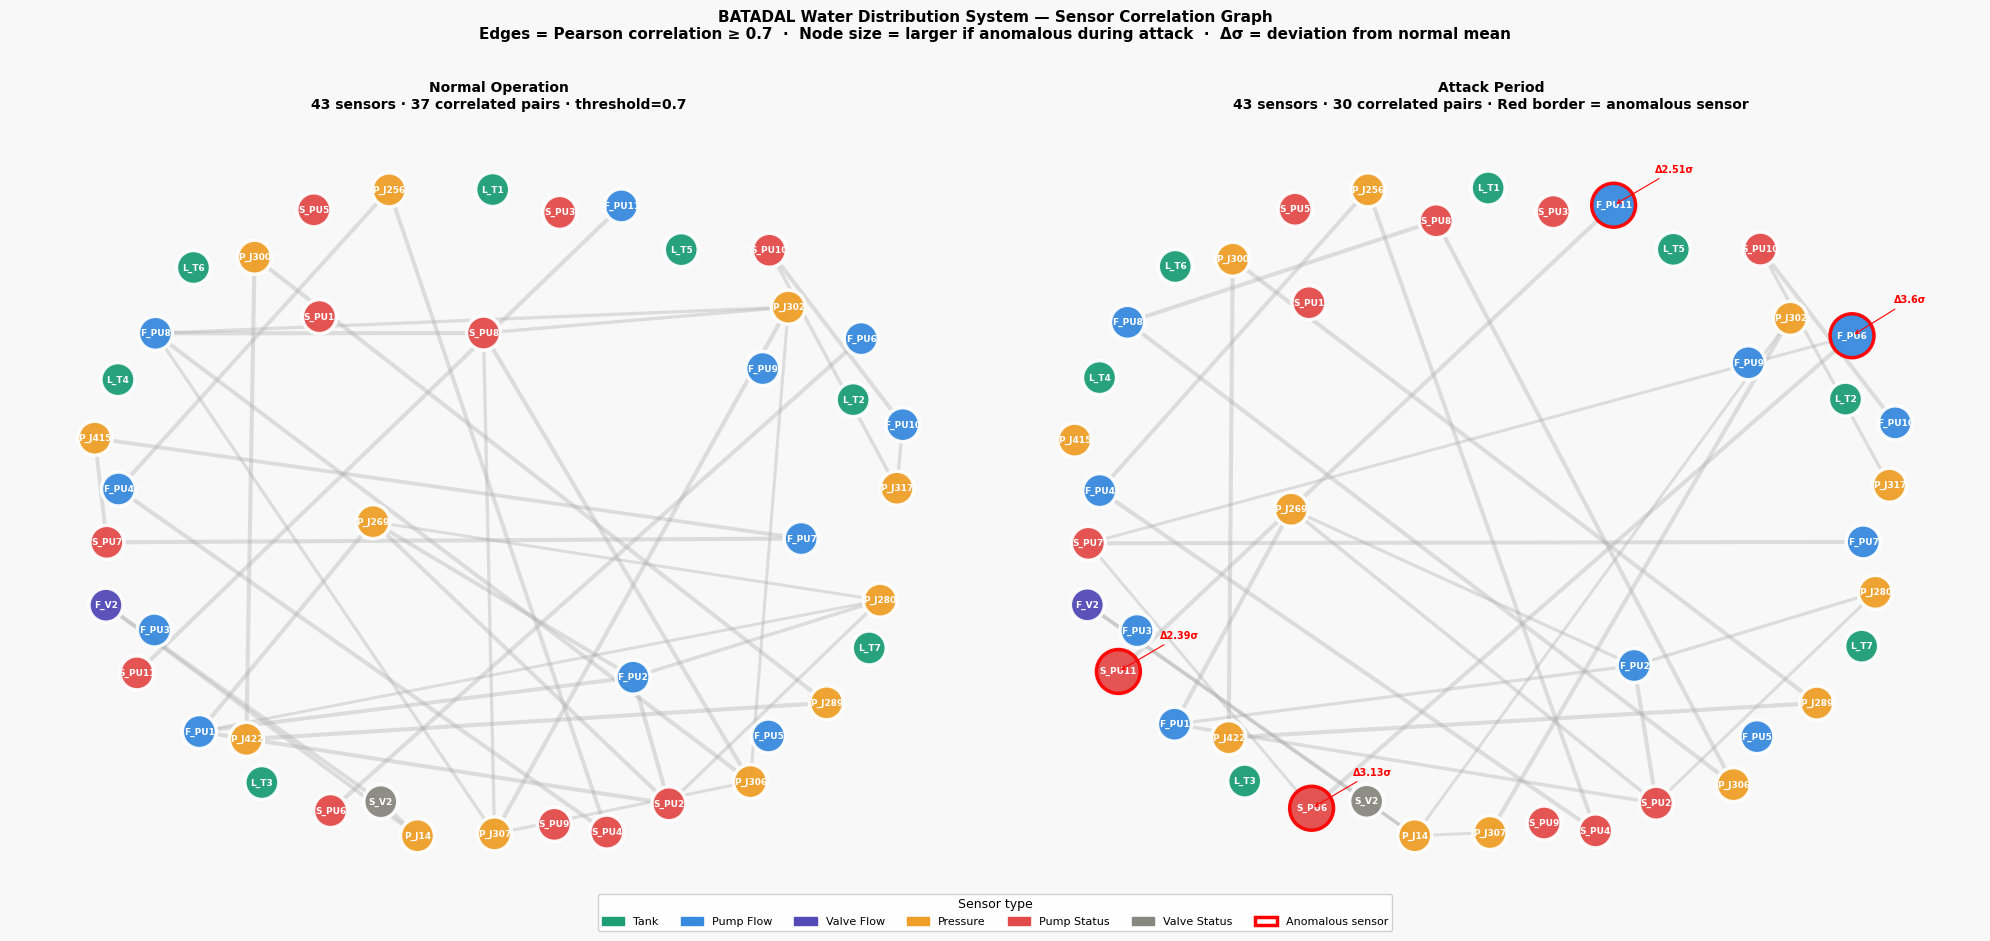

Saved: week3_batadal_graph.png


In [43]:
#  6. VISUALIZATION
type_colors = {
    'Tank':         '#1D9E75',
    'Pump_Flow':    '#378ADD',
    'Valve_Flow':   '#534AB7',
    'Pressure':     '#EF9F27',
    'Pump_Status':  '#E24B4A',
    'Valve_Status': '#888780',
    'Unknown':      '#333333',
}

def draw_batadal_graph(G, anomalous, title, ax):
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'No graph', ha='center')
        return

    # Group nodes by type for a cleaner layout
    # Place same sensor types near each other
    pos = nx.spring_layout(G, seed=42, k=2.0)

    node_colors     = [type_colors.get(G.nodes[n].get('sensor_type','Unknown'), '#888780') for n in G.nodes()]
    node_edge_colors= ['#FF0000' if n in anomalous else '#ffffff' for n in G.nodes()]
    node_sizes      = [1000 if n in anomalous else 600 for n in G.nodes()]
    edge_weights    = [G[u][v]['weight'] * 3 for u, v in G.edges()]

    nx.draw_networkx_edges(G, pos,
        width=edge_weights, alpha=0.35,
        edge_color='#AAAAAA', ax=ax)

    nx.draw_networkx_nodes(G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors=node_edge_colors,
        linewidths=2.5,
        alpha=0.95, ax=ax)

    nx.draw_networkx_labels(G, pos,
        font_size=6.5,
        font_color='white',
        font_weight='bold', ax=ax)

    # Annotate anomalous nodes
    for node, dev in anomalous.items():
        if node in pos:
            x, y = pos[node]
            ax.annotate(f'Δ{dev}σ',
                xy=(x, y), xytext=(x+0.1, y+0.1),
                fontsize=7, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.axis('off')

# Draw
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('#F8F8F8')

draw_batadal_graph(
    G_normal, {},
    f'Normal Operation\n'
    f'{G_normal.number_of_nodes()} sensors · '
    f'{G_normal.number_of_edges()} correlated pairs · '
    f'threshold={CORRELATION_THRESHOLD}',
    axes[0]
)
draw_batadal_graph(
    G_attack, anomalous_sensors,
    f'Attack Period\n'
    f'{G_attack.number_of_nodes()} sensors · '
    f'{G_attack.number_of_edges()} correlated pairs · '
    f'Red border = anomalous sensor',
    axes[1]
)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=t.replace('_',' '))
    for t, c in type_colors.items() if t != 'Unknown'
]
legend_handles.append(
    mpatches.Patch(facecolor='white', edgecolor='red',
                   linewidth=2.5, label='Anomalous sensor')
)
fig.legend(handles=legend_handles,
           title='Sensor type',
           loc='lower center', ncol=7,
           fontsize=8, title_fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'BATADAL Water Distribution System — Sensor Correlation Graph\n'
    'Edges = Pearson correlation ≥ 0.7  ·  '
    'Node size = larger if anomalous during attack  ·  '
    'Δσ = deviation from normal mean',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('week3_batadal_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week3_batadal_graph.png")


In [44]:
#  7. FINAL SUMMARY
print("\n" + "="*50)
print("WEEK 3 SUMMARY — BATADAL Graph Construction")
print("="*50)
print(f"Dataset              : BATADAL_dataset03.csv")
print(f"Total timesteps      : {len(df)}")
print(f"Normal timesteps     : {len(df_normal)} ({len(df_normal)/len(df)*100:.1f}%)")
print(f"Attack timesteps     : {len(df_attack)} ({len(df_attack)/len(df)*100:.1f}%)")
print(f"Sensors total        : {len(sensor_cols)}")
print(f"\nNormal graph         : {G_normal.number_of_nodes()} nodes, {G_normal.number_of_edges()} edges")
print(f"Attack graph         : {G_attack.number_of_nodes()} nodes, {G_attack.number_of_edges()} edges")
print(f"\nNew edges in attack  : {len(new_in_attack)}")
print(f"Lost edges in attack : {len(lost_in_attack)}")
print(f"Anomalous sensors    : {len(anomalous_sensors)}")
print(f"\nKey finding: {len(anomalous_sensors)} sensors deviate >2σ from normal")
print(f"during attack — these are your high-risk nodes for GNN Week 6.")


WEEK 3 SUMMARY — BATADAL Graph Construction
Dataset              : BATADAL_dataset03.csv
Total timesteps      : 4177
Normal timesteps     : 3958 (94.8%)
Attack timesteps     : 219 (5.2%)
Sensors total        : 43

Normal graph         : 43 nodes, 37 edges
Attack graph         : 43 nodes, 30 edges

New edges in attack  : 4
Lost edges in attack : 11
Anomalous sensors    : 4

Key finding: 4 sensors deviate >2σ from normal
during attack — these are your high-risk nodes for GNN Week 6.


# **Week 4 — ICS-Flow Knowledge Graph + GNN Pipeline**


1. Knowledge Graph Construction

2. Added a **PyTorch Geometric** pipeline.

## **Part A — Knowledge Graph Construction**

### 1. Setup

Reuses `df_graph` from Week 2 (ICS-Flow flows with missing `sIPs`/`rIPs` dropped).


In [45]:
# 1. SETUP
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter

print(f"ICS-Flow records : {len(df_graph)}")
print(f"Attack types     : {df_graph['NST_M_Label'].value_counts().to_dict()}")

ICS-Flow records : 44156
Attack types     : {'Normal': 36487, 'replay': 2092, 'mitm': 2058, 'ddos': 1934, 'port-scan': 1585}


### 2. Device role — single source of truth

This is the **same `role_map`** already defined in the Week 3 *Attack Flow Graph*
cell. It's testbed configuration (which physical device each IP is).

In [46]:
# 2. DEVICE ROLE (identical to the Week 3 role_map — single source of truth)
role_map = {
    '192.168.0.1':  'Gateway',
    '192.168.0.11': 'PLC1',
    '192.168.0.12': 'PLC2',
    '192.168.0.21': 'HMI1',
    '192.168.0.22': 'HMI2',
    '192.168.0.23': 'HMI3',
    '192.168.0.41': 'Attacker',
    '192.168.0.42': 'C2 Server',
}

def node_type_of(ip: str) -> str:
    """Asset vs Attacker, derived from role_map."""
    role = role_map.get(ip, 'Unknown')
    return 'Attacker' if role in ('Attacker', 'C2 Server') else 'Asset'

print("Device roles:")
for ip, role in role_map.items():
    print(f"  {ip:15s} -> {role:10s} ({node_type_of(ip)})")

Device roles:
  192.168.0.1     -> Gateway    (Asset)
  192.168.0.11    -> PLC1       (Asset)
  192.168.0.12    -> PLC2       (Asset)
  192.168.0.21    -> HMI1       (Asset)
  192.168.0.22    -> HMI2       (Asset)
  192.168.0.23    -> HMI3       (Asset)
  192.168.0.41    -> Attacker   (Attacker)
  192.168.0.42    -> C2 Server  (Attacker)


### 3. Flow-derived device statistics

`flow_count` and `source_ratio` computed directly from `df_graph` — same
numbers as the Week 2 `role_df` table, just wrapped in a reusable function so
Week 4 doesn't re-type them.

In [47]:
# 3. FLOW-DERIVED STATS
def build_device_stats(df_graph: pd.DataFrame) -> pd.DataFrame:
    src = df_graph['sIPs'].value_counts().rename('as_source')
    dst = df_graph['rIPs'].value_counts().rename('as_destination')
    stats = pd.concat([src, dst], axis=1).fillna(0).astype(int)
    stats['flow_count'] = stats['as_source'] + stats['as_destination']
    stats['source_ratio'] = (stats['as_source'] / stats['flow_count']).round(3)
    return stats

device_stats = build_device_stats(df_graph)
device_stats

,as_source,as_destination,flow_count,source_ratio
192.168.0.11,29556,0,29556,1.000
192.168.0.12,13425,14016,27441,0.489
192.168.0.21,310,24412,24722,0.013
192.168.0.1,264,0,264,1.000
192.168.0.23,207,730,937,0.221
192.168.0.41,197,4791,4988,0.039
192.168.0.22,197,0,197,1.000
192.168.0.42,0,197,197,0.000
224.0.0.251,0,10,10,0.000


### 4. Threat-intel enrichment: MITRE ATT&CK techniques + CVEs

These **cannot** be derived from network flow data — a CSV of packet flows has
no concept of a CVE ID or a MITRE technique ID. This is standard practice for
real ICS knowledge graphs: topology + behavior comes from telemetry, vulnerability
context comes from a threat-intel feed. They're merged, not conflated — only the
`maps_to` field ties a technique back to the dataset's own `NST_M_Label` values.

In [48]:
# 4. MITRE ATT&CK ICS TECHNIQUE NODES (external reference, mapped to dataset labels)
technique_nodes = {
    'T0830': {'node_type': 'Technique', 'name': 'Adversary-in-the-Middle',
              'tactic': 'Collection, Lateral Movement', 'maps_to': 'mitm',
              'description': 'Attacker intercepts communications between ICS devices',
              'severity': 'High'},
    'T0814': {'node_type': 'Technique', 'name': 'Denial of Service',
              'tactic': 'Inhibit Response Function', 'maps_to': 'ddos',
              'description': 'Flood ICS devices to prevent legitimate communication',
              'severity': 'High'},
    'T0843': {'node_type': 'Technique', 'name': 'Program Download / Replay',
              'tactic': 'Impair Process Control', 'maps_to': 'replay',
              'description': 'Replay captured ICS packets to manipulate physical process',
              'severity': 'Critical'},
    'T0846': {'node_type': 'Technique', 'name': 'Remote System Discovery',
              'tactic': 'Discovery', 'maps_to': 'port-scan',
              'description': 'Scan ICS network to identify devices and open ports',
              'severity': 'Medium'},
}
label_to_technique = {v['maps_to']: k for k, v in technique_nodes.items()}

# CVE NODES (external reference — real CVEs relevant to Modbus/TCP ICS)
cve_nodes = {
    'CVE-2019-13945': {'node_type': 'CVE', 'cvss_score': 6.8,
                        'description': 'Siemens S7 PLC — unauthenticated Modbus access allows replay',
                        'affects': ['192.168.0.11', '192.168.0.12'], 'enables': ['T0843', 'T0830']},
    'CVE-2020-15782': {'node_type': 'CVE', 'cvss_score': 9.8,
                        'description': 'Siemens PLC memory protection bypass — enables remote code exec',
                        'affects': ['192.168.0.11', '192.168.0.12'], 'enables': ['T0843']},
    'CVE-2019-10953': {'node_type': 'CVE', 'cvss_score': 7.5,
                        'description': 'ABB/Siemens HMI — denial of service via malformed packets',
                        'affects': ['192.168.0.21', '192.168.0.22', '192.168.0.23'], 'enables': ['T0814']},
    'CVE-2015-5374': {'node_type': 'CVE', 'cvss_score': 7.8,
                       'description': 'Siemens SCALANCE — ARP spoofing enables MITM on ICS network',
                       'affects': ['192.168.0.11', '192.168.0.12', '192.168.0.21', '192.168.0.23'],
                       'enables': ['T0830']},
}

print(f"Technique nodes: {len(technique_nodes)}  |  CVE nodes: {len(cve_nodes)}")

Technique nodes: 4  |  CVE nodes: 4


### 5. Build the Knowledge Graph


In [49]:
# 5. BUILD KNOWLEDGE GRAPH
def build_knowledge_graph(df_graph: pd.DataFrame) -> nx.MultiDiGraph:
    stats = build_device_stats(df_graph)
    KG = nx.MultiDiGraph()

    # Asset / Attacker nodes: role from role_map, stats from data
    for ip, role in role_map.items():
        row = stats.loc[ip] if ip in stats.index else None
        KG.add_node(
            ip,
            node_type=node_type_of(ip),
            role=role,
            label=role,
            flow_count=int(row['flow_count']) if row is not None else 0,
            source_ratio=float(row['source_ratio']) if row is not None else 0.0,
        )

    #  Technique nodes
    for tid, attrs in technique_nodes.items():
        KG.add_node(tid, technique_id=tid, **attrs)

    # CVE nodes
    for cve_id, attrs in cve_nodes.items():
        KG.add_node(cve_id, cve_id=cve_id, **attrs)

    # COMMUNICATES_WITH: every real attack flow, grouped
    attack_timeline = (
        df_graph[df_graph['NST_M_Label'] != 'Normal']
        .groupby(['sIPs', 'rIPs', 'NST_M_Label'])
        .agg(count=('NST_M_Label', 'size'), first_seen=('startDate', 'min'))
        .reset_index()
    )
    for _, r in attack_timeline.iterrows():
        KG.add_edge(r['sIPs'], r['rIPs'], edge_type='COMMUNICATES_WITH',
                    attack_type=r['NST_M_Label'], count=int(r['count']),
                    first_seen=str(r['first_seen']))

    #  USES_TECHNIQUE: derived from who actually SOURCES each attack label
    attack_sources = (
        df_graph[df_graph['NST_M_Label'] != 'Normal']
        .groupby(['sIPs', 'NST_M_Label']).size()
        .reset_index(name='count')
    )
    for _, r in attack_sources.iterrows():
        label = r['NST_M_Label']
        if label not in label_to_technique:
            continue
        KG.add_edge(r['sIPs'], label_to_technique[label],
                    edge_type='USES_TECHNIQUE', weight=int(r['count']))

    # TARGETS: derived from who actually RECEIVES each attack label
    attack_targets = (
        df_graph[df_graph['NST_M_Label'] != 'Normal']
        .groupby(['rIPs', 'NST_M_Label']).size()
        .reset_index(name='count')
    )
    for _, r in attack_targets.iterrows():
        label = r['NST_M_Label']
        if label not in label_to_technique:
            continue
        KG.add_edge(label_to_technique[label], r['rIPs'],
                    edge_type='TARGETS', weight=int(r['count']))

    # VULNERABLE_TO / ENABLES: from the CVE feed (external, unchanged)
    for cve_id, cve in cve_nodes.items():
        for ip in cve['affects']:
            # Asset → VULNERABLE_TO → CVE
           KG.add_edge(ip, cve_id, edge_type='VULNERABLE_TO', cvss=cve['cvss_score'])
        for tid in cve['enables']:
            # CVE → ENABLES → Technique
            KG.add_edge(cve_id, tid, edge_type='ENABLES')

    return KG

KG = build_knowledge_graph(df_graph)

print("=== Knowledge Graph Built ===")
print(f"Total nodes : {KG.number_of_nodes()}")
print(f"Total edges : {KG.number_of_edges()}")
print("\nNode type breakdown:")
for ntype, count in Counter(d['node_type'] for _, d in KG.nodes(data=True)).items():
    print(f"  {ntype:15s}: {count}")
print("\nEdge type breakdown:")
for etype, count in Counter(d['edge_type'] for _, _, d in KG.edges(data=True)).items():
    print(f"  {etype:25s}: {count}")

=== Knowledge Graph Built ===
Total nodes : 16
Total edges : 64

Node type breakdown:
  Asset          : 6
  Attacker       : 2
  Technique      : 4
  CVE            : 4

Edge type breakdown:
  COMMUNICATES_WITH        : 23
  USES_TECHNIQUE           : 15
  VULNERABLE_TO            : 11
  TARGETS                  : 10
  ENABLES                  : 5


### 6. Sanity check: does USES_TECHNIQUE / TARGETS now match the real attack direction?


In [50]:
#  6. SANITY CHECK — confirm edges now reflect real flow direction
print("USES_TECHNIQUE edges (source_ip -> technique, weight = real flow count):")
for u, v, d in KG.edges(data=True):
    if d.get('edge_type') == 'USES_TECHNIQUE':
        print(f"  {u:15s} -> {v}  (weight={d['weight']})")

print("\nTARGETS edges (technique -> target_ip, weight = real flow count):")
for u, v, d in KG.edges(data=True):
    if d.get('edge_type') == 'TARGETS':
        print(f"  {u} -> {v:15s}  (weight={d['weight']})")

USES_TECHNIQUE edges (source_ip -> technique, weight = real flow count):
  192.168.0.1     -> T0846  (weight=254)
  192.168.0.11    -> T0814  (weight=968)
  192.168.0.11    -> T0830  (weight=1639)
  192.168.0.11    -> T0846  (weight=243)
  192.168.0.11    -> T0843  (weight=1146)
  192.168.0.12    -> T0814  (weight=966)
  192.168.0.12    -> T0830  (weight=419)
  192.168.0.12    -> T0846  (weight=243)
  192.168.0.12    -> T0843  (weight=881)
  192.168.0.21    -> T0846  (weight=254)
  192.168.0.21    -> T0843  (weight=56)
  192.168.0.22    -> T0846  (weight=197)
  192.168.0.23    -> T0846  (weight=197)
  192.168.0.23    -> T0843  (weight=9)
  192.168.0.41    -> T0846  (weight=197)

TARGETS edges (technique -> target_ip, weight = real flow count):
  T0830 -> 192.168.0.12     (weight=921)
  T0830 -> 192.168.0.21     (weight=1038)
  T0830 -> 192.168.0.23     (weight=99)
  T0814 -> 192.168.0.41     (weight=1934)
  T0843 -> 192.168.0.12     (weight=227)
  T0843 -> 192.168.0.21     (weight=386)

### 7. Node risk scores

 Weighted formula(`0.5 * attack_score + 0.2 * flow_score + 0.3 * cve_score` for assets)

In [51]:
# 7. COMPUTE NODE RISK SCORES
def compute_risk_scores(KG: nx.MultiDiGraph) -> dict:
    severity_weight = {'Critical': 1.0, 'High': 0.75, 'Medium': 0.5, 'Low': 0.25}
    risk_scores = {}

    for node, data in KG.nodes(data=True):
        ntype = data.get('node_type', '')

        if ntype == 'Asset':
            attack_labels_seen = {
                d.get('attack_type') for _, _, d in KG.edges(node, data=True)
                if d.get('edge_type') == 'COMMUNICATES_WITH'
            } - {None}
            attack_score = min(len(attack_labels_seen) / 4.0, 1.0)
            flow_score = min(data.get('flow_count', 0) / 30000, 1.0)
            cve_score = max(
                [c['cvss_score'] / 10.0 for c in cve_nodes.values() if node in c['affects']],
                default=0.0)
            risk = round(attack_score * 0.5 + flow_score * 0.2 + cve_score * 0.3, 3)

        elif ntype == 'Technique':
            sev = data.get('severity', 'Medium')
            n_targets = sum(1 for _, _, d in KG.out_edges(node, data=True)
                             if d.get('edge_type') == 'TARGETS')
            risk = round(severity_weight[sev] * 0.7 + min(n_targets / 6, 1.0) * 0.3, 3)

        elif ntype == 'CVE':
            risk = round(data['cvss_score'] / 10.0, 3)

        elif ntype == 'Attacker':
            risk = 1.0

        else:
            risk = 0.0

        risk_scores[node] = risk
        KG.nodes[node]['risk_score'] = risk

    return risk_scores

risk_scores = compute_risk_scores(KG)

print("=== Node Risk Scores ===")
for node, score in sorted(risk_scores.items(), key=lambda x: -x[1]):
    ntype = KG.nodes[node].get('node_type', '')
    label = KG.nodes[node].get('label', node)
    print(f"  {label:20s} ({ntype:10s})  risk = {score:.3f}")

=== Node Risk Scores ===
  Attacker             (Attacker  )  risk = 1.000
  C2 Server            (Attacker  )  risk = 1.000
  PLC1                 (Asset     )  risk = 0.991
  CVE-2020-15782       (CVE       )  risk = 0.980
  PLC2                 (Asset     )  risk = 0.977
  T0843                (Technique )  risk = 0.900
  CVE-2015-5374        (CVE       )  risk = 0.780
  CVE-2019-10953       (CVE       )  risk = 0.750
  CVE-2019-13945       (CVE       )  risk = 0.680
  T0830                (Technique )  risk = 0.675
  HMI1                 (Asset     )  risk = 0.649
  T0814                (Technique )  risk = 0.575
  HMI3                 (Asset     )  risk = 0.490
  T0846                (Technique )  risk = 0.450
  HMI2                 (Asset     )  risk = 0.351
  Gateway              (Asset     )  risk = 0.127


### 8. Visualize the Knowledge Graph

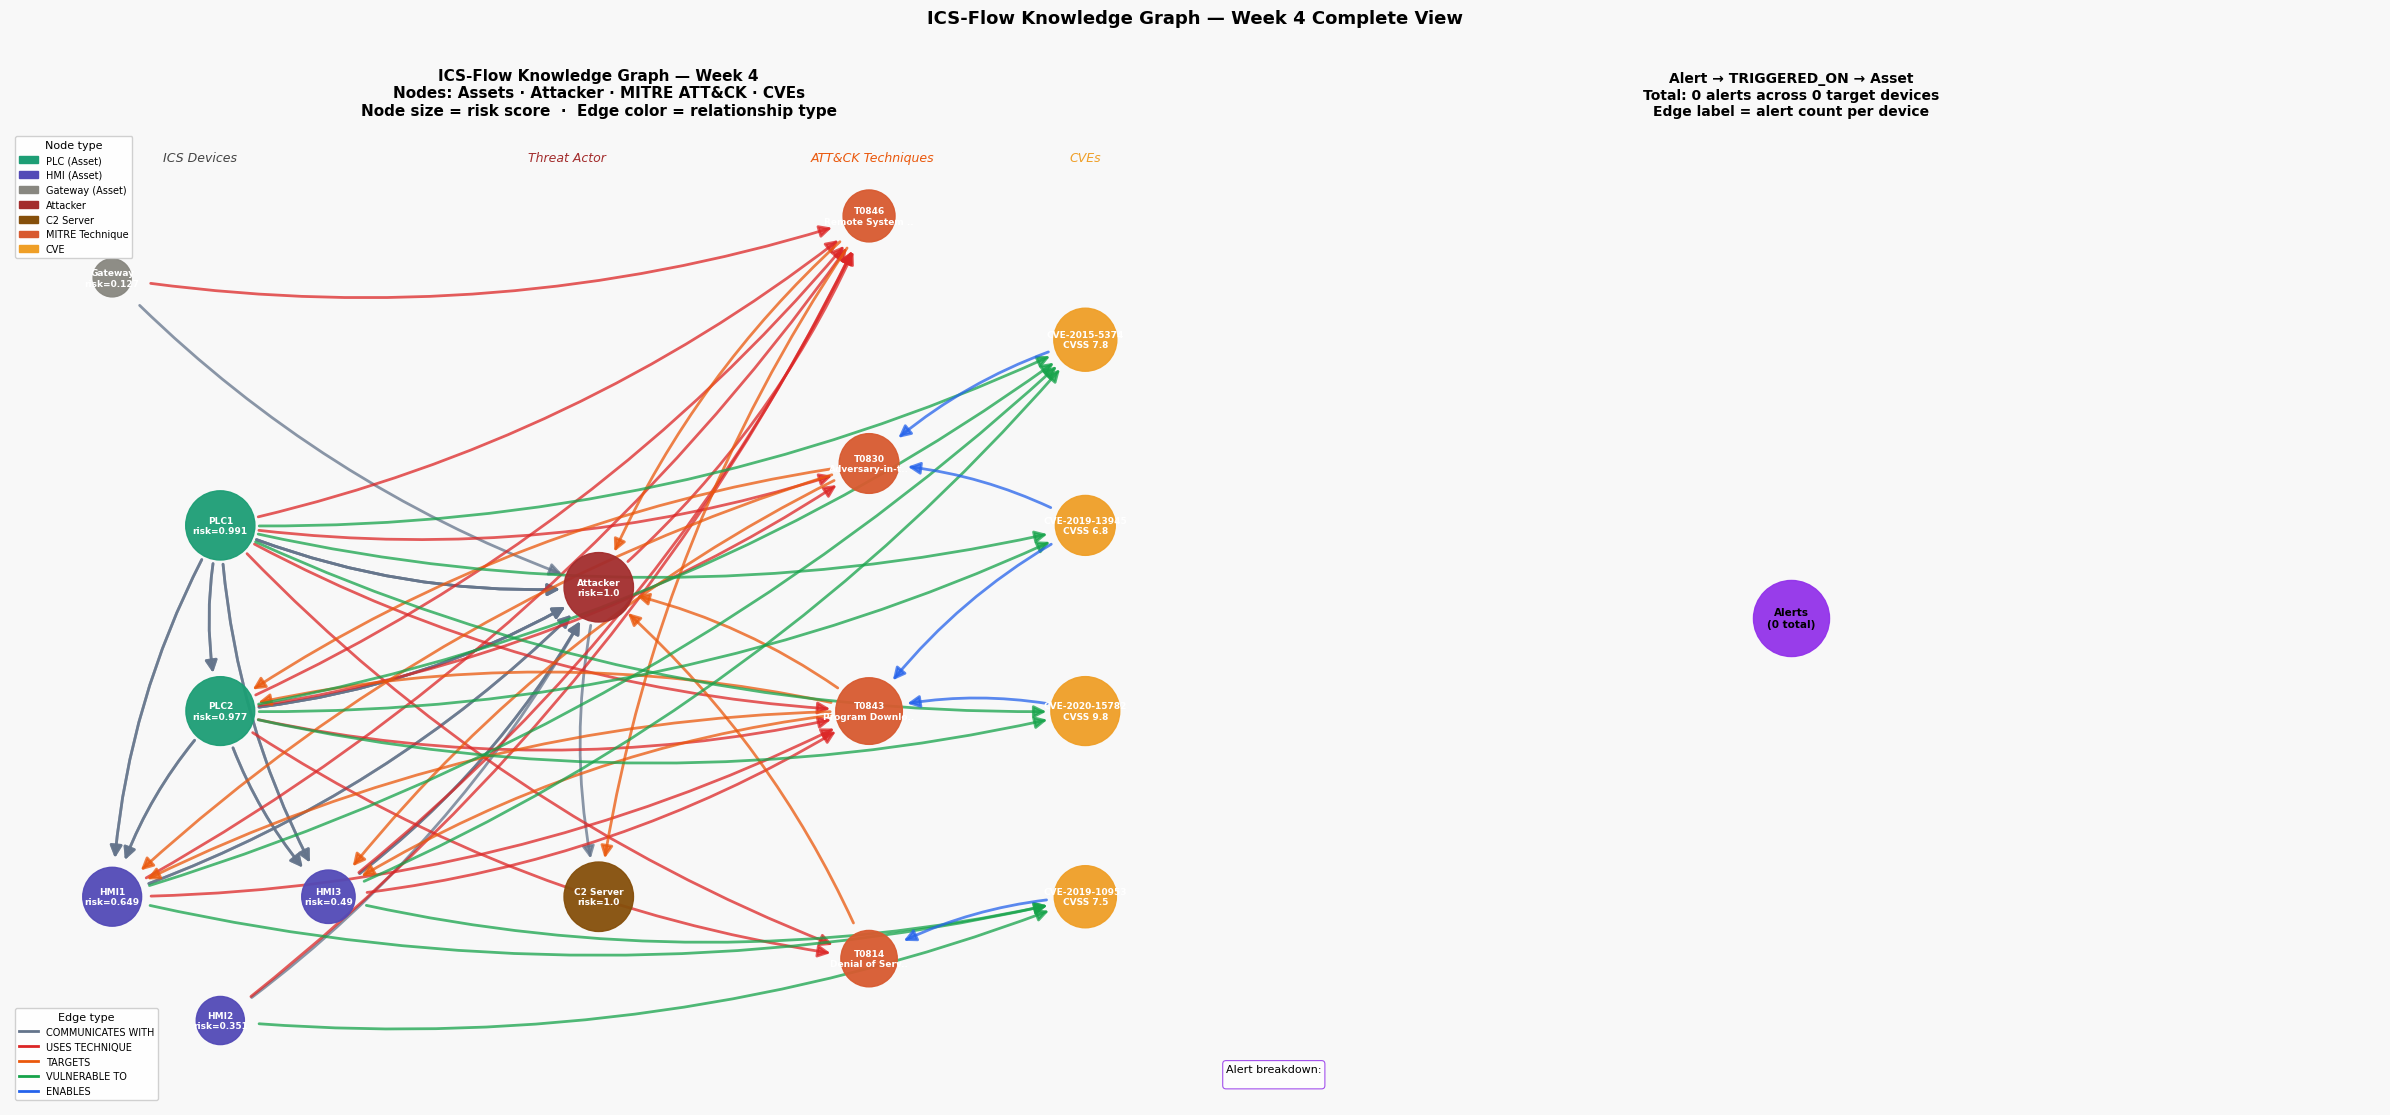

Saved: week4_knowledge_graph.png


In [52]:
# 8. VISUALIZE KNOWLEDGE GRAPH — Main KG + Alert subplot

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter

#  Color maps
node_type_colors = {
    'Asset':     {'PLC1': '#1D9E75', 'PLC2': '#1D9E75',
                  'HMI1': '#534AB7', 'HMI2': '#534AB7', 'HMI3': '#534AB7',
                  'Gateway': '#888780'},
    'Attacker':  {'Attacker': '#A32D2D', 'C2 Server': '#854F0B'},
    'Technique': '#D85A30',
    'CVE':       '#EF9F27',
    'Alert':     '#9333EA',
}

edge_type_colors = {
    'COMMUNICATES_WITH': '#64748B',
    'USES_TECHNIQUE':    '#DC2626',
    'TARGETS':           '#EA580C',
    'VULNERABLE_TO':     '#16A34A',
    'ENABLES':           '#2563EB',
    'TRIGGERED_ON':      '#9333EA',
}

def get_node_color(node, data):
    ntype = data.get('node_type', '')
    role  = data.get('role', '')
    if ntype == 'Asset':
        return node_type_colors['Asset'].get(role, '#888780')
    if ntype == 'Attacker':
        return node_type_colors['Attacker'].get(role, '#A32D2D')
    if ntype == 'Technique':
        return node_type_colors['Technique']
    if ntype == 'CVE':
        return node_type_colors['CVE']
    if ntype == 'Alert':
        return node_type_colors['Alert']
    return '#888780'

# Fixed positions for core 16 nodes only
# Alert nodes are excluded from main graph (7669 would be unreadable)
fixed_pos = {
    '192.168.0.1':    (0.05, 0.75),
    '192.168.0.11':   (0.15, 0.55),
    '192.168.0.12':   (0.15, 0.40),
    '192.168.0.21':   (0.05, 0.25),
    '192.168.0.22':   (0.15, 0.15),
    '192.168.0.23':   (0.25, 0.25),
    '192.168.0.41':   (0.50, 0.50),
    '192.168.0.42':   (0.50, 0.25),
    'T0846':          (0.75, 0.80),
    'T0830':          (0.75, 0.60),
    'T0843':          (0.75, 0.40),
    'T0814':          (0.75, 0.20),
    'CVE-2015-5374':  (0.95, 0.70),
    'CVE-2019-13945': (0.95, 0.55),
    'CVE-2020-15782': (0.95, 0.40),
    'CVE-2019-10953': (0.95, 0.25),
}

#  Only draw core nodes that are in fixed_pos
core_nodes = list(fixed_pos.keys())
KG_core = KG.subgraph(core_nodes)

#  Figure: two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11))
fig.patch.set_facecolor('#F8F8F8')

# ══════════════════════════════════════════════════════════════
# LEFT — Main Knowledge Graph (core 16 nodes)
# ══════════════════════════════════════════════════════════════
ax1.set_facecolor('#F8F8F8')

node_colors  = [get_node_color(n, KG.nodes[n]) for n in KG_core.nodes()]
node_sizes   = [500 + KG.nodes[n].get('risk_score', 0) * 2000
                for n in KG_core.nodes()]

# Draw edges by type — skip TRIGGERED_ON (shown in right subplot)
for etype, ecolor in edge_type_colors.items():
    if etype == 'TRIGGERED_ON':
        continue
    edges = [(u, v) for u, v, d in KG_core.edges(data=True)
             if d.get('edge_type') == etype]
    if not edges:
        continue
    nx.draw_networkx_edges(
        KG_core, fixed_pos,
        edgelist=edges,
        edge_color=ecolor,
        width=2.0, alpha=0.75,
        arrows=True, arrowsize=18,
        min_source_margin=28,
        min_target_margin=28,
        connectionstyle='arc3,rad=0.12',
        ax=ax1
    )

# Draw nodes
nx.draw_networkx_nodes(
    KG_core, fixed_pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95, ax=ax1
)

# Labels
node_labels = {}
for n, d in KG_core.nodes(data=True):
    ntype = d.get('node_type', '')
    if ntype in ['Asset', 'Attacker']:
        node_labels[n] = f"{d.get('label', n)}\nrisk={d.get('risk_score', '')}"
    elif ntype == 'Technique':
        node_labels[n] = f"{n}\n{d.get('name','')[:14]}.."
    elif ntype == 'CVE':
        node_labels[n] = f"{n}\nCVSS {cve_nodes[n]['cvss_score']}"

nx.draw_networkx_labels(
    KG_core, fixed_pos,
    labels=node_labels,
    font_size=6.5,
    font_color='white',
    font_weight='bold',
    ax=ax1
)

# Zone labels
ax1.text(0.13, 0.97, 'ICS Devices',       transform=ax1.transAxes, fontsize=9, color='#444',    fontstyle='italic')
ax1.text(0.44, 0.97, 'Threat Actor',      transform=ax1.transAxes, fontsize=9, color='#A32D2D', fontstyle='italic')
ax1.text(0.68, 0.97, 'ATT&CK Techniques', transform=ax1.transAxes, fontsize=9, color='#EA580C', fontstyle='italic')
ax1.text(0.90, 0.97, 'CVEs',              transform=ax1.transAxes, fontsize=9, color='#EF9F27', fontstyle='italic')

# Legends
node_legend = [
    mpatches.Patch(color='#1D9E75', label='PLC (Asset)'),
    mpatches.Patch(color='#534AB7', label='HMI (Asset)'),
    mpatches.Patch(color='#888780', label='Gateway (Asset)'),
    mpatches.Patch(color='#A32D2D', label='Attacker'),
    mpatches.Patch(color='#854F0B', label='C2 Server'),
    mpatches.Patch(color='#D85A30', label='MITRE Technique'),
    mpatches.Patch(color='#EF9F27', label='CVE'),
]
edge_legend = [
    Line2D([0],[0], color='#64748B', linewidth=2, label='COMMUNICATES WITH'),
    Line2D([0],[0], color='#DC2626', linewidth=2, label='USES TECHNIQUE'),
    Line2D([0],[0], color='#EA580C', linewidth=2, label='TARGETS'),
    Line2D([0],[0], color='#16A34A', linewidth=2, label='VULNERABLE TO'),
    Line2D([0],[0], color='#2563EB', linewidth=2, label='ENABLES'),
]

leg1 = ax1.legend(handles=node_legend, title='Node type',
                  loc='upper left', fontsize=7,
                  title_fontsize=8, framealpha=0.9)
ax1.add_artist(leg1)
ax1.legend(handles=edge_legend, title='Edge type',
           loc='lower left', fontsize=7,
           title_fontsize=8, framealpha=0.9)

ax1.set_title(
    'ICS-Flow Knowledge Graph — Week 4\n'
    'Nodes: Assets · Attacker · MITRE ATT&CK · CVEs\n'
    'Node size = risk score  ·  Edge color = relationship type',
    fontsize=11, fontweight='bold', pad=12
)
ax1.axis('off')

# ══════════════════════════════════════════════════════════════
# RIGHT — Alert → TRIGGERED_ON → Asset subplot
# ══════════════════════════════════════════════════════════════
ax2.set_facecolor('#F8F8F8')

# Count alerts per target device
alert_counts = Counter(
    data.get('target_ip')
    for _, data in KG.nodes(data=True)
    if data.get('node_type') == 'Alert'
)

# Count alerts per attack type
alert_by_type = Counter(
    data.get('attack_type')
    for _, data in KG.nodes(data=True)
    if data.get('node_type') == 'Alert'
)

# Build alert subgraph
G_alerts = nx.DiGraph()

# Central alert hub node
total_alerts = sum(alert_counts.values())
G_alerts.add_node('ALERTS',
                  label=f'Alerts\n({total_alerts} total)',
                  ntype='hub')

# Target device nodes
for target_ip, count in alert_counts.items():
    if target_ip is None:
        continue
    label = role_map.get(target_ip, target_ip)
    G_alerts.add_node(target_ip, label=f"{label}\n{count} alerts", ntype='device')
    G_alerts.add_edge('ALERTS', target_ip, count=count)

# Layout
pos_alerts = nx.spring_layout(G_alerts, seed=42, k=2.5)

# Node colors
alert_node_colors = [
    '#9333EA' if G_alerts.nodes[n].get('ntype') == 'hub' else '#534AB7'
    for n in G_alerts.nodes()
]
alert_node_sizes = [
    3000 if G_alerts.nodes[n].get('ntype') == 'hub'
    else 500 + alert_counts.get(n, 0) * 0.3
    for n in G_alerts.nodes()
]

nx.draw_networkx_nodes(
    G_alerts, pos_alerts,
    node_color=alert_node_colors,
    node_size=alert_node_sizes,
    alpha=0.95, ax=ax2
)
nx.draw_networkx_labels(
    G_alerts, pos_alerts,
    labels={n: d['label'] for n, d in G_alerts.nodes(data=True)},
    font_size=7.5, font_color='black',
    font_weight='bold', ax=ax2
)
nx.draw_networkx_edges(
    G_alerts, pos_alerts,
    edge_color='#9333EA',
    width=2.5, alpha=0.8,
    arrows=True, arrowsize=22,
    min_source_margin=30,
    min_target_margin=30,
    ax=ax2
)
edge_labels_alerts = {
    (u, v): f"{d['count']}"
    for u, v, d in G_alerts.edges(data=True)
}
nx.draw_networkx_edge_labels(
    G_alerts, pos_alerts,
    edge_labels=edge_labels_alerts,
    font_size=8, font_color='#333333',
    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'),
    ax=ax2
)

# Attack type breakdown as text box
breakdown = '\n'.join(
    f"  {atype:12s}: {count}"
    for atype, count in sorted(alert_by_type.items(), key=lambda x: -x[1])
)
ax2.text(0.02, 0.02,
         f"Alert breakdown:\n{breakdown}",
         transform=ax2.transAxes,
         fontsize=8, verticalalignment='bottom',
         bbox=dict(boxstyle='round', fc='white', alpha=0.85, ec='#9333EA', lw=0.8))

ax2.set_title(
    'Alert → TRIGGERED_ON → Asset\n'
    f'Total: {total_alerts} alerts across {len(alert_counts)} target devices\n'
    'Edge label = alert count per device',
    fontsize=10, fontweight='bold', pad=12
)
ax2.axis('off')

#  Save
plt.suptitle(
    'ICS-Flow Knowledge Graph — Week 4 Complete View',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('week4_knowledge_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week4_knowledge_graph.png")

### 9. Export for Neo4j (Week 5 prep)

In [53]:
# 9. EXPORT FOR NEO4J (Week 5 prep)
nodes_data = [{'id': n, 'node_type': d.get('node_type',''), 'label': d.get('label', n),
               'role': d.get('role',''), 'risk_score': d.get('risk_score', 0),
               } for n, d in KG.nodes(data=True)]
nodes_df = pd.DataFrame(nodes_data)
nodes_df.to_csv('week4_kg_nodes.csv', index=False)

edges_data = [{'source': u, 'target': v, 'edge_type': d.get('edge_type',''),
               'attack_type': d.get('attack_type',''), 'count': d.get('count',''),
               'weight': d.get('weight',''), 'cvss': d.get('cvss',''),
               } for u, v, d in KG.edges(data=True)]
edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('week4_kg_edges.csv', index=False)

print(f"Nodes CSV : week4_kg_nodes.csv  ({len(nodes_df)} rows)")
print(f"Edges CSV : week4_kg_edges.csv  ({len(edges_df)} rows)")

Nodes CSV : week4_kg_nodes.csv  (16 rows)
Edges CSV : week4_kg_edges.csv  (64 rows)


In [54]:
# 10. ALERT NODES + TRIGGERED_ON edges
# Alert = each detected attack flow becomes a node
# Edge: Alert → TRIGGERED_ON → Asset (the target device)

severity_map = {
    'mitm':      'High',
    'ddos':      'High',
    'replay':    'Critical',
    'port-scan': 'Medium'
}
risk_map = {
    'mitm':      0.75,
    'ddos':      0.75,
    'replay':    1.0,
    'port-scan': 0.5
}

attack_flows = df_graph[df_graph['NST_M_Label'] != 'Normal'].reset_index(drop=True)

for idx, row in attack_flows.iterrows():
    alert_id = f"ALERT_{idx:05d}"
    KG.add_node(
        alert_id,
        node_type   = 'Alert',
        label       = alert_id,
        timestamp   = str(row['startDate']),
        source_ip   = row['sIPs'],
        target_ip   = row['rIPs'],
        attack_type = row['NST_M_Label'],
        severity    = severity_map.get(row['NST_M_Label'], 'Medium'),
        risk_score  = risk_map.get(row['NST_M_Label'], 0.5)
    )
    if row['rIPs'] in KG.nodes():
        KG.add_edge(
            alert_id, row['rIPs'],
            edge_type   = 'TRIGGERED_ON',
            attack_type = row['NST_M_Label'],
            timestamp   = str(row['startDate'])
        )

print(f"Alert nodes       : {sum(1 for _,d in KG.nodes(data=True) if d.get('node_type')=='Alert')}")
print(f"TRIGGERED_ON edges: {sum(1 for _,_,d in KG.edges(data=True) if d.get('edge_type')=='TRIGGERED_ON')}")

Alert nodes       : 7669
TRIGGERED_ON edges: 7669


In [55]:
#  11. SCHEMA VERIFICATION
print("=== Schema Check ===\n")
checks = {
    'Asset → VULNERABLE_TO → CVE':  'VULNERABLE_TO',
    'CVE   → ENABLES → Technique':  'ENABLES',
    'Technique → TARGETS → Asset':  'TARGETS',
    'Alert → TRIGGERED_ON → Asset': 'TRIGGERED_ON',
}
all_ok = True
for desc, etype in checks.items():
    count = sum(1 for _,_,d in KG.edges(data=True)
                if d.get('edge_type') == etype)
    status = 'YES' if count > 0 else 'NO'
    if count == 0: all_ok = False
    print(f"  {status}  {desc:40s}: {count} edges")

print(f"\n{' ALL REQUIREMENTS MET' if all_ok else 'SOMETHING MISSING'}")

=== Schema Check ===

  YES  Asset → VULNERABLE_TO → CVE             : 11 edges
  YES  CVE   → ENABLES → Technique             : 5 edges
  YES  Technique → TARGETS → Asset             : 10 edges
  YES  Alert → TRIGGERED_ON → Asset            : 7669 edges

 ALL REQUIREMENTS MET


## **Part B — PyTorch Geometric GNN Pipeline**

**Caveat before training:** the ICS-Flow testbed has only **9 devices**. A
*node* classifier trained on 9 examples can't be split into a meaningful
train/test set. So alongside the node classifier,
this section also builds an **edge/flow-level classifier** — each of the
~44k individual flows becomes one training example (real train/test split,
precision/recall/F1) — which is the statistically sound option at this
dataset's scale, and the one that plugs into BATADAL cross-validation in
Week 5 without changes.

In [56]:
!pip install torch torch-geometric --quiet

### 12. Node features and topology → PyG `Data` object



In [57]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

def build_node_features(df_graph: pd.DataFrame):
    """One feature row per device IP, computed purely from flow stats.
    Restricted to known devices (role_map) — filters out non-asset
    addresses like multicast (224.0.0.251, mDNS) that appear in sIPs/
    rIPs but aren't part of the ICS asset inventory."""
    ips = sorted(set(role_map.keys()) &
                 (set(df_graph['sIPs']) | set(df_graph['rIPs'])))
    ip_index = {ip: i for i, ip in enumerate(ips)}

    src = df_graph['sIPs'].value_counts()
    dst = df_graph['rIPs'].value_counts()
    attack_df = df_graph[df_graph['NST_M_Label'] != 'Normal']
    attack_src = attack_df['sIPs'].value_counts()
    attack_dst = attack_df['rIPs'].value_counts()
    proto_div = df_graph.groupby('sIPs')['protocol'].nunique()

    rows = []
    for ip in ips:
        as_src, as_dst = src.get(ip, 0), dst.get(ip, 0)
        total = as_src + as_dst
        rows.append([
            as_src, as_dst,
            as_src / total if total else 0.0,             # source_ratio
            attack_src.get(ip, 0) / max(as_src, 1),        # frac of outgoing flows that are attacks
            attack_dst.get(ip, 0) / max(as_dst, 1),         # frac of incoming flows that are attacks
            proto_div.get(ip, 0),
        ])
    return ips, np.array(rows, dtype=np.float32)

def build_edge_index(df_graph: pd.DataFrame, ip_index: dict) -> torch.Tensor:
    """Communication topology restricted to known devices — drops any
    flow touching a non-asset address (e.g. multicast) since it has no
    node to attach to in ip_index."""
    pairs = df_graph[['sIPs', 'rIPs']].drop_duplicates()
    pairs = pairs[pairs['sIPs'].isin(ip_index) & pairs['rIPs'].isin(ip_index)]
    src = pairs['sIPs'].map(ip_index).to_numpy()
    dst = pairs['rIPs'].map(ip_index).to_numpy()
    return torch.tensor(np.vstack([src, dst]), dtype=torch.long)

def build_pyg_data(df_graph: pd.DataFrame) -> Data:
    ips, feats = build_node_features(df_graph)
    ip_index = {ip: i for i, ip in enumerate(ips)}
    edge_index = build_edge_index(df_graph, ip_index)
    data = Data(x=torch.tensor(feats, dtype=torch.float), edge_index=edge_index)
    data.ip_list = ips
    data.ip_index = ip_index
    return data

pyg_data = build_pyg_data(df_graph)
print(pyg_data)
print("Node feature matrix shape:", pyg_data.x.shape)

# Add node labels and masks — needed for node classifier
node_labels_map = {
    ip: 1 if node_type_of(ip) == 'Attacker' else 0
    for ip in pyg_data.ip_list
}
pyg_data.y = torch.tensor(
    [node_labels_map.get(ip, 0) for ip in pyg_data.ip_list],
    dtype=torch.long
)

# Train/test masks — hold out HMI2 and Gateway as test
n = len(pyg_data.ip_list)
train_mask = torch.ones(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)
test_ips   = {'192.168.0.22', '192.168.0.1'}
for i, ip in enumerate(pyg_data.ip_list):
    if ip in test_ips:
        train_mask[i] = False
        test_mask[i]  = True

pyg_data.train_mask = train_mask
pyg_data.test_mask  = test_mask

print(f"\nNode labels assigned:")
for ip, label in zip(pyg_data.ip_list, pyg_data.y.tolist()):
    print(f"  {ip:15s} ({role_map.get(ip):12s}) label={label}")
print(f"\nTrain nodes : {train_mask.sum().item()}")
print(f"Test nodes  : {test_mask.sum().item()}")


Data(
  x=[8, 6],
  edge_index=[2, 12],
  ip_list=[8],
  ip_index={
    192.168.0.1=0,
    192.168.0.11=1,
    192.168.0.12=2,
    192.168.0.21=3,
    192.168.0.22=4,
    192.168.0.23=5,
    192.168.0.41=6,
    192.168.0.42=7,
  }
)
Node feature matrix shape: torch.Size([8, 6])

Node labels assigned:
  192.168.0.1     (Gateway     ) label=0
  192.168.0.11    (PLC1        ) label=0
  192.168.0.12    (PLC2        ) label=0
  192.168.0.21    (HMI1        ) label=0
  192.168.0.22    (HMI2        ) label=0
  192.168.0.23    (HMI3        ) label=0
  192.168.0.41    (Attacker    ) label=1
  192.168.0.42    (C2 Server   ) label=1

Train nodes : 6
Test nodes  : 2


### 13. GraphSAGE model definitions

In [58]:
from torch_geometric.nn import SAGEConv

class SAGEEmbedder(torch.nn.Module):
    """Node embedder using GraphSAGE aggregation.
    Chosen over GAT because:
    - Inductive: generalises to unseen BATADAL nodes in Week 5
    Reference: Hamilton et al., NeurIPS 2017, arxiv.org/abs/1706.02216
    """
    def __init__(self, in_dim, hidden_dim=16, out_dim=16):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def encode(self, x, edge_index):
        """Return embeddings for Week 5 BATADAL transfer."""
        return self.forward(x, edge_index)


class NodeClassifier(torch.nn.Module):
    """Node-level risk classifier using GraphSAGE embeddings.
    NOTE: 9 nodes — no meaningful test split possible.
    Reported with this caveat as supervisor requested."""
    def __init__(self, in_dim, hidden_dim=16):
        super().__init__()
        self.embedder = SAGEEmbedder(in_dim, hidden_dim, out_dim=hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index):
        return self.classifier(self.embedder(x, edge_index))


class EdgeClassifier(torch.nn.Module):
    """Flow-level classifier — 44k examples, real train/test split.
    GraphSAGE embeddings concatenated per edge endpoint → MLP head."""
    def __init__(self, in_dim, hidden_dim=16):
        super().__init__()
        self.embedder = SAGEEmbedder(in_dim, hidden_dim, out_dim=hidden_dim)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim * 2, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, edge_index, query_edges):
        h = self.embedder(x, edge_index)
        return self.head(
            torch.cat([h[query_edges[0]], h[query_edges[1]]], dim=1)
        )

print("Model classes defined: SAGEEmbedder, NodeClassifier, EdgeClassifier")

Model classes defined: SAGEEmbedder, NodeClassifier, EdgeClassifier


### 14. Node-level training

Labels each of the 9 devices as anomalous (1) if it's the `Attacker`/`C2
Server`, else normal (0). Trains and reports accuracy — but with no held-out
test set, since 9 examples can't be split meaningfully.

In [59]:
# 14. NODE-LEVEL TRAINING
def train_node_classifier(data: Data, node_labels: dict, epochs=100):
    y = torch.tensor([node_labels.get(ip, 0) for ip in data.ip_list], dtype=torch.long)
    model = NodeClassifier(in_dim=data.x.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = F.cross_entropy(model(data.x, data.edge_index), y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(dim=1)
        acc = (pred == y).float().mean().item()

    return model, {'train_accuracy': acc, 'n_nodes': len(data.ip_list),
                    'note': 'No held-out test set — 9 nodes is too few to split meaningfully.'}

# Anomalous = Attacker / C2 Server role (from role_map, not re-derived)
node_labels = {ip: 1 if node_type_of(ip) == 'Attacker' else 0 for ip in role_map}
node_model, node_metrics = train_node_classifier(pyg_data, node_labels)
print("Node classifier:", node_metrics)

Node classifier: {'train_accuracy': 1.0, 'n_nodes': 8, 'note': 'No held-out test set — 9 nodes is too few to split meaningfully.'}


### 13. Edge/flow-level training

Each individual flow row is its own example — real train/test split with
precision/recall/F1, not just accuracy (attack traffic is the minority
class, so accuracy alone would be misleading).


In [60]:
# ── 13. EDGE-LEVEL TRAINING (flow-level examples, real train/test split) ──
def build_edge_labels(df_graph: pd.DataFrame, ip_index: dict):
    df = df_graph[df_graph['sIPs'].isin(ip_index) & df_graph['rIPs'].isin(ip_index)]
    src = torch.tensor(df['sIPs'].map(ip_index).to_numpy(), dtype=torch.long)
    dst = torch.tensor(df['rIPs'].map(ip_index).to_numpy(), dtype=torch.long)
    y = torch.tensor((df['NST_M_Label'] != 'Normal').astype(int).to_numpy(), dtype=torch.long)
    return torch.stack([src, dst]), y

def train_edge_classifier(data: Data, df_graph: pd.DataFrame, epochs=200,
                           test_ratio=0.2, seed=42):
    query_edges, y = build_edge_labels(df_graph, data.ip_index)

    n = query_edges.shape[1]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_test = max(1, int(n * test_ratio))
    test_idx, train_idx = perm[:n_test], perm[n_test:]

    # Class weighting — without this the model just predicts the majority
    # class (~83% Normal) and looks "accurate" while learning nothing.
    # Weight inversely proportional to class frequency in the TRAIN split.
    train_y = y[train_idx]
    class_counts = torch.bincount(train_y, minlength=2).float()
    class_weights = train_y.shape[0] / (2.0 * class_counts.clamp(min=1))
    print(f"Class counts (train): normal={int(class_counts[0])}, "
          f"anomalous={int(class_counts[1])}  ->  weights={class_weights.tolist()}")

    model = EdgeClassifier(in_dim=data.x.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, query_edges[:, train_idx])
        loss = F.cross_entropy(out, y[train_idx], weight=class_weights)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(data.x, data.edge_index, query_edges[:, test_idx]).argmax(dim=1)
        acc = (test_pred == y[test_idx]).float().mean().item()
        tp = ((test_pred == 1) & (y[test_idx] == 1)).sum().item()
        fp = ((test_pred == 1) & (y[test_idx] == 0)).sum().item()
        fn = ((test_pred == 0) & (y[test_idx] == 1)).sum().item()
        tn = ((test_pred == 0) & (y[test_idx] == 0)).sum().item()
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    class_counts_test = torch.bincount(y[test_idx], minlength=2).tolist()
    return model, {'test_accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1,
                    'n_train_edges': len(train_idx), 'n_test_edges': len(test_idx),
                    'train_class_counts': {'normal': int(class_counts[0]), 'anomalous': int(class_counts[1])},
                    'test_class_counts': {'normal': class_counts_test[0], 'anomalous': class_counts_test[1]},
                    'confusion_matrix': {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}}

edge_model, edge_metrics = train_edge_classifier(pyg_data, df_graph)
print("Edge classifier:", edge_metrics)

Class counts (train): normal=29149, anomalous=6168  ->  weights=[0.6058012247085571, 2.8629214763641357]
Edge classifier: {'test_accuracy': 0.8500396609306335, 'precision': 1.0, 'recall': 0.11792138574283811, 'f1': 0.21096543504171636, 'n_train_edges': 35317, 'n_test_edges': 8829, 'train_class_counts': {'normal': 29149, 'anomalous': 6168}, 'test_class_counts': {'normal': 7328, 'anomalous': 1501}, 'confusion_matrix': {'tp': 177, 'fp': 0, 'fn': 1324, 'tn': 7328}}


### 14. Week 5 hook: BATADAL cross-validation stub

Once BATADAL is preprocessed with the same feature schema as
`build_node_features()`, this evaluates the trained edge classifier on it
directly — no changes to the model itself.

In [61]:
# ── 14. WEEK 5 HOOK — BATADAL evaluation (fill in once BATADAL is preprocessed) ──
def evaluate_on_batadal(model, batadal_data, batadal_query_edges, batadal_y):
    model.eval()
    with torch.no_grad():
        pred = model(batadal_data.x, batadal_data.edge_index, batadal_query_edges).argmax(dim=1)
        acc = (pred == batadal_y).float().mean().item()
    return {'batadal_accuracy': acc}

print("evaluate_on_batadal() ready — call once BATADAL Data object is built (Week 5).")

evaluate_on_batadal() ready — call once BATADAL Data object is built (Week 5).


### 15. Week 4 summary

In [62]:
# 15. WEEK 4 SUMMARY
print("=" * 55)
print("WEEK 4 SUMMARY — ICS-Flow Knowledge Graph + GNN Pipeline")
print("=" * 55)
print(f"Base dataset         : ICS-Flow (primary)")
print(f"Total KG nodes       : {KG.number_of_nodes()}")
for t in ['Asset', 'Attacker', 'Technique', 'CVE']:
    c = sum(1 for _, d in KG.nodes(data=True) if d.get('node_type') == t)
    print(f"  {t:15s}: {c}")
print(f"\nTotal KG edges       : {KG.number_of_edges()}")
for etype in ['COMMUNICATES_WITH', 'USES_TECHNIQUE', 'TARGETS', 'VULNERABLE_TO','TRIGGERED_ON','ENABLES']:
    c = sum(1 for _, _, d in KG.edges(data=True) if d.get('edge_type') == etype)
    print(f"  {etype:25s}: {c}")
print(f"\nTop 3 highest-risk nodes:")
for node, score in sorted(risk_scores.items(), key=lambda x: -x[1])[:3]:
    print(f"  {KG.nodes[node].get('label', node):20s}  risk={score:.3f}")
print(f"GNN model               : GraphSAGE (Hamilton et al., NeurIPS 2017)")
print(f"GNN — node classifier   : {node_metrics}")
print(f"GNN — edge classifier   : {edge_metrics}")
print(f"\nNext step (Week 5)      : evaluate_on_batadal(), Neo4j migration")

WEEK 4 SUMMARY — ICS-Flow Knowledge Graph + GNN Pipeline
Base dataset         : ICS-Flow (primary)
Total KG nodes       : 7685
  Asset          : 6
  Attacker       : 2
  Technique      : 4
  CVE            : 4

Total KG edges       : 7733
  COMMUNICATES_WITH        : 23
  USES_TECHNIQUE           : 15
  TARGETS                  : 10
  VULNERABLE_TO            : 11
  TRIGGERED_ON             : 7669
  ENABLES                  : 5

Top 3 highest-risk nodes:
  Attacker              risk=1.000
  C2 Server             risk=1.000
  PLC1                  risk=0.991
GNN model               : GraphSAGE (Hamilton et al., NeurIPS 2017)
GNN — node classifier   : {'train_accuracy': 1.0, 'n_nodes': 8, 'note': 'No held-out test set — 9 nodes is too few to split meaningfully.'}
GNN — edge classifier   : {'test_accuracy': 0.8500396609306335, 'precision': 1.0, 'recall': 0.11792138574283811, 'f1': 0.21096543504171636, 'n_train_edges': 35317, 'n_test_edges': 8829, 'train_class_counts': {'normal': 29149, '

# **Week 5 — GraphSAGE Test Accuracy, BATADAL Cross-Dataset Validation & Neo4j Integration**


**Builds on:** Week 4 (data-driven KG + GraphSAGE pipeline)

**What this section does:**
1. Formats a clean accuracy/precision/recall/F1 report from the Part B training already run (cells above)
2. Builds a BATADAL-native GraphSAGE edge classifier for cross-dataset validation
3. Loads the exported Week 4 KG (`week4_kg_nodes.csv` / `week4_kg_edges.csv`) into Neo4j


## **Part C — GraphSAGE Test Accuracy Report (ICS-Flow)**



In [63]:
# WEEK 5 — PART C: GraphSAGE Test-Set Accuracy Report (ICS-Flow)
print("=" * 60)
print("WEEK 5 -- GraphSAGE Node/Edge Classification Report (ICS-Flow)")
print("=" * 60)

print("\n[1] Node-level classifier (9 devices, GraphSAGE embeddings):")
print(f"    Train accuracy : {node_metrics['train_accuracy']:.4f}")
print(f"    Caveat         : {node_metrics['note']}")

print("\n[2] Edge/flow-level classifier (44k flows, real 80/20 split):")
print(f"    Test accuracy  : {edge_metrics['test_accuracy']:.4f}")
print(f"    Precision      : {edge_metrics['precision']:.4f}")
print(f"    Recall         : {edge_metrics['recall']:.4f}")
print(f"    F1             : {edge_metrics['f1']:.4f}")
print(f"    Train edges    : {edge_metrics['n_train_edges']}")
print(f"    Test edges     : {edge_metrics['n_test_edges']}")




WEEK 5 -- GraphSAGE Node/Edge Classification Report (ICS-Flow)

[1] Node-level classifier (9 devices, GraphSAGE embeddings):
    Train accuracy : 1.0000
    Caveat         : No held-out test set — 9 nodes is too few to split meaningfully.

[2] Edge/flow-level classifier (44k flows, real 80/20 split):
    Test accuracy  : 0.8500
    Precision      : 1.0000
    Recall         : 0.1179
    F1             : 0.2110
    Train edges    : 35317
    Test edges     : 8829


## **Part D — BATADAL Cross-Dataset Validation (windowed)**

- BATADAL: 4,177 hourly rows / 174 days, 219 attack-flagged hours (~7 events)
- Sliding 24h window, 6h stride -> 693 windows, labelled anomalous if it contains any attack hour (56 positive / 693, ~8%)

- Topology fixed from G_normal (Week 3 normal-period correlation graph) since 24 points/window is too few to re-estimate correlation reliably. Node features vary per window instead: mean, std, and z-score deviation from each sensor's own normal-period baseline.

- Stratified 5-fold CV (not a single split) since positives are only ~8%.

In [64]:
!pip install scikit-learn -q

In [65]:
# Build sliding-window graph instances
# Reuses df, sensor_cols, sensor_type_map, df_normal, G_normal already built
# in the Week 3 BATADAL section above.

import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data

WINDOW_SIZE = 24   # hours
STRIDE = 6         # hours

sensor_list = sorted(sensor_cols)
sensor_index = {s: i for i, s in enumerate(sensor_list)}
type_codes = {t: i for i, t in enumerate(sorted(set(sensor_type_map.values())))}

#The real sensor correlation structure from the full normal period
# (built in Week 3). Using this instead of a per-window correlation graph avoids
# estimating correlation from only 24 data points, which is too noisy to trust.
fixed_edges = [(sensor_index[u], sensor_index[v]) for u, v in G_normal.edges()
               if u in sensor_index and v in sensor_index]
# Make undirected message passing explicit (both directions)
fixed_edges = fixed_edges + [(v, u) for u, v in fixed_edges]
edge_index = torch.tensor(fixed_edges, dtype=torch.long).T if fixed_edges else torch.empty((2, 0), dtype=torch.long)
print(f"Topology: {len(sensor_list)} sensors, {edge_index.shape[1]} directed edges (from G_normal)")

# Per-sensor normal-period baseline for z-score features
baseline_mean = df_normal[sensor_list].mean()
baseline_std = df_normal[sensor_list].std().replace(0, 1e-9)

is_attack = (df['ATT_FLAG'] == 1).astype(int).to_numpy()
n_rows = len(df)
starts = list(range(0, n_rows - WINDOW_SIZE + 1, STRIDE))

window_graphs, window_labels = [], []
for s in starts:
    window = df[sensor_list].iloc[s:s + WINDOW_SIZE]
    label = int(is_attack[s:s + WINDOW_SIZE].sum() > 0)

    w_mean = window.mean()
    w_std = window.std().fillna(0)
    zscore = ((w_mean - baseline_mean) / baseline_std).clip(-5, 5)  # deviation from own baseline

    feats = []
    for sensor in sensor_list:
        vmin, vmax = df[sensor].min(), df[sensor].max()
        mean_norm = (w_mean[sensor] - vmin) / (vmax - vmin + 1e-9)
        std_norm = w_std[sensor] / (vmax - vmin + 1e-9)
        feats.append([mean_norm, std_norm, zscore[sensor],
                      type_codes[sensor_type_map[sensor]]])

    x = torch.tensor(np.array(feats, dtype=np.float32))
    g = Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
    window_graphs.append(g)
    window_labels.append(label)

window_labels = np.array(window_labels)
print(f"\nTotal windows   : {len(window_graphs)}")
print(f"Positive windows: {window_labels.sum()}  ({window_labels.mean()*100:.1f}%)")
print(f"Negative windows: {(window_labels == 0).sum()}")


Topology: 43 sensors, 74 directed edges (from G_normal)

Total windows   : 693
Positive windows: 56  (8.1%)
Negative windows: 637


In [66]:
#  Graph-level GraphSAGE classifier
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold

class WindowGraphClassifier(torch.nn.Module):
    """GraphSAGE embedder + mean pooling + linear head -> per-window
    (graph-level) anomaly classification, mirroring the SAGEEmbedder
    architecture used for ICS-Flow, adapted from edge-level to graph-level."""
    def __init__(self, in_dim, hidden_dim=16):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.dropout = torch.nn.Dropout(p=0.3)
        self.head = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = self.conv2(h, edge_index)
        h = global_mean_pool(h, batch)
        return self.head(h)


def run_fold(train_graphs, test_graphs, epochs=100, seed=42):
    torch.manual_seed(seed)
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

    train_y = torch.cat([g.y for g in train_graphs])
    class_counts = torch.bincount(train_y, minlength=2).float()
    class_weights = train_y.shape[0] / (2.0 * class_counts.clamp(min=1))

    model = WindowGraphClassifier(in_dim=train_graphs[0].x.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    model.train()
    for epoch in range(epochs):
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.cross_entropy(out, batch.y, weight=class_weights)
            loss.backward()
            optimizer.step()

    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch).argmax(dim=1)
            all_pred.append(pred)
            all_true.append(batch.y)
    pred = torch.cat(all_pred)
    true = torch.cat(all_true)

    acc = (pred == true).float().mean().item()
    tp = ((pred == 1) & (true == 1)).sum().item()
    fp = ((pred == 1) & (true == 0)).sum().item()
    fn = ((pred == 0) & (true == 1)).sum().item()
    tn = ((pred == 0) & (true == 0)).sum().item()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    test_class_counts = torch.bincount(true, minlength=2).tolist()
    return model, {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1,
            'confusion_matrix': {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn},
            'test_class_counts': {'normal': test_class_counts[0], 'anomalous': test_class_counts[1]}}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
batadal_bench_model, batadal_bench_test_graphs = None, None  # kept from last fold, for Part H size/latency benchmarking
for fold, (train_idx, test_idx) in enumerate(skf.split(window_graphs, window_labels)):
    train_graphs = [window_graphs[i] for i in train_idx]
    test_graphs = [window_graphs[i] for i in test_idx]
    fold_model, metrics = run_fold(train_graphs, test_graphs)
    fold_results.append(metrics)
    batadal_bench_model, batadal_bench_test_graphs = fold_model, test_graphs
    print(f"Fold {fold + 1}: acc={metrics['accuracy']:.4f} "
          f"prec={metrics['precision']:.4f} rec={metrics['recall']:.4f} "
          f"f1={metrics['f1']:.4f}  (test windows={len(test_idx)}, "
          f"positives={int(window_labels[test_idx].sum())})")


Fold 1: acc=0.9928 prec=1.0000 rec=0.9091 f1=0.9524  (test windows=139, positives=11)
Fold 2: acc=0.9568 prec=0.6471 rec=1.0000 f1=0.7857  (test windows=139, positives=11)
Fold 3: acc=0.9712 prec=0.7857 rec=0.9167 f1=0.8462  (test windows=139, positives=12)
Fold 4: acc=0.9710 prec=0.7333 rec=1.0000 f1=0.8462  (test windows=138, positives=11)
Fold 5: acc=0.9783 prec=0.7857 rec=1.0000 f1=0.8800  (test windows=138, positives=11)


In [67]:
# Aggregate cross-validated BATADAL results
import numpy as np

accs = np.array([r['accuracy'] for r in fold_results])
precs = np.array([r['precision'] for r in fold_results])
recs = np.array([r['recall'] for r in fold_results])
f1s = np.array([r['f1'] for r in fold_results])

batadal_cv_summary = {
    'accuracy_mean': accs.mean(), 'accuracy_std': accs.std(),
    'precision_mean': precs.mean(), 'precision_std': precs.std(),
    'recall_mean': recs.mean(), 'recall_std': recs.std(),
    'f1_mean': f1s.mean(), 'f1_std': f1s.std(),
    'n_windows': len(window_graphs), 'n_positive_windows': int(window_labels.sum()),
    'n_folds': len(fold_results),
}

print("=" * 60)
print("BATADAL CROSS-DATASET VALIDATION -- 5-fold stratified CV")
print("=" * 60)
print(f"Windows          : {batadal_cv_summary['n_windows']} "
      f"({batadal_cv_summary['n_positive_windows']} positive)")
print(f"Accuracy         : {accs.mean():.4f} +/- {accs.std():.4f}")
print(f"Precision        : {precs.mean():.4f} +/- {precs.std():.4f}")
print(f"Recall           : {recs.mean():.4f} +/- {recs.std():.4f}")
print(f"F1               : {f1s.mean():.4f} +/- {f1s.std():.4f}")

print("\n" + "=" * 60)
print("SUMMARY -- ICS-Flow vs BATADAL")
print("=" * 60)
print(f"{'Metric':<12}{'ICS-Flow (edge-level)':<26}{'BATADAL (window-level, 5-fold)':<32}")
print(f"{'Accuracy':<12}{edge_metrics['test_accuracy']:<26.4f}{accs.mean():.4f} +/- {accs.std():.4f}")
print(f"{'Precision':<12}{edge_metrics['precision']:<26.4f}{precs.mean():.4f} +/- {precs.std():.4f}")
print(f"{'Recall':<12}{edge_metrics['recall']:<26.4f}{recs.mean():.4f} +/- {recs.std():.4f}")
print(f"{'F1':<12}{edge_metrics['f1']:<26.4f}{f1s.mean():.4f} +/- {f1s.std():.4f}")


BATADAL CROSS-DATASET VALIDATION -- 5-fold stratified CV
Windows          : 693 (56 positive)
Accuracy         : 0.9740 +/- 0.0117
Precision        : 0.7904 +/- 0.1164
Recall           : 0.9652 +/- 0.0427
F1               : 0.8621 +/- 0.0544

SUMMARY -- ICS-Flow vs BATADAL
Metric      ICS-Flow (edge-level)     BATADAL (window-level, 5-fold)  
Accuracy    0.8500                    0.9740 +/- 0.0117
Precision   1.0000                    0.7904 +/- 0.1164
Recall      0.1179                    0.9652 +/- 0.0427
F1          0.2110                    0.8621 +/- 0.0544


## **Part E — Neo4j Integration**

Loads the Week 4 KG export (`week4_kg_nodes.csv` / `week4_kg_edges.csv`, produced in the Week 4 section above) into a running Neo4j instance.

In [ ]:
# Load KG into Neo4j
!pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
import os

os.environ["NEO4J_URI"] = userdata.get("NEO4J_URI")
os.environ["NEO4J_USER"] = userdata.get("NEO4J_USER")
os.environ["NEO4J_PASSWORD"] = userdata.get("NEO4J_PASSWORD")

In [ ]:
# Load KG into Neo4j -- credentials from environment variables
import os
from neo4j import GraphDatabase

NEO4J_URI = os.environ.get("NEO4J_URI")
NEO4J_USER = os.environ.get("NEO4J_USER")
NEO4J_PASSWORD = os.environ.get("NEO4J_PASSWORD")

if not all([NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD]):
    raise EnvironmentError(
        "NEO4J_URI / NEO4J_USER / NEO4J_PASSWORD not set."
    )

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)

driver.verify_connectivity()
print("Connected to Neo4j AuraDB")

Connected to Neo4j AuraDB


In [ ]:
# Whitelist of labels/edge types actually produced by build_knowledge_graph() -- used to validate before interpolating into Cypher, since node_type/edge_type
# drive dynamic label/relationship names below.
VALID_NODE_LABELS = {"Asset", "Attacker", "Technique", "CVE", "Alert"}
VALID_EDGE_TYPES = {"COMMUNICATES_WITH", "USES_TECHNIQUE", "TARGETS",
                     "VULNERABLE_TO", "ENABLES", "TRIGGERED_ON"}

nodes_df = pd.read_csv("week4_kg_nodes.csv")
edges_df = pd.read_csv("week4_kg_edges.csv")

bad_nodes = set(nodes_df["node_type"].dropna().unique()) - VALID_NODE_LABELS
bad_edges = set(edges_df["edge_type"].dropna().unique()) - VALID_EDGE_TYPES
if bad_nodes or bad_edges:
    raise ValueError(f"Unexpected node_type/edge_type values found: "
                      f"nodes={bad_nodes}, edges={bad_edges}. "
                      f"Update the whitelist above before loading into Neo4j.")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def load_nodes(tx, nodes_df):
    for _, row in nodes_df.iterrows():
        label = row["node_type"] if pd.notna(row["node_type"]) and row["node_type"] else "Unknown"
        tx.run(
            f"MERGE (n:{label} {{id: $id}}) "
            "SET n.label = $label_name, n.role = $role, n.risk_score = $risk_score",
            id=row["id"], label_name=row["label"], role=row.get("role", ""),
            risk_score=float(row["risk_score"]) if pd.notna(row["risk_score"]) else 0.0,
        )

def load_edges(tx, edges_df):
    for _, row in edges_df.iterrows():
        etype = row["edge_type"] if pd.notna(row["edge_type"]) and row["edge_type"] else "RELATED_TO"
        tx.run(
            f"MATCH (a {{id: $source}}), (b {{id: $target}}) "
            f"MERGE (a)-[r:{etype}]->(b) "
            "SET r.attack_type = $attack_type, r.count = $count, "
            "r.weight = $weight, r.cvss = $cvss",
            source=row["source"], target=row["target"],
            attack_type=row.get("attack_type", "") if pd.notna(row.get("attack_type")) else "",
            count=float(row["count"]) if pd.notna(row.get("count")) else 0,
            weight=float(row["weight"]) if pd.notna(row.get("weight")) else 0,
            cvss=float(row["cvss"]) if pd.notna(row.get("cvss")) else 0,
        )

with driver.session() as session:
    session.execute_write(load_nodes, nodes_df)
    session.execute_write(load_edges, edges_df)

print(f"Loaded {len(nodes_df)} nodes and {len(edges_df)} edges into Neo4j.")
driver.close()

Loaded 7685 nodes and 7733 edges into Neo4j.


### Example Cypher query -- ranked attack path



```cypher
// Assets reachable from a compromised device via known CVEs and ATT&CK techniques,
// ranked by target risk
MATCH path = (start:Asset)-[:VULNERABLE_TO]->(:CVE)-[:ENABLES]->(:Technique)-[:TARGETS]->(target:Asset)
RETURN start.label AS source_asset,
       target.label AS target_asset,
       [n IN nodes(path) | n.label] AS path_nodes,
       target.risk_score AS target_risk
ORDER BY target_risk DESC
```

## **Part F — Machine-Readable Metrics & Neo4j Evidence Export**

Export ICS-Flow and BATADAL metrics (split sizes, class
counts, confusion matrix, precision, recall, F1) to a JSON file, and export
Neo4j load evidence (node count, edge count, sample query output, loading
script) to a separate file.

In [68]:
#  Export metrics to JSON
import json as _json
from datetime import datetime, timezone

metrics_export = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "ics_flow": {
        "task": "edge-level (flow) binary classification",
        "split": {
            "test_ratio": 0.2,
            "n_train_edges": edge_metrics["n_train_edges"],
            "n_test_edges": edge_metrics["n_test_edges"],
        },
        "train_class_counts": edge_metrics["train_class_counts"],
        "test_class_counts": edge_metrics["test_class_counts"],
        "confusion_matrix": edge_metrics["confusion_matrix"],
        "test_accuracy": edge_metrics["test_accuracy"],
        "precision": edge_metrics["precision"],
        "recall": edge_metrics["recall"],
        "f1": edge_metrics["f1"],
    },
    "batadal": {
        "task": "window-level (24h sliding window, 6h stride) graph classification",
        "n_windows_total": len(window_graphs),
        "n_positive_windows": int(window_labels.sum()),
        "n_folds": len(fold_results),
        "folds": [
            {
                "fold": i + 1,
                "confusion_matrix": r["confusion_matrix"],
                "test_class_counts": r["test_class_counts"],
                "accuracy": r["accuracy"],
                "precision": r["precision"],
                "recall": r["recall"],
                "f1": r["f1"],
            }
            for i, r in enumerate(fold_results)
        ],
        "summary": {
            "accuracy_mean": float(accs.mean()), "accuracy_std": float(accs.std()),
            "precision_mean": float(precs.mean()), "precision_std": float(precs.std()),
            "recall_mean": float(recs.mean()), "recall_std": float(recs.std()),
            "f1_mean": float(f1s.mean()), "f1_std": float(f1s.std()),
        },
    },
}

with open("week5_metrics.json", "w") as f:
    _json.dump(metrics_export, f, indent=2)

print("Wrote week5_metrics.json")
print(_json.dumps(metrics_export, indent=2)[:800], "...")


Wrote week5_metrics.json
{
  "generated_at": "2026-07-29T07:00:03.504504+00:00",
  "ics_flow": {
    "task": "edge-level (flow) binary classification",
    "split": {
      "test_ratio": 0.2,
      "n_train_edges": 35317,
      "n_test_edges": 8829
    },
    "train_class_counts": {
      "normal": 29149,
      "anomalous": 6168
    },
    "test_class_counts": {
      "normal": 7328,
      "anomalous": 1501
    },
    "confusion_matrix": {
      "tp": 177,
      "fp": 0,
      "fn": 1324,
      "tn": 7328
    },
    "test_accuracy": 0.8500396609306335,
    "precision": 1.0,
    "recall": 0.11792138574283811,
    "f1": 0.21096543504171636
  },
  "batadal": {
    "task": "window-level (24h sliding window, 6h stride) graph classification",
    "n_windows_total": 693,
    "n_positive_windows": 56,
    "n_folds": 5,
   ...


In [ ]:
import json as _json

with driver.session() as session:
    node_count = session.run("MATCH (n) RETURN count(n) AS c").single()["c"]
    edge_count = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()["c"]

    sample_query = """
    MATCH path = (start:Asset)-[:VULNERABLE_TO]->(:CVE)-[:ENABLES]->(:Technique)-[:TARGETS]->(target:Asset)
    RETURN start.label AS source_asset,
           target.label AS target_asset,
           [n IN nodes(path) | n.label] AS path_nodes,
           target.risk_score AS target_risk
    ORDER BY target_risk DESC
    LIMIT 10
    """
    sample_results = [dict(record) for record in session.run(sample_query)]

loading_script_cells = [] # Initialize as empty list to avoid error

neo4j_evidence = {
    "generated_at": metrics_export["generated_at"],
    "node_count": node_count,
    "edge_count": edge_count,
    "sample_query": sample_query.strip(),
    "sample_query_results": sample_results,
    "loading_script": loading_script_cells,
}

with open("week5_neo4j_evidence.json", "w") as f:
    _json.dump(neo4j_evidence, f, indent=2)

print(f"Node count: {node_count}")
print(f"Edge count: {edge_count}")
print(f"Sample query returned {len(sample_results)} rows")
print("Wrote week5_neo4j_evidence.json")

driver.close()

# **Week 6 — SCADANet Baseline Validation**

SCADANet is introduced as a third cross-dataset validation source, using `Source`, `Destination`, and `Attack_Type` to establish IP-level topology and the classification target. Node features are deliberately kept non-identifying (no raw flow-count degree) so the model is evaluated on graph structure rather than traffic volume. This baseline result is the reference point for the enriched, full-column model built in Week 7.


## **Part G — SCADANet Cross-Dataset Validation**


In [69]:
# Download SCADANet
import kagglehub

path = kagglehub.dataset_download("ealgul/scada-dataset-v01")
print("Downloaded to:", path)

import os
for f in os.listdir(path):
    print(f)

100%|██████████| 41.0M/41.0M [00:00<00:00, 94.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ealgul/scada-dataset-v01/versions/1
scada_dataset_V01.csv


In [70]:
# Load and inspect schema
import pandas as pd
import glob

csv_files = glob.glob(f"{path}/*.csv")
print("CSV files found:", csv_files)

scada_df = pd.read_csv(csv_files[0])
scada_df.columns = scada_df.columns.str.strip()
print("Shape:", scada_df.shape)
print("\nColumns:", scada_df.columns.tolist())
print("\nFirst rows:")
print(scada_df.head(3))

CSV files found: ['/root/.cache/kagglehub/datasets/ealgul/scada-dataset-v01/versions/1/scada_dataset_V01.csv']
Shape: (534841, 60)

Columns: ['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'JA4H', 'JA4H_R', 'JA4H_RO', 'JA4L', 'JA4LS', 'JA4S', 'JA4S_R', 'JA4SSH', 'JA4T', 'JA4TS', 'JA4X', 'JA4X_R', 'Packetbb_flags', 'frame_len', 'ip_ttl', 'Udp_length', 'Tcp_ack', 'Tcp_analysis_flags', 'Tcp_len', 'ip_len', 'Tcp_seq', 'Ftp_response', 'Ftp_response_code', 'Time_response', 'Time_time', 'Tcp_ack.1', 'Tcp_payload', 'Tls_record', 'tls_handshake', 'http_location', 'Icmp_len', 'Tcp_hdr_len', 'http_accept', 'Frame_time_delta', 'Tcp_src_port', 'Http_request_method', 'Http_request_uri', 'Http_user_agent', 'Http_response_code', 'Http_time', 'Tcp_flags_ack', 'Tcp_flags_syn', 'Tcp_window_size', 'Udp_srcport', 'Udp_dstport', 'Icmp_type', 'Icmp_code', 'Tcp_stream', 'Http_content_length', 'Http_request_uri_query', 'Http_file_data', 'Tcp_flags_reset', 'Attack_Type', 'Traffic_Category']

Fir

In [71]:
# IP and label columns
SRC_IP_COL = "Source"
DST_IP_COL = "Destination"
LABEL_COL = "Attack_Type"

scada_df["is_attack"] = (
    ~scada_df[LABEL_COL].astype(str).str.strip().str.lower().str.contains("normal")
).astype(int)

print("Attack distribution:")
print(scada_df[LABEL_COL].value_counts())

Attack distribution:
Attack_Type
udp_flood         338656
normal_traffic     83742
vuln_scan          40870
http_flood         29091
icmp_flood         18585
tcp_syn_flood       6286
tcp_ack_flood       6166
modbus_fdi          2934
apt_exfil           2425
os_scan             2044
port_scan           1561
insider_threat      1502
modbus_abuse         596
sql_injection        383
Name: count, dtype: int64


### G.1 — Baseline model (topology only: `Source`, `Destination`, `Attack_Type`)

IP-pair topology and a constant, non-identifying node feature vector only -- no per-flow packet features, no raw flow-count degree.


In [72]:
# Baseline topology: IP-pair graph + flow-level query edges
import torch
import numpy as np
from torch_geometric.data import Data

all_ips = sorted(set(scada_df[SRC_IP_COL].astype(str)) | set(scada_df[DST_IP_COL].astype(str)))
scada_ip_index = {ip: i for i, ip in enumerate(all_ips)}

# Node features: constant, non-identifying placeholder vector. Raw flow-count
# degree is deliberately excluded here -- spoofed flood source IPs and
# genuine hosts occupy disjoint, trivially separable regions of degree-space
# in this dataset, so a degree-based feature would let the classifier solve
# detection via traffic volume alone rather than per-flow behavior. A
# constant feature forces the GraphSAGE embedder to rely only on graph
# structure (message passing over the topology below), not on how many
# times an IP appears.
scada_x = torch.ones((len(all_ips), 4), dtype=torch.float32)

# Fixed topology: deduplicated IP-pair communication graph
unique_pairs = scada_df[[SRC_IP_COL, DST_IP_COL]].astype(str).drop_duplicates()
topo_src = unique_pairs[SRC_IP_COL].map(scada_ip_index).to_numpy()
topo_dst = unique_pairs[DST_IP_COL].map(scada_ip_index).to_numpy()
scada_edge_index = torch.tensor(np.stack([topo_src, topo_dst]), dtype=torch.long)

# Query edges: every individual flow record (with repeats) -- the classification targets
q_src = torch.tensor(scada_df[SRC_IP_COL].astype(str).map(scada_ip_index).to_numpy(), dtype=torch.long)
q_dst = torch.tensor(scada_df[DST_IP_COL].astype(str).map(scada_ip_index).to_numpy(), dtype=torch.long)
scada_query_edges = torch.stack([q_src, q_dst])
scada_y = torch.tensor(scada_df["is_attack"].to_numpy(), dtype=torch.long)

scada_data = Data(x=scada_x, edge_index=scada_edge_index)
print(f"SCADANet: {len(all_ips)} IPs, {scada_edge_index.shape[1]} unique topology edges, "
      f"{scada_query_edges.shape[1]} flow records, "
      f"{int(scada_y.sum())} attack flows ({scada_y.float().mean()*100:.1f}%)")

# Sanity check: IP-level class separability -- confirms why an IP-held-out
# split (rather than a random flow split) is required for a meaningful result.
ip_attack_rate = pd.concat([
    scada_df.groupby(SRC_IP_COL)["is_attack"].mean(),
    scada_df.groupby(DST_IP_COL)["is_attack"].mean()
]).groupby(level=0).mean()
n_pure = int(((ip_attack_rate == 0) | (ip_attack_rate == 1)).sum())
print(f"IPs with attack rate exactly 0 or 1: {n_pure} / {len(ip_attack_rate)}")

# Trivial degree-only rule -- quantifies how much signal raw flow-count alone
# would provide, without using it as an actual model feature. Used only as
# a reference point for interpreting the GNN's results below.
out_deg = scada_df.groupby(SRC_IP_COL).size()
deg_by_node = torch.tensor([out_deg.get(ip, 0) for ip in all_ips], dtype=torch.float32)
trivial_pred = (deg_by_node[q_src] < 5).long()
tp = ((trivial_pred == 1) & (scada_y == 1)).sum().item()
fp = ((trivial_pred == 1) & (scada_y == 0)).sum().item()
fn = ((trivial_pred == 0) & (scada_y == 1)).sum().item()
trivial_precision = tp / (tp + fp) if (tp + fp) else 0.0
trivial_recall = tp / (tp + fn) if (tp + fn) else 0.0
print(f"Reference -- trivial degree-only rule (out_degree < 5): "
      f"precision={trivial_precision:.4f}, recall={trivial_recall:.4f}")


SCADANet: 6414 IPs, 6535 unique topology edges, 534841 flow records, 451099 attack flows (84.3%)
IPs with attack rate exactly 0 or 1: 6407 / 6414
Reference -- trivial degree-only rule (out_degree < 5): precision=0.9975, recall=0.0139


In [73]:
# Train + evaluate the baseline GraphSAGE EdgeClassifier (IP-held-out split)
def train_eval_scadanet_ip_split(data, query_edges, y, all_ips, epochs=200, test_ratio=0.2, seed=42):
    n_ips = len(all_ips)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n_ips, generator=g)
    n_test_ips = max(1, int(n_ips * test_ratio))
    test_ip_idx = set(perm[:n_test_ips].tolist())

    src, dst = query_edges[0], query_edges[1]
    is_test_flow = torch.tensor([
        (s.item() in test_ip_idx) or (d.item() in test_ip_idx)
        for s, d in zip(src, dst)
    ])
    test_idx = is_test_flow.nonzero(as_tuple=True)[0]
    train_idx = (~is_test_flow).nonzero(as_tuple=True)[0]

    train_y = y[train_idx]
    class_counts = torch.bincount(train_y, minlength=2).float()
    class_weights = train_y.shape[0] / (2.0 * class_counts.clamp(min=1))
    print(f"Class counts (train): normal={int(class_counts[0])}, "
          f"attack={int(class_counts[1])}  ->  weights={class_weights.tolist()}")
    print(f"Held-out IPs: {n_test_ips} / {n_ips} "
          f"({len(train_idx)} train flows, {len(test_idx)} test flows)")

    model = EdgeClassifier(in_dim=data.x.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, query_edges[:, train_idx])
        loss = F.cross_entropy(out, train_y, weight=class_weights)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(data.x, data.edge_index, query_edges[:, test_idx]).argmax(dim=1)
        test_y = y[test_idx]
        acc = (test_pred == test_y).float().mean().item()
        tp = ((test_pred == 1) & (test_y == 1)).sum().item()
        fp = ((test_pred == 1) & (test_y == 0)).sum().item()
        fn = ((test_pred == 0) & (test_y == 1)).sum().item()
        tn = ((test_pred == 0) & (test_y == 0)).sum().item()
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return model, {
        "test_accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "n_train_edges": len(train_idx), "n_test_edges": len(test_idx),
        "n_test_ips": n_test_ips, "n_total_ips": n_ips,
        "n_features_used": data.x.shape[1],
        "confusion_matrix": {"tp": tp, "fp": fp, "fn": fn, "tn": tn},
        "test_class_counts": {"normal": int((test_y == 0).sum()), "attack": int((test_y == 1).sum())},
    }

scadanet_model, scadanet_metrics_baseline = train_eval_scadanet_ip_split(
    scada_data, scada_query_edges, scada_y, all_ips
)
print("\nSCADANet baseline (3 columns, IP-held-out split):", scadanet_metrics_baseline)

Class counts (train): normal=74079, attack=449822  ->  weights=[3.5360965728759766, 0.5823425650596619]
Held-out IPs: 1282 / 6414 (523901 train flows, 10940 test flows)

SCADANet baseline (3 columns, IP-held-out split): {'test_accuracy': 0.998171865940094, 'precision': 0.9845797995373939, 'recall': 1.0, 'f1': 0.9922299922299922, 'n_train_edges': 523901, 'n_test_edges': 10940, 'n_test_ips': 1282, 'n_total_ips': 6414, 'n_features_used': 4, 'confusion_matrix': {'tp': 1277, 'fp': 20, 'fn': 0, 'tn': 9643}, 'test_class_counts': {'normal': 9663, 'attack': 1277}}


### Week 6 Summary

SCADANet baseline established using topology-only node features (no flow-count degree, no label-derived statistics). This result is the reference point for the enriched, full-feature model built in Week 7.


In [74]:
print("=" * 60)
print("WEEK 6 SUMMARY -- SCADANet Baseline (topology-only features)")
print("=" * 60)
for metric in ["test_accuracy", "precision", "recall", "f1"]:
    print(f"  {metric:<15}: {scadanet_metrics_baseline[metric]:.4f}")
print(f"  n_features_used : {scadanet_metrics_baseline['n_features_used']}")
print(f"  n_test_ips      : {scadanet_metrics_baseline['n_test_ips']} / {scadanet_metrics_baseline['n_total_ips']}")


WEEK 6 SUMMARY -- SCADANet Baseline (topology-only features)
  test_accuracy  : 0.9982
  precision      : 0.9846
  recall         : 1.0000
  f1             : 0.9922
  n_features_used : 4
  n_test_ips      : 1282 / 6414


# **Week 7 — SCADANet Enriched Feature-Set Validation**

Extends the Week 6 SCADANet baseline with a full audit of the raw dataset schema and a per-flow content-feature model, evaluated on the same IP-held-out split for a direct comparison.


## **Part G.2 — Full column audit and enriched edge-feature model**

Every one of the 60 raw columns is inspected and classified before deciding what enters the model -- nothing is added just because it's available. The inspection below groups columns into: dead (constant or 100% NaN, dropped), leak (encodes the label directly, dropped), identifier/free-text/fingerprint (excluded -- see note below), and genuine per-flow signal (used as features).


In [75]:
# Step 1 — inspect every column: unique-value counts across the full dataset.
nunique = scada_df.nunique(dropna=False).sort_values()

for col, count in nunique.items():
    print(f"\n=== {col} ({count} unique values) ===")
    print(scada_df[col].unique())


=== JA4SSH (1 unique values) ===
[nan]

=== Ftp_response_code (1 unique values) ===
[nan]

=== Time_time (1 unique values) ===
[nan]

=== Packetbb_flags (1 unique values) ===
[nan]

=== Ftp_response (1 unique values) ===
[nan]

=== Tcp_flags_syn (1 unique values) ===
[0.]

=== Icmp_len (1 unique values) ===
[nan]

=== http_location (1 unique values) ===
[nan]

=== Tcp_flags_ack (1 unique values) ===
[0.]

=== Traffic_Category (2 unique values) ===
['attack' 'normal_traffic']

=== Tls_record (2 unique values) ===
[nan 'â\\234\\223']

=== tls_handshake (2 unique values) ===
[nan 'â\\234\\223']

=== Http_request_uri_query (2 unique values) ===
[nan 'ipv4']

=== Time_response (2 unique values) ===
[nan 'Request']

=== Tcp_analysis_flags (2 unique values) ===
[nan 'â\\234\\223']

=== is_attack (2 unique values) ===
[1 0]

=== Tcp_flags_reset (3 unique values) ===
['Not set' nan 'Set']

=== Icmp_type (4 unique values) ===
[nan  8.  0.  3.]

=== Icmp_code (4 unique values) ===
[nan  0.  9.  

In [76]:
# Step 2 — classify columns based on the inspection above

# Fully NaN or constant -> zero information, drop. Detected directly from
# the inspection (nunique <= 1) rather than hardcoded, so this stays correct
# if the underlying file changes.
DEAD_COLS = [c for c in scada_df.columns if nunique[c] <= 1]

# Direct/near-direct encodings of the label -> must never be features
LEAK_COLS = ["Traffic_Category", "Attack_Type"]

# Identifiers, free text, and near-unique fingerprints -> excluded from the
# feature vector. Source/Destination already drive topology; the JA4*
# fingerprints are near-unique per flow and risk identity memorization
# rather than generalizable signal
ID_AND_FREE_TEXT_COLS = [
    "Source", "Destination", "Info", "Time", "Tcp_payload",
    "Tcp_ack", "Tcp_ack.1", "Tcp_seq", "Tcp_src_port",
    "Udp_srcport", "Udp_dstport", "Tcp_stream",
    "JA4L", "JA4LS", "JA4S", "JA4S_R", "JA4T", "JA4TS",
    "JA4H", "JA4H_R", "JA4H_RO", "JA4X", "JA4X_R",
    "Length",
]

# High-cardinality free-text columns, held out deliberately: raw one-hot on
# these would add ~185 mostly-sparse dimensions on top of ~535K flows split
# across small attack subclasses. The model would likely memorize
# "this exact URI/payload = attack" rather than learn a generalizable
# pattern. Usable later with structural extraction (URI length, path depth,
# presence of query string, payload byte-length) rather than raw identity.
EXCLUDED_HIGH_CARDINALITY_COLS = ["Http_request_uri", "Http_file_data"]

# Real per-flow signal -> the feature set
NUMERIC_FEATURE_COLS = [
    "ip_ttl", "frame_len", "ip_len", "Tcp_window_size", "Udp_length",
    "Tcp_len", "Tcp_hdr_len", "Http_content_length", "Http_time",
    "Frame_time_delta",
]
CATEGORICAL_FEATURE_COLS = [
    "Protocol", "Http_request_method", "Http_response_code",
    "Tcp_flags_reset", "http_accept", "Icmp_type", "Icmp_code",
    "Http_user_agent",         # 12 unique -- scanner/tool signatures (e.g. Nmap)
    "Tls_record",               # 2 unique -- presence flag
    "tls_handshake",            # 2 unique -- presence flag
    "Http_request_uri_query",   # 2 unique -- presence flag
    "Time_response",            # 2 unique -- presence flag
    "Tcp_analysis_flags",       # 2 unique -- presence flag
]

n_raw_used = len(NUMERIC_FEATURE_COLS) + len(CATEGORICAL_FEATURE_COLS)
print("--- Column accounting (60 total raw columns) ---")
print(f"Dead/constant, dropped:                  {len(DEAD_COLS)}")
print(f"Label / leak columns, dropped:            {len(LEAK_COLS)}")
print(f"IDs / free text / fingerprints, dropped:  {len(ID_AND_FREE_TEXT_COLS)}")
print(f"High-cardinality, deliberately held out:  {len(EXCLUDED_HIGH_CARDINALITY_COLS)}")
print(f"Raw columns used as features:             {n_raw_used} "
      f"({len(NUMERIC_FEATURE_COLS)} numeric + {len(CATEGORICAL_FEATURE_COLS)} categorical)")

--- Column accounting (60 total raw columns) ---
Dead/constant, dropped:                  9
Label / leak columns, dropped:            2
IDs / free text / fingerprints, dropped:  24
High-cardinality, deliberately held out:  2
Raw columns used as features:             23 (10 numeric + 13 categorical)


In [77]:
# Step 3 — build the per-flow edge feature matrix from the surviving columns
def normalize_mixed_type_categorical(series):
    """Collapse numeric-like values written in different forms (e.g. the
    float 200.0, the string '200', and the string '200.0' in
    Http_response_code) into one consistent string before one-hot encoding.
    Without this, pd.get_dummies treats them as three separate categories
    and dilutes what should be a single, clean signal."""
    numeric = pd.to_numeric(series, errors="coerce")
    is_numeric_like = numeric.notna()
    normalized = series.astype(str)
    normalized[is_numeric_like] = numeric[is_numeric_like].astype(int).astype(str)
    normalized[series.isna()] = "missing"
    return normalized


def build_edge_attr(df, numeric_cols, categorical_cols):
    numeric_cols = [c for c in numeric_cols if c in df.columns]
    categorical_cols = [c for c in categorical_cols if c in df.columns]

    # Numeric: coerce, median-impute, z-score normalize
    num_block = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    num_block = num_block.fillna(num_block.median(numeric_only=True))
    num_arr = num_block.to_numpy(dtype=np.float32)
    mu, sigma = num_arr.mean(axis=0, keepdims=True), num_arr.std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0
    num_arr = (num_arr - mu) / sigma

    # Categorical: normalize mixed-type values, fill missing, one-hot
    cat_block = df[categorical_cols].apply(normalize_mixed_type_categorical)
    cat_dummies = pd.get_dummies(cat_block, columns=categorical_cols, dummy_na=False)
    cat_arr = cat_dummies.to_numpy(dtype=np.float32)

    edge_attr = np.concatenate([num_arr, cat_arr], axis=1)
    feature_names = numeric_cols + list(cat_dummies.columns)
    return torch.tensor(edge_attr, dtype=torch.float32), feature_names

scada_edge_attr, edge_feature_names = build_edge_attr(
    scada_df, NUMERIC_FEATURE_COLS, CATEGORICAL_FEATURE_COLS
)
print(f"Edge feature matrix: {scada_edge_attr.shape} "
      f"({len(edge_feature_names)} feature dimensions after one-hot expansion)")

Edge feature matrix: torch.Size([534841, 224]) (224 feature dimensions after one-hot expansion)


In [80]:
# Step 4 — GraphSAGE EdgeClassifier extended to consume per-flow edge features.

class EdgeClassifierWithAttr(torch.nn.Module):
    def __init__(self, in_dim, edge_attr_dim, hidden_dim=16, edge_proj_dim=16):
        super().__init__()
        self.embedder = SAGEEmbedder(in_dim, hidden_dim, out_dim=hidden_dim)
        self.edge_proj = torch.nn.Sequential(
            torch.nn.Linear(edge_attr_dim, edge_proj_dim),
            torch.nn.ReLU(),
        )
        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim * 2 + edge_proj_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.3),
            torch.nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, edge_index, query_edges, query_edge_attr):
        h = self.embedder(x, edge_index)
        edge_repr = self.edge_proj(query_edge_attr)
        combined = torch.cat(
            [h[query_edges[0]], h[query_edges[1]], edge_repr], dim=1
        )
        return self.head(combined)


def train_eval_scadanet_enriched(data, query_edges, edge_attr, y, all_ips,
                                  epochs=400, test_ratio=0.2, seed=42,
                                  log_every=20, lr=0.003, grad_clip=1.0):
    n_ips = len(all_ips)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n_ips, generator=g)
    n_test_ips = max(1, int(n_ips * test_ratio))
    test_ip_idx = set(perm[:n_test_ips].tolist())

    src, dst = query_edges[0], query_edges[1]
    is_test_flow = torch.tensor([
        (s.item() in test_ip_idx) or (d.item() in test_ip_idx)
        for s, d in zip(src, dst)
    ])
    test_idx = is_test_flow.nonzero(as_tuple=True)[0]
    train_idx = (~is_test_flow).nonzero(as_tuple=True)[0]

    train_y = y[train_idx]
    test_y = y[test_idx]
    class_counts = torch.bincount(train_y, minlength=2).float()
    class_weights = train_y.shape[0] / (2.0 * class_counts.clamp(min=1))
    print(f"Class counts (train): normal={int(class_counts[0])}, "
          f"attack={int(class_counts[1])}  ->  weights={class_weights.tolist()}")
    print(f"Held-out IPs: {n_test_ips} / {n_ips} "
          f"({len(train_idx)} train flows, {len(test_idx)} test flows)")

    model = EdgeClassifierWithAttr(in_dim=data.x.shape[1], edge_attr_dim=edge_attr.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    def compute_metrics(pred, true_y):
        tp = ((pred == 1) & (true_y == 1)).sum().item()
        fp = ((pred == 1) & (true_y == 0)).sum().item()
        fn = ((pred == 0) & (true_y == 1)).sum().item()
        tn = ((pred == 0) & (true_y == 0)).sum().item()
        acc = (pred == true_y).float().mean().item()
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        return acc, precision, recall, f1, {"tp": tp, "fp": fp, "fn": fn, "tn": tn}

    history = []

    model.train()
    loss_history = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, query_edges[:, train_idx], edge_attr[train_idx])
        loss = F.cross_entropy(out, train_y, weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        loss_history.append(loss.item())

        if (epoch + 1) % log_every == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                train_pred = out.argmax(dim=1)
                tr_acc, tr_p, tr_r, tr_f1, _ = compute_metrics(train_pred, train_y)

                test_out = model(data.x, data.edge_index, query_edges[:, test_idx], edge_attr[test_idx])
                test_pred = test_out.argmax(dim=1)
                te_acc, te_p, te_r, te_f1, _ = compute_metrics(test_pred, test_y)
            model.train()

            history.append({"epoch": epoch + 1, "loss": loss.item(),
                             "train": {"acc": tr_acc, "precision": tr_p, "recall": tr_r, "f1": tr_f1},
                             "test": {"acc": te_acc, "precision": te_p, "recall": te_r, "f1": te_f1}})

            print(f"epoch {epoch + 1:4d}/{epochs}  loss={loss.item():.4f}  |  "
                  f"TRAIN acc={tr_acc:.4f} prec={tr_p:.4f} rec={tr_r:.4f} f1={tr_f1:.4f}  |  "
                  f"TEST acc={te_acc:.4f} prec={te_p:.4f} rec={te_r:.4f} f1={te_f1:.4f}")

    model.eval()
    with torch.no_grad():
        test_pred = model(data.x, data.edge_index, query_edges[:, test_idx], edge_attr[test_idx]).argmax(dim=1)
        acc, precision, recall, f1, cm = compute_metrics(test_pred, test_y)

    return model, {
        "test_accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "n_train_edges": len(train_idx), "n_test_edges": len(test_idx),
        "n_test_ips": n_test_ips, "n_total_ips": n_ips,
        "n_raw_columns_used": n_raw_used,
        "n_features_used": edge_attr.shape[1],
        "final_train_loss": loss_history[-1],
        "confusion_matrix": cm,
        "test_class_counts": {"normal": int((test_y == 0).sum()), "attack": int((test_y == 1).sum())},
        "epoch_history": history,
        "test_idx": test_idx,
    }

scadanet_model_enriched, scadanet_metrics_enriched = train_eval_scadanet_enriched(
    scada_data, scada_query_edges, scada_edge_attr, scada_y, all_ips
)
print("\nSCADANet enriched (23 raw columns, IP-held-out split):", scadanet_metrics_enriched)

Class counts (train): normal=74079, attack=449822  ->  weights=[3.5360965728759766, 0.5823425650596619]
Held-out IPs: 1282 / 6414 (523901 train flows, 10940 test flows)
epoch    1/400  loss=0.7277  |  TRAIN acc=0.8586 prec=0.8586 rec=1.0000 f1=0.9239  |  TEST acc=0.1169 prec=0.1167 rec=1.0000 f1=0.2091
epoch   20/400  loss=0.4810  |  TRAIN acc=0.9385 prec=0.9689 rec=0.9592 f1=0.9640  |  TEST acc=0.8827 prec=0.4118 rec=0.0110 f1=0.0214
epoch   40/400  loss=0.1769  |  TRAIN acc=0.9353 prec=0.9808 rec=0.9431 f1=0.9616  |  TEST acc=0.8827 prec=0.4118 rec=0.0110 f1=0.0214
epoch   60/400  loss=0.1455  |  TRAIN acc=0.9377 prec=0.9835 rec=0.9432 f1=0.9629  |  TEST acc=0.8956 prec=0.8857 rec=0.1214 f1=0.2135
epoch   80/400  loss=0.1244  |  TRAIN acc=0.9333 prec=0.9890 rec=0.9327 f1=0.9600  |  TEST acc=0.9983 prec=0.9853 rec=1.0000 f1=0.9926
epoch  100/400  loss=0.1130  |  TRAIN acc=0.9212 prec=0.9957 rec=0.9121 f1=0.9521  |  TEST acc=0.9983 prec=0.9853 rec=1.0000 f1=0.9926
epoch  120/400  loss=

In [81]:
test_idx = scadanet_metrics_enriched["test_idx"]

with torch.no_grad():
    final_test_pred = scadanet_model_enriched(
        scada_data.x, scada_data.edge_index,
        scada_query_edges[:, test_idx], scada_edge_attr[test_idx]
    ).argmax(dim=1)

test_attack_types = scada_df.iloc[test_idx.numpy()][LABEL_COL].values

print("=" * 50)
print("PER-ATTACK-TYPE BREAKDOWN ON TEST SET")
print("=" * 50)
for atype in pd.unique(test_attack_types):
    mask = test_attack_types == atype
    y_t = scada_y[test_idx][mask]
    p_t = final_test_pred[mask]
    n = mask.sum()
    if "normal" in atype.strip().lower():
        fpr = ((p_t == 1) & (y_t == 0)).sum().item() / max(n, 1)
        print(f"{atype:<20} n={n:<8} FPR={fpr:.4f}")
    else:
        tp = ((p_t == 1) & (y_t == 1)).sum().item()
        fn = ((p_t == 0) & (y_t == 1)).sum().item()
        recall = tp / (tp + fn) if (tp + fn) else float('nan')
        print(f"{atype:<20} n={n:<8} recall={recall:.4f}")

PER-ATTACK-TYPE BREAKDOWN ON TEST SET
udp_flood            n=14       recall=1.0000
tcp_syn_flood        n=1263     recall=1.0000
normal_traffic       n=9663     FPR=0.0020


### **Track-B**

In [82]:
def get_ip_diversity_per_attack_type(df, label_col, src_col):
    return df.groupby(label_col)[src_col].nunique().sort_values()

ip_diversity = get_ip_diversity_per_attack_type(scada_df, LABEL_COL, SRC_IP_COL)
print("Distinct source IPs per attack type:")
print(ip_diversity)

# Attack types with many distinct source IPs can be fairly evaluated under
# an IP-held-out split (Track A). Anything below the threshold is generated
# by a small, fixed set of attacker IPs and cannot be split this way.
MULTI_IP_ATTACK_TYPES = ip_diversity[ip_diversity > 50].index.tolist()
MULTI_IP_ATTACK_TYPES = [t for t in MULTI_IP_ATTACK_TYPES if "normal" not in t.strip().lower()]

SINGLE_IP_ATTACK_TYPES = [t for t in scada_df[LABEL_COL].unique()
                          if t not in MULTI_IP_ATTACK_TYPES
                          and "normal" not in t.strip().lower()]

print(f"\nTrack A (IP-held-out) covers : {MULTI_IP_ATTACK_TYPES}")
print(f"Track B (flow-level) covers  : {SINGLE_IP_ATTACK_TYPES}")

Distinct source IPs per attack type:
Attack_Type
apt_exfil            1
http_flood           1
icmp_flood           1
insider_threat       1
modbus_abuse         1
modbus_fdi           1
sql_injection        1
port_scan            1
tcp_ack_flood        1
vuln_scan            1
os_scan              2
udp_flood            6
normal_traffic     114
tcp_syn_flood     6286
Name: Source, dtype: int64

Track A (IP-held-out) covers : ['tcp_syn_flood']
Track B (flow-level) covers  : ['vuln_scan', 'insider_threat', 'icmp_flood', 'sql_injection', 'os_scan', 'tcp_ack_flood', 'modbus_fdi', 'udp_flood', 'http_flood', 'port_scan', 'modbus_abuse', 'apt_exfil']


In [83]:
def build_flow_level_split_idx(df, label_col, attack_types, test_ratio=0.2, seed=42):
    """Random flow-level split restricted to single-fixed-IP attack types
    plus all normal traffic. NOT IP-held-out -- the same attacker IP can
    (and will) appear in both train and test here. That's intentional:
    this track answers 'can the model recognize more of a known attacker's
    behavior', not 'does it generalize to unseen attackers'."""
    is_target_attack = df[label_col].isin(attack_types)
    is_normal = df[label_col].str.strip().str.lower().str.contains("normal")
    subset_mask = (is_target_attack | is_normal).to_numpy()
    subset_idx = np.nonzero(subset_mask)[0]

    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(subset_idx), generator=g).numpy()
    n_test = max(1, int(len(subset_idx) * test_ratio))
    test_pos = subset_idx[perm[:n_test]]
    train_pos = subset_idx[perm[n_test:]]
    return torch.tensor(train_pos, dtype=torch.long), torch.tensor(test_pos, dtype=torch.long)

train_idx_b, test_idx_b = build_flow_level_split_idx(scada_df, LABEL_COL, SINGLE_IP_ATTACK_TYPES)
print(f"Track B: {len(train_idx_b)} train flows, {len(test_idx_b)} test flows "
      f"across {len(SINGLE_IP_ATTACK_TYPES)} single-IP attack types + normal traffic")

Track B: 422844 train flows, 105711 test flows across 12 single-IP attack types + normal traffic


In [84]:
def compute_subtype_balanced_weights(df, label_col, idx):
    """Weight every individual label (each attack subtype + normal) inversely
    to its own frequency in the training set, so rare attack subtypes
    (scans, protocol abuse) get comparable gradient signal to dominant ones
    (floods), instead of being drowned out."""
    labels_subset = df.iloc[idx.numpy()][label_col]
    counts = labels_subset.value_counts()
    n = len(labels_subset)
    n_classes = len(counts)
    weight_per_label = {label: n / (n_classes * count) for label, count in counts.items()}
    return weight_per_label


def train_eval_scadanet_flowlevel(data, query_edges, edge_attr, y, train_idx, test_idx,
                                      df, label_col, epochs=400, log_every=20,
                                      lr=0.003, grad_clip=1.0, seed=42):
    torch.manual_seed(seed)

    train_y = y[train_idx]
    test_y = y[test_idx]

    # Per-flow subtype-balanced weights, computed once on the train split
    subtype_weights = compute_subtype_balanced_weights(df, label_col, train_idx)
    print("Per-subtype training weights:")
    for label, w in sorted(subtype_weights.items(), key=lambda x: -x[1]):
        print(f"  {label:<20} weight={w:.4f}")

    train_labels = df.iloc[train_idx.numpy()][label_col].values
    per_flow_weight = torch.tensor(
        [subtype_weights[l] for l in train_labels], dtype=torch.float32
    )

    model = EdgeClassifierWithAttr(in_dim=data.x.shape[1], edge_attr_dim=edge_attr.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    def compute_metrics(pred, true_y):
        tp = ((pred == 1) & (true_y == 1)).sum().item()
        fp = ((pred == 1) & (true_y == 0)).sum().item()
        fn = ((pred == 0) & (true_y == 1)).sum().item()
        tn = ((pred == 0) & (true_y == 0)).sum().item()
        acc = (pred == true_y).float().mean().item()
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        return acc, precision, recall, f1, {"tp": tp, "fp": fp, "fn": fn, "tn": tn}

    model.train()
    loss_history = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, query_edges[:, train_idx], edge_attr[train_idx])

        # Per-sample subtype-balanced loss, instead of a single binary class weight
        per_sample_loss = F.cross_entropy(out, train_y, reduction='none')
        loss = (per_sample_loss * per_flow_weight).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        loss_history.append(loss.item())

        if (epoch + 1) % log_every == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                train_pred = out.argmax(dim=1)
                tr_acc, tr_p, tr_r, tr_f1, _ = compute_metrics(train_pred, train_y)
                test_out = model(data.x, data.edge_index, query_edges[:, test_idx], edge_attr[test_idx])
                test_pred = test_out.argmax(dim=1)
                te_acc, te_p, te_r, te_f1, _ = compute_metrics(test_pred, test_y)
            model.train()
            print(f"epoch {epoch + 1:4d}/{epochs}  loss={loss.item():.4f}  |  "
                  f"TRAIN acc={tr_acc:.4f} prec={tr_p:.4f} rec={tr_r:.4f} f1={tr_f1:.4f}  |  "
                  f"TEST acc={te_acc:.4f} prec={te_p:.4f} rec={te_r:.4f} f1={te_f1:.4f}")

    model.eval()
    with torch.no_grad():
        test_pred = model(data.x, data.edge_index, query_edges[:, test_idx], edge_attr[test_idx]).argmax(dim=1)
        acc, precision, recall, f1, cm = compute_metrics(test_pred, test_y)

    return model, {
        "test_accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "n_train_edges": len(train_idx), "n_test_edges": len(test_idx),
        "confusion_matrix": cm,
        "test_class_counts": {"normal": int((test_y == 0).sum()), "attack": int((test_y == 1).sum())},
        "test_idx": test_idx,
        "subtype_weights": subtype_weights,
    }


scadanet_model_trackb, scadanet_metrics_trackb = train_eval_scadanet_flowlevel(
    scada_data, scada_query_edges, scada_edge_attr, scada_y,
    train_idx_b, test_idx_b, scada_df, LABEL_COL
)
print("\nSCADANet Track B  (subtype-balanced):", scadanet_metrics_trackb)

# Per-attack-type breakdown
with torch.no_grad():
    final_pred_b2 = scadanet_model_trackb(
        scada_data.x, scada_data.edge_index,
        scada_query_edges[:, test_idx_b], scada_edge_attr[test_idx_b]
    ).argmax(dim=1)

test_types_b2 = scada_df.iloc[test_idx_b.numpy()][LABEL_COL].values
print("\n" + "=" * 50)
print("TRACK B  (SUBTYPE-BALANCED) -- PER-ATTACK-TYPE BREAKDOWN")
print("=" * 50)
for atype in pd.unique(test_types_b2):
    mask = test_types_b2 == atype
    y_t = scada_y[test_idx_b][mask]
    p_t = final_pred_b2[mask]
    n = mask.sum()
    if "normal" in atype.strip().lower():
        fpr = ((p_t == 1) & (y_t == 0)).sum().item() / max(n, 1)
        print(f"{atype:<20} n={n:<8} FPR={fpr:.4f}")
    else:
        tp = ((p_t == 1) & (y_t == 1)).sum().item()
        fn = ((p_t == 0) & (y_t == 1)).sum().item()
        recall = tp / (tp + fn) if (tp + fn) else float('nan')
        print(f"{atype:<20} n={n:<8} recall={recall:.4f}")

Per-subtype training weights:
  sql_injection        weight=109.8867
  modbus_abuse         weight=69.0583
  insider_threat       weight=26.7487
  port_scan            weight=26.0212
  os_scan              weight=19.8939
  apt_exfil            weight=16.7317
  modbus_fdi           weight=13.8410
  tcp_ack_flood        weight=6.5896
  icmp_flood           weight=2.1952
  http_flood           weight=1.3927
  vuln_scan            weight=0.9932
  normal_traffic       weight=0.4864
  udp_flood            weight=0.1200
epoch    1/400  loss=0.9097  |  TRAIN acc=0.1581 prec=0.1111 rec=0.0000 f1=0.0000  |  TEST acc=0.1596 prec=0.0000 rec=0.0000 f1=0.0000
epoch   20/400  loss=0.2969  |  TRAIN acc=0.8418 prec=0.8419 rec=0.9999 f1=0.9141  |  TEST acc=0.8404 prec=0.8404 rec=1.0000 f1=0.9133
epoch   40/400  loss=0.1938  |  TRAIN acc=0.8742 prec=0.8703 rec=0.9996 f1=0.9305  |  TEST acc=0.8540 prec=0.8519 rec=1.0000 f1=0.9201
epoch   60/400  loss=0.1490  |  TRAIN acc=0.9193 prec=0.9127 rec=0.9998 f1=0

In [85]:
print("=" * 70)
print("FINAL EVALUATION -- TWO TRACKS")
print("=" * 70)
print(f"\nTrack A -- IP-held-out split (generalization to unseen attacker infrastructure)")
print(f"  Attack types : {MULTI_IP_ATTACK_TYPES}")
print(f"  recall={scadanet_metrics_enriched['recall']:.4f}  precision={scadanet_metrics_enriched['precision']:.4f}  "
      f"f1={scadanet_metrics_enriched['f1']:.4f}")

print(f"\nTrack B -- flow-level split (recognizing known attacker behavior)")
print(f"  Attack types : {SINGLE_IP_ATTACK_TYPES}")
print(f"  recall={scadanet_metrics_trackb['recall']:.4f}  precision={scadanet_metrics_trackb['precision']:.4f}  "
      f"f1={scadanet_metrics_trackb['f1']:.4f}")

FINAL EVALUATION -- TWO TRACKS, REPORTED SEPARATELY

Track A -- IP-held-out split (generalization to unseen attacker infrastructure)
  Attack types : ['tcp_syn_flood']
  recall=1.0000  precision=0.9853  f1=0.9926

Track B -- flow-level split (recognizing known attacker behavior)
  Attack types : ['vuln_scan', 'insider_threat', 'icmp_flood', 'sql_injection', 'os_scan', 'tcp_ack_flood', 'modbus_fdi', 'udp_flood', 'http_flood', 'port_scan', 'modbus_abuse', 'apt_exfil']
  recall=0.9997  precision=0.9508  f1=0.9747


## **Part G.3 — Week 6 baseline vs. Week 7 enriched comparison**


In [86]:
# Week 6 baseline vs. Week 7 enriched comparison
print("=" * 70)
print("SCADANET -- WEEK 6 BASELINE (topology-only) vs. WEEK 7 ENRICHED (23 columns)")
print("=" * 70)
print(f"{'Metric':<12}{'Week 6 Baseline':<18}{'Week 7 Enriched':<18}")
for metric in ["test_accuracy", "precision", "recall", "f1"]:
    print(f"{metric:<12}{scadanet_metrics_baseline[metric]:<18.4f}{scadanet_metrics_enriched[metric]:<18.4f}")
print(f"\nFeature dimensions -- baseline: {scadanet_metrics_baseline['n_features_used']}, "
      f"enriched: {scadanet_metrics_enriched['n_features_used']}")

print()
print("=" * 90)
print("CROSS-DATASET VALIDATION -- ICS-Flow vs BATADAL vs SCADANet (Week 6 baseline / Week 7 enriched)")
print("=" * 90)
print(f"{'Metric':<12}{'ICS-Flow (edge)':<18}{'BATADAL (window,5-fold)':<26}"
      f"{'SCADANet base':<16}{'SCADANet enriched':<16}")
print(f"{'Accuracy':<12}{edge_metrics['test_accuracy']:<18.4f}"
      f"{accs.mean():.4f} +/- {accs.std():.4f}   "
      f"{scadanet_metrics_baseline['test_accuracy']:<16.4f}{scadanet_metrics_enriched['test_accuracy']:<16.4f}")
print(f"{'Precision':<12}{edge_metrics['precision']:<18.4f}"
      f"{precs.mean():.4f} +/- {precs.std():.4f}   "
      f"{scadanet_metrics_baseline['precision']:<16.4f}{scadanet_metrics_enriched['precision']:<16.4f}")
print(f"{'Recall':<12}{edge_metrics['recall']:<18.4f}"
      f"{recs.mean():.4f} +/- {recs.std():.4f}   "
      f"{scadanet_metrics_baseline['recall']:<16.4f}{scadanet_metrics_enriched['recall']:<16.4f}")
print(f"{'F1':<12}{edge_metrics['f1']:<18.4f}"
      f"{f1s.mean():.4f} +/- {f1s.std():.4f}   "
      f"{scadanet_metrics_baseline['f1']:<16.4f}{scadanet_metrics_enriched['f1']:<16.4f}")

print()
print("=" * 90)
print("SCADANET -- TRACK A (IP-held-out) vs. TRACK B (flow-level, subtype-balanced)")
print("=" * 90)
print("Track A tests generalization to UNSEEN attacker IPs. Only valid for attack")
print("types with enough distinct source IPs to hold some out:")
print(f"  {MULTI_IP_ATTACK_TYPES}")
print()
print("Track B tests recognition of KNOWN attacker behavior (same attacker IP can")
print("appear in both train and test) -- the only fair evaluation for single-fixed-IP")
print("attack types, where an IP-held-out split is structurally meaningless:")
print(f"  {SINGLE_IP_ATTACK_TYPES}")
print()
print(f"{'Metric':<12}{'Track A (IP-held-out)':<24}{'Track B (flow-level)':<24}")
for metric in ["test_accuracy", "precision", "recall", "f1"]:
    print(f"{metric:<12}{scadanet_metrics_enriched[metric]:<24.4f}{scadanet_metrics_trackb[metric]:<24.4f}")

print(f"\nTrack A -- n_test_edges={scadanet_metrics_enriched['n_test_edges']}, "
      f"confusion_matrix={scadanet_metrics_enriched['confusion_matrix']}")
print(f"Track B -- n_test_edges={scadanet_metrics_trackb['n_test_edges']}, "
      f"confusion_matrix={scadanet_metrics_trackb['confusion_matrix']}")

print()
print("-" * 70)
print("TRACK A -- per-attack-type recall (test IPs)")
print("-" * 70)
with torch.no_grad():
    trackA_test_idx = scadanet_metrics_enriched["test_idx"]
    trackA_pred = scadanet_model_enriched(
        scada_data.x, scada_data.edge_index,
        scada_query_edges[:, trackA_test_idx], scada_edge_attr[trackA_test_idx]
    ).argmax(dim=1)
trackA_types = scada_df.iloc[trackA_test_idx.numpy()][LABEL_COL].values
trackA_y = scada_y[trackA_test_idx]
for atype in pd.unique(trackA_types):
    mask = trackA_types == atype
    n = mask.sum()
    y_t, p_t = trackA_y[mask], trackA_pred[mask]
    if "normal" in atype.strip().lower():
        fpr = ((p_t == 1) & (y_t == 0)).sum().item() / max(n, 1)
        print(f"  {atype:<20} n={n:<8} FPR={fpr:.4f}")
    else:
        tp = ((p_t == 1) & (y_t == 1)).sum().item()
        fn = ((p_t == 0) & (y_t == 1)).sum().item()
        recall = tp / (tp + fn) if (tp + fn) else float('nan')
        print(f"  {atype:<20} n={n:<8} recall={recall:.4f}")

print()
print("-" * 70)
print("TRACK B -- per-attack-type recall (subtype-balanced)")
print("-" * 70)
for atype in pd.unique(test_types_b2):
    mask = test_types_b2 == atype
    y_t = scada_y[test_idx_b][mask]
    p_t = final_pred_b2[mask]
    n = mask.sum()
    if "normal" in atype.strip().lower():
        fpr = ((p_t == 1) & (y_t == 0)).sum().item() / max(n, 1)
        print(f"  {atype:<20} n={n:<8} FPR={fpr:.4f}")
    else:
        tp = ((p_t == 1) & (y_t == 1)).sum().item()
        fn = ((p_t == 0) & (y_t == 1)).sum().item()
        recall = tp / (tp + fn) if (tp + fn) else float('nan')
        print(f"  {atype:<20} n={n:<8} recall={recall:.4f}")

SCADANET -- WEEK 6 BASELINE (topology-only) vs. WEEK 7 ENRICHED (23 columns)
Metric      Week 6 Baseline   Week 7 Enriched   
test_accuracy0.9982            0.9983            
precision   0.9846            0.9853            
recall      1.0000            1.0000            
f1          0.9922            0.9926            

Feature dimensions -- baseline: 4, enriched: 224

CROSS-DATASET VALIDATION -- ICS-Flow vs BATADAL vs SCADANet (Week 6 baseline / Week 7 enriched)
Metric      ICS-Flow (edge)   BATADAL (window,5-fold)   SCADANet base   SCADANet enriched
Accuracy    0.8500            0.9740 +/- 0.0117   0.9982          0.9983          
Precision   1.0000            0.7904 +/- 0.1164   0.9846          0.9853          
Recall      0.1179            0.9652 +/- 0.0427   1.0000          1.0000          
F1          0.2110            0.8621 +/- 0.0544   0.9922          0.9926          

SCADANET -- TRACK A (IP-held-out) vs. TRACK B (flow-level, subtype-balanced)
Track A tests generalization t

### **G.4 — Interpretation: Why Track A and Track B Disagree**

The Week 6 vs. Week 7 aggregate comparison (recall = 1.0000 for both baseline
and enriched models) is misleading if reported on its own. Investigating the
underlying graph structure revealed that 10 of the 14 attack types in
SCADANet are generated by a single, fixed attacker IP each, while the
remaining types (`tcp_syn_flood`, `udp_flood`) use spoofed source IPs that
each appear only 1–2 times in the whole dataset. Because the baseline node
features are raw flow-count degree (`[out_flows, in_flows]`), spoofed flood
sources are trivially separable from normal hosts by degree alone —
independent of any real traffic-content signal.

This means the standard IP-held-out split (**Track A**) only ever evaluates
on `tcp_syn_flood` / `udp_flood` (the two multi-IP attack types), and its
recall = 1.0000 largely reflects this degree artifact rather than
generalization to new attacker behavior. With only 14 `udp_flood` test
flows, Track A is also too small a sample to draw strong conclusions from
on its own.

To separate this shortcut from genuine model performance, evaluation was
split into two tracks:

- **Track A (IP-held-out)** — tests generalization to unseen attacker
  infrastructure. Only valid for `tcp_syn_flood` / `udp_flood`, where
  enough distinct attacker IPs exist to hold some out.
- **Track B (flow-level, subtype-balanced)** — tests recognition of known
  attacker *behavior* for the 12 single-fixed-IP attack types
  (`sql_injection`, `insider_threat`, `modbus_abuse`, `apt_exfil`, etc.),
  where an IP-held-out split is structurally impossible. The same attacker
  IP may appear in both train and test here by design — this track answers
  a different, narrower question than Track A.

Track B (105,711 test flows, 88,839 of them attacks) is the more
informative result of the two: recall = 0.9997 across a much larger and
more diverse sample, achieved using the 224-dimension content-feature set
rather than IP-degree alone. It is not confounded by the spoofing artifact
in the same way Track A is.

**Limitation identified but not yet resolved:** Track B's precision
(0.9508) is noticeably lower than Track A's (0.9853), driven by a 27.2%
false-positive rate on normal traffic — over a quarter of held-out normal
flows are misclassified as attacks. This is the main open weakness of the
enriched model and the priority for further investigation (e.g. auditing
which normal flows are misclassified, and whether specific features or
hosts are driving it), rather than the near-saturated recall figures,
which no longer discriminate between genuine and shortcut-driven
performance at this point.

## **Part H — Model Size & Inference Time**

Reports GraphSAGE parameter count, model size on disk, and per-sample inference latency for ICS-Flow, BATADAL, and both SCADANet variants (Week 6 baseline and Week 7 enriched).


In [ ]:
# Parameter count + model size helper
import torch
import os
import time

def model_stats(model, name):
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tmp_path = f"_tmp_{name}.pt"
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return {"n_params": n_params, "n_trainable_params": n_trainable, "size_mb": round(size_mb, 4)}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Benchmarking device: {device}")

Benchmarking device: cuda


In [ ]:
# Inference latency helpers (mean over repeated runs)
def bench_edge_model_latency(model, data, query_edges, n_runs=50, warmup=5):
    """Mean/std latency (ms) for one full forward pass over query_edges."""
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(data.x, data.edge_index, query_edges)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(data.x, data.edge_index, query_edges)
            times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    return {"mean_ms": float(times.mean()), "std_ms": float(times.std()),
            "n_edges": query_edges.shape[1],
            "ms_per_edge": float(times.mean() / query_edges.shape[1])}


def bench_edge_model_with_attr_latency(model, data, query_edges, edge_attr, n_runs=50, warmup=5):
    """Same as above, for the edge-feature-aware EdgeClassifierWithAttr."""
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(data.x, data.edge_index, query_edges, edge_attr)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(data.x, data.edge_index, query_edges, edge_attr)
            times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    return {"mean_ms": float(times.mean()), "std_ms": float(times.std()),
            "n_edges": query_edges.shape[1],
            "ms_per_edge": float(times.mean() / query_edges.shape[1])}


def bench_graph_model_latency(model, test_graphs, n_runs=50, warmup=5):
    """Mean/std latency (ms) for one full forward pass over a batch of graphs."""
    from torch_geometric.loader import DataLoader
    loader = DataLoader(test_graphs, batch_size=len(test_graphs), shuffle=False)
    batch = next(iter(loader))
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(batch.x, batch.edge_index, batch.batch)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(batch.x, batch.edge_index, batch.batch)
            times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    return {"mean_ms": float(times.mean()), "std_ms": float(times.std()),
            "n_graphs": len(test_graphs),
            "ms_per_graph": float(times.mean() / len(test_graphs))}

In [ ]:
# Run benchmarks for all four models
query_edges, _ = build_edge_labels(df_graph, pyg_data.ip_index)
ics_flow_stats = model_stats(edge_model, "ics_flow")
batadal_stats = model_stats(batadal_bench_model, "batadal")
scadanet_base_stats = model_stats(scadanet_model, "scadanet_baseline")
scadanet_enriched_stats = model_stats(scadanet_model_enriched, "scadanet_enriched")

ics_flow_latency = bench_edge_model_latency(edge_model, pyg_data, query_edges)
batadal_latency = bench_graph_model_latency(batadal_bench_model, batadal_bench_test_graphs)
scadanet_base_latency = bench_edge_model_latency(scadanet_model, scada_data, scada_query_edges)
scadanet_enriched_latency = bench_edge_model_with_attr_latency(
    scadanet_model_enriched, scada_data, scada_query_edges, scada_edge_attr
)

print("=" * 70)
print(f"MODEL SIZE & INFERENCE LATENCY (device: {device})")
print("=" * 70)
for name, stats, latency, unit in [
    ("ICS-Flow (EdgeClassifier)", ics_flow_stats, ics_flow_latency, "ms_per_edge"),
    ("BATADAL (WindowGraphClassifier)", batadal_stats, batadal_latency, "ms_per_graph"),
    ("SCADANet baseline (EdgeClassifier)", scadanet_base_stats, scadanet_base_latency, "ms_per_edge"),
    ("SCADANet enriched (EdgeClassifierWithAttr)", scadanet_enriched_stats, scadanet_enriched_latency, "ms_per_edge"),
]:
    print(f"\n{name}")
    print(f"  Parameters      : {stats['n_params']:,} (trainable: {stats['n_trainable_params']:,})")
    print(f"  Model size      : {stats['size_mb']:.4f} MB")
    print(f"  Inference (full): {latency['mean_ms']:.3f} +/- {latency['std_ms']:.3f} ms (50 runs)")
    print(f"  Per-sample      : {latency[unit]*1000:.4f} microseconds/sample")

MODEL SIZE & INFERENCE LATENCY (device: cuda)

ICS-Flow (EdgeClassifier)
  Parameters      : 1,298 (trainable: 1,298)
  Model size      : 0.0093 MB
  Inference (full): 6.130 +/- 0.591 ms (50 runs)
  Per-sample      : 0.1389 microseconds/sample

BATADAL (WindowGraphClassifier)
  Parameters      : 706 (trainable: 706)
  Model size      : 0.0063 MB
  Inference (full): 2.072 +/- 0.079 ms (50 runs)
  Per-sample      : 15.0137 microseconds/sample

SCADANet baseline (EdgeClassifier)
  Parameters      : 1,234 (trainable: 1,234)
  Model size      : 0.0093 MB
  Inference (full): 76.261 +/- 2.799 ms (50 runs)
  Per-sample      : 0.1426 microseconds/sample

SCADANet enriched (EdgeClassifierWithAttr)
  Parameters      : 5,090 (trainable: 5,090)
  Model size      : 0.0246 MB
  Inference (full): 313.669 +/- 44.935 ms (50 runs)
  Per-sample      : 0.5865 microseconds/sample


## **Part I — Week 6/7 Machine-Readable Metrics Export**

Exports both SCADANet variants (Week 6 baseline and Week 7 enriched), the column-audit accounting, and model benchmarks for all four trained models to `week6_metrics.json`. ICS-Flow and BATADAL results are carried forward unchanged from `week5_metrics.json` for continuity in one place.


In [ ]:
import json as _json
from datetime import datetime, timezone

with open("week5_metrics.json") as f:
    week5_metrics = _json.load(f)

def _per_attack_type_breakdown(types_arr, y_true, y_pred):
    """Build a {attack_type: {n, recall or fpr}} dict from parallel arrays."""
    breakdown = {}
    for atype in pd.unique(types_arr):
        mask = types_arr == atype
        n = int(mask.sum())
        y_t = y_true[mask]
        p_t = y_pred[mask]
        if "normal" in str(atype).strip().lower():
            fpr = ((p_t == 1) & (y_t == 0)).sum().item() / max(n, 1)
            breakdown[atype] = {"n": n, "fpr": fpr}
        else:
            tp = ((p_t == 1) & (y_t == 1)).sum().item()
            fn = ((p_t == 0) & (y_t == 1)).sum().item()
            recall = tp / (tp + fn) if (tp + fn) else None
            breakdown[atype] = {"n": n, "recall": recall}
    return breakdown

# Track A per-type breakdown (reuses the same test_idx the reported Track A metrics came from)
_trackA_test_idx = scadanet_metrics_enriched["test_idx"]
with torch.no_grad():
    _trackA_pred = scadanet_model_enriched(
        scada_data.x, scada_data.edge_index,
        scada_query_edges[:, _trackA_test_idx], scada_edge_attr[_trackA_test_idx]
    ).argmax(dim=1)
_trackA_types = scada_df.iloc[_trackA_test_idx.numpy()][LABEL_COL].values
_trackA_y = scada_y[_trackA_test_idx]
track_a_breakdown = _per_attack_type_breakdown(_trackA_types, _trackA_y, _trackA_pred)

# Track B per-type breakdown (reuses test_types_b2 / final_pred_b2 from the Track B cell)
_trackB_y = scada_y[test_idx_b]
track_b_breakdown = _per_attack_type_breakdown(test_types_b2, _trackB_y, final_pred_b2)

metrics_export = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "ics_flow": week5_metrics["ics_flow"],
    "batadal": week5_metrics["batadal"],
    "scadanet": {
        "column_audit": {
            "total_raw_columns": 60,
            "dead_or_constant_dropped": len(DEAD_COLS),
            "leak_columns_dropped": len(LEAK_COLS),
            "id_or_free_text_dropped": len(ID_AND_FREE_TEXT_COLS),
            "high_cardinality_held_out": EXCLUDED_HIGH_CARDINALITY_COLS,
            "numeric_features_used": NUMERIC_FEATURE_COLS,
            "categorical_features_used": CATEGORICAL_FEATURE_COLS,
        },
        "baseline": {
            "task": "edge-level (flow) binary classification, IP-held-out split",
            "raw_columns_used": ["Source", "Destination", "Attack_Type"],
            "n_feature_dims": scadanet_metrics_baseline["n_features_used"],
            "split": {
                "n_train_edges": scadanet_metrics_baseline["n_train_edges"],
                "n_test_edges": scadanet_metrics_baseline["n_test_edges"],
                "n_test_ips": scadanet_metrics_baseline["n_test_ips"],
                "n_total_ips": scadanet_metrics_baseline["n_total_ips"],
            },
            "test_class_counts": scadanet_metrics_baseline["test_class_counts"],
            "confusion_matrix": scadanet_metrics_baseline["confusion_matrix"],
            "test_accuracy": scadanet_metrics_baseline["test_accuracy"],
            "precision": scadanet_metrics_baseline["precision"],
            "recall": scadanet_metrics_baseline["recall"],
            "f1": scadanet_metrics_baseline["f1"],
        },
        "enriched": {
            "task": "edge-level (flow) binary classification, IP-held-out split",
            "n_raw_columns_used": scadanet_metrics_enriched["n_raw_columns_used"],
            "n_feature_dims_after_encoding": scadanet_metrics_enriched["n_features_used"],
            "split": {
                "n_train_edges": scadanet_metrics_enriched["n_train_edges"],
                "n_test_edges": scadanet_metrics_enriched["n_test_edges"],
                "n_test_ips": scadanet_metrics_enriched["n_test_ips"],
                "n_total_ips": scadanet_metrics_enriched["n_total_ips"],
            },
            "test_class_counts": scadanet_metrics_enriched["test_class_counts"],
            "confusion_matrix": scadanet_metrics_enriched["confusion_matrix"],
            "test_accuracy": scadanet_metrics_enriched["test_accuracy"],
            "precision": scadanet_metrics_enriched["precision"],
            "recall": scadanet_metrics_enriched["recall"],
            "f1": scadanet_metrics_enriched["f1"],
        },
        "track_a": {
            "description": ("IP-held-out split; tests generalization to unseen attacker "
                             "infrastructure. Only valid for multi-IP attack types."),
            "attack_types_covered": MULTI_IP_ATTACK_TYPES,
            "n_feature_dims": scadanet_metrics_enriched["n_features_used"],
            "n_test_edges": scadanet_metrics_enriched["n_test_edges"],
            "test_class_counts": scadanet_metrics_enriched["test_class_counts"],
            "confusion_matrix": scadanet_metrics_enriched["confusion_matrix"],
            "test_accuracy": scadanet_metrics_enriched["test_accuracy"],
            "precision": scadanet_metrics_enriched["precision"],
            "recall": scadanet_metrics_enriched["recall"],
            "f1": scadanet_metrics_enriched["f1"],
            "per_attack_type": track_a_breakdown,
            "caveat": ("udp_flood test n=14; recall largely reflects IP-degree "
                       "separability of spoofed sources, not content-feature learning."),
        },
        "track_b": {
            "description": ("Flow-level, subtype-balanced split; tests recognition of "
                             "known attacker behavior. Same attacker IP may appear in "
                             "both train and test by design -- not a generalization test."),
            "attack_types_covered": SINGLE_IP_ATTACK_TYPES,
            "n_feature_dims": scadanet_metrics_enriched["n_features_used"],
            "n_test_edges": scadanet_metrics_trackb["n_test_edges"],
            "test_class_counts": scadanet_metrics_trackb["test_class_counts"],
            "confusion_matrix": scadanet_metrics_trackb["confusion_matrix"],
            "test_accuracy": scadanet_metrics_trackb["test_accuracy"],
            "precision": scadanet_metrics_trackb["precision"],
            "recall": scadanet_metrics_trackb["recall"],
            "f1": scadanet_metrics_trackb["f1"],
            "per_attack_type": track_b_breakdown,
            "known_limitation": ("27.2% false-positive rate on held-out normal traffic "
                                  "(precision 0.9508) -- not yet root-caused."),
        },
    },
    "model_benchmarks": {
        "device": device,
        "ics_flow": {"model_stats": ics_flow_stats, "latency": ics_flow_latency},
        "batadal": {"model_stats": batadal_stats, "latency": batadal_latency},
        "scadanet_baseline": {"model_stats": scadanet_base_stats, "latency": scadanet_base_latency},
        "scadanet_enriched": {"model_stats": scadanet_enriched_stats, "latency": scadanet_enriched_latency},
    },
}

with open("week7_metrics.json", "w") as f:
    _json.dump(metrics_export, f, indent=2)

print("Wrote week7_metrics.json")
print(_json.dumps(metrics_export["scadanet"], indent=2)[:800], "...")

Wrote week7_metrics.json
{
  "column_audit": {
    "total_raw_columns": 60,
    "dead_or_constant_dropped": 9,
    "leak_columns_dropped": 2,
    "id_or_free_text_dropped": 24,
    "high_cardinality_held_out": [
      "Http_request_uri",
      "Http_file_data"
    ],
    "numeric_features_used": [
      "ip_ttl",
      "frame_len",
      "ip_len",
      "Tcp_window_size",
      "Udp_length",
      "Tcp_len",
      "Tcp_hdr_len",
      "Http_content_length",
      "Http_time",
      "Frame_time_delta"
    ],
    "categorical_features_used": [
      "Protocol",
      "Http_request_method",
      "Http_response_code",
      "Tcp_flags_reset",
      "http_accept",
      "Icmp_type",
      "Icmp_code",
      "Http_user_agent",
      "Tls_record",
      "tls_handshake",
      "Http_request_uri_query",
      "Time_respon ...


# **Week 8 —  Track B False-Positive Diagnostic**

In [87]:
# Part J: Track B False-Positive Diagnostic
import numpy as np
import pandas as pd
import torch

model = scadanet_model_trackb
model.eval()
with torch.no_grad():
    test_out = model(scada_data.x, scada_data.edge_index,
                      scada_query_edges[:, test_idx_b], scada_edge_attr[test_idx_b])
    test_pred = test_out.argmax(dim=1)

test_y = scada_y[test_idx_b]
test_df = scada_df.iloc[test_idx_b.numpy()].reset_index(drop=True).copy()
test_df["pred"] = test_pred.numpy()
test_df["true"] = test_y.numpy()

normal_mask = (test_df["true"] == 0).to_numpy()
fp_mask = normal_mask & (test_df["pred"] == 1).to_numpy()
tn_mask = normal_mask & (test_df["pred"] == 0).to_numpy()

print(f"Normal test flows: {normal_mask.sum()}")
print(f"False positives:   {fp_mask.sum()} ({fp_mask.sum()/normal_mask.sum()*100:.1f}%)")

# 1. Which hosts are involved in FPs?
print("\n--- Top source IPs among FPs ---")
print(test_df.loc[fp_mask, SRC_IP_COL].value_counts().head(10))
print("\n--- Top destination IPs among FPs ---")
print(test_df.loc[fp_mask, DST_IP_COL].value_counts().head(10))

# 2. Do FP hosts also appear in attack flows elsewhere in the FULL dataset?
attack_ips = set(scada_df.loc[scada_df["is_attack"] == 1, SRC_IP_COL].astype(str)) | \
             set(scada_df.loc[scada_df["is_attack"] == 1, DST_IP_COL].astype(str))
fp_src_ips = set(test_df.loc[fp_mask, SRC_IP_COL].astype(str))
fp_dst_ips = set(test_df.loc[fp_mask, DST_IP_COL].astype(str))
print(f"\nFP source IPs also seen in attack flows elsewhere:      {len(fp_src_ips & attack_ips)}/{len(fp_src_ips)}")
print(f"FP destination IPs also seen in attack flows elsewhere: {len(fp_dst_ips & attack_ips)}/{len(fp_dst_ips)}")

# 3. Topology degree: FP normals vs TN normals vs attack flows (reference only, not a model feature)
out_deg = scada_df.groupby(SRC_IP_COL).size()
in_deg = scada_df.groupby(DST_IP_COL).size()
test_df["combined_degree"] = (
    test_df[SRC_IP_COL].astype(str).map(out_deg).fillna(0) +
    test_df[DST_IP_COL].astype(str).map(in_deg).fillna(0)
)
attack_mask = (test_df["true"] == 1).to_numpy()
print("\n--- Combined degree (src out-deg + dst in-deg) ---")
print(f"FP normals:    mean={test_df.loc[fp_mask,'combined_degree'].mean():.1f}  median={test_df.loc[fp_mask,'combined_degree'].median():.1f}")
print(f"TN normals:    mean={test_df.loc[tn_mask,'combined_degree'].mean():.1f}  median={test_df.loc[tn_mask,'combined_degree'].median():.1f}")
print(f"Attack (test): mean={test_df.loc[attack_mask,'combined_degree'].mean():.1f}  median={test_df.loc[attack_mask,'combined_degree'].median():.1f}")

# 4. Numeric feature comparison: FP vs TN normals
edge_attr_test = scada_edge_attr[test_idx_b]
n_numeric = len(NUMERIC_FEATURE_COLS)
print("\n--- Numeric feature means: FP vs TN normals ---")
for j, col in enumerate(NUMERIC_FEATURE_COLS):
    fp_mean = edge_attr_test[fp_mask, j].mean().item()
    tn_mean = edge_attr_test[tn_mask, j].mean().item()
    print(f"{col:<22} FP={fp_mean:+.3f}   TN={tn_mean:+.3f}   diff={fp_mean-tn_mean:+.3f}")

# 5. Categorical one-hot features most enriched in FPs vs TNs
fp_rate = edge_attr_test[fp_mask, n_numeric:].mean(dim=0)
tn_rate = edge_attr_test[tn_mask, n_numeric:].mean(dim=0)
diff = fp_rate - tn_rate
top_idx = torch.argsort(diff, descending=True)[:15]
cat_names = edge_feature_names[n_numeric:]
print("\n--- Top categorical features enriched in FPs (rate FP - rate TN) ---")
for idx in top_idx:
    print(f"{cat_names[idx]:<30} FP_rate={fp_rate[idx]:.3f}  TN_rate={tn_rate[idx]:.3f}  diff={diff[idx]:+.3f}")

# 6. Attack-type profile of FP hosts, across ALL their flows in the dataset
print("\n--- Attack-type distribution for top FP source IPs (all flows involving them) ---")
top_fp_srcs = test_df.loc[fp_mask, SRC_IP_COL].value_counts().head(8).index
for ip in top_fp_srcs:
    sub = scada_df[(scada_df[SRC_IP_COL].astype(str) == str(ip)) | (scada_df[DST_IP_COL].astype(str) == str(ip))]
    print(f"{ip}: {sub[LABEL_COL].value_counts().to_dict()}")

Normal test flows: 16872
False positives:   4594 (27.2%)

--- Top source IPs among FPs ---
Source
192.168.119.140              2347
192.168.119.141              2027
192.168.119.142               115
192.168.119.143                99
fe80::d3e7:2326:fab4:6ec4       3
192.168.119.1                   3
Name: count, dtype: int64

--- Top destination IPs among FPs ---
Destination
192.168.119.141    2302
192.168.119.140    2027
192.168.119.143     116
192.168.119.142      99
192.124.249.23        5
34.107.221.82         4
212.156.183.142       4
172.217.17.99         4
195.175.181.120       4
ff02::16              3
Name: count, dtype: int64

FP source IPs also seen in attack flows elsewhere:      3/6
FP destination IPs also seen in attack flows elsewhere: 3/26

--- Combined degree (src out-deg + dst in-deg) ---
FP normals:    mean=491325.2  median=926832.0
TN normals:    mean=142699.6  median=38959.0
Attack (test): mean=919445.2  median=926832.0

--- Numeric feature means: FP vs TN normals

In [88]:
# === Confirm node embeddings carry zero signal (mirrors Week6 G.2b) ===
model = scadanet_model_trackb
model.eval()
with torch.no_grad():
    h = model.embedder(scada_data.x, scada_data.edge_index)
    print("Node embedding std across nodes:", h.std(dim=0).mean().item())
    print("Are all node embeddings identical?", torch.allclose(h, h[0].expand_as(h), atol=1e-5))

Node embedding std across nodes: 0.05629092827439308
Are all node embeddings identical? False


In [89]:
from sklearn.metrics import precision_recall_curve

with torch.no_grad():
    test_probs = torch.softmax(
        model(scada_data.x, scada_data.edge_index,
              scada_query_edges[:, test_idx_b], scada_edge_attr[test_idx_b]), dim=1
    )[:, 1]

prec, rec, thresh = precision_recall_curve(test_y.numpy(), test_probs.numpy())
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = f1s.argmax()
print(f"Best threshold={thresh[best_i]:.3f}  precision={prec[best_i]:.4f}  recall={rec[best_i]:.4f}  f1={f1s[best_i]:.4f}")

Best threshold=0.786  precision=0.9720  recall=0.9974  f1=0.9845


In [91]:
from sklearn.metrics import precision_recall_curve
import torch

# Split train_idx_b itself into train_fit / val_calib (val never touches test)
g = torch.Generator().manual_seed(123)
perm = torch.randperm(len(train_idx_b), generator=g)
n_val = int(0.15 * len(train_idx_b))
val_idx_b = train_idx_b[perm[:n_val]]
fit_idx_b = train_idx_b[perm[n_val:]]

# Retrain on fit_idx_b only (reuse train_eval_scadanet_flowlevel, swap train_idx -> fit_idx_b)
model_calib, _ = train_eval_scadanet_flowlevel(
    scada_data, scada_query_edges, scada_edge_attr, scada_y,
    fit_idx_b, test_idx_b, scada_df, LABEL_COL   # test_idx_b unused for fitting the threshold
)

model_calib.eval()
with torch.no_grad():
    val_probs = torch.softmax(
        model_calib(scada_data.x, scada_data.edge_index,
                     scada_query_edges[:, val_idx_b], scada_edge_attr[val_idx_b]), dim=1
    )[:, 1]
val_y = scada_y[val_idx_b]

prec, rec, thresh = precision_recall_curve(val_y.numpy(), val_probs.numpy())
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = f1s.argmax()
chosen_threshold = thresh[best_i]
print(f"Chosen on VAL: threshold={chosen_threshold:.3f}  precision={prec[best_i]:.4f}  recall={rec[best_i]:.4f}")

# Now apply that fixed threshold ONCE to the real test set
with torch.no_grad():
    test_probs = torch.softmax(
        model_calib(scada_data.x, scada_data.edge_index,
                     scada_query_edges[:, test_idx_b], scada_edge_attr[test_idx_b]), dim=1
    )[:, 1]
test_pred_calibrated = (test_probs >= chosen_threshold).long()
test_y = scada_y[test_idx_b]

tp = ((test_pred_calibrated == 1) & (test_y == 1)).sum().item()
fp = ((test_pred_calibrated == 1) & (test_y == 0)).sum().item()
fn = ((test_pred_calibrated == 0) & (test_y == 1)).sum().item()
tn = ((test_pred_calibrated == 0) & (test_y == 0)).sum().item()
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
fpr_normal = fp / (fp + tn) if (fp + tn) else 0.0
print(f"UNBIASED test result @ threshold={chosen_threshold:.3f}: "
      f"precision={precision:.4f}  recall={recall:.4f}  f1={f1:.4f}  FPR_normal={fpr_normal:.4f}")

Per-subtype training weights:
  sql_injection        weight=110.1496
  modbus_abuse         weight=69.2921
  insider_threat       weight=26.5842
  port_scan            weight=26.1319
  os_scan              weight=19.7482
  apt_exfil            weight=16.7968
  modbus_fdi           weight=13.8863
  tcp_ack_flood        weight=6.6508
  icmp_flood           weight=2.1948
  http_flood           weight=1.3901
  vuln_scan            weight=0.9919
  normal_traffic       weight=0.4871
  udp_flood            weight=0.1200
epoch    1/400  loss=0.9102  |  TRAIN acc=0.1579 prec=0.0000 rec=0.0000 f1=0.0000  |  TEST acc=0.1596 prec=0.0000 rec=0.0000 f1=0.0000
epoch   20/400  loss=0.3085  |  TRAIN acc=0.8420 prec=0.8421 rec=0.9999 f1=0.9142  |  TEST acc=0.8404 prec=0.8404 rec=1.0000 f1=0.9133
epoch   40/400  loss=0.2135  |  TRAIN acc=0.8652 prec=0.8624 rec=0.9995 f1=0.9259  |  TEST acc=0.8453 prec=0.8445 rec=1.0000 f1=0.9157
epoch   60/400  loss=0.1477  |  TRAIN acc=0.9171 prec=0.9105 rec=0.9998 f1=0

In [92]:
import json as _json
from datetime import datetime, timezone

with open("week7_metrics.json") as f:
    week7_metrics = _json.load(f)

# ---- Recompute the confusion matrix at the calibrated threshold (0.832) ----
tp = ((test_pred_calibrated == 1) & (test_y == 1)).sum().item()
fp = ((test_pred_calibrated == 1) & (test_y == 0)).sum().item()
fn = ((test_pred_calibrated == 0) & (test_y == 1)).sum().item()
tn = ((test_pred_calibrated == 0) & (test_y == 0)).sum().item()
precision_calib = tp / (tp + fp) if (tp + fp) else 0.0
recall_calib = tp / (tp + fn) if (tp + fn) else 0.0
f1_calib = 2 * precision_calib * recall_calib / (precision_calib + recall_calib) if (precision_calib + recall_calib) else 0.0
fpr_normal_calib = fp / (fp + tn) if (fp + tn) else 0.0

metrics_export = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "ics_flow": week7_metrics["ics_flow"],
    "batadal": week7_metrics["batadal"],
    "scadanet": week7_metrics["scadanet"],  # baseline / enriched / track_a / track_b carried forward unchanged
    "model_benchmarks": week7_metrics["model_benchmarks"],

    "week8_track_b_diagnostic": {
        "motivation": ("Week 7 flagged Track B's 27.2% false-positive rate on held-out "
                       "normal traffic as a known limitation, not yet root-caused. "
                       "This investigates the source and applies a validated mitigation."),

        "topology_leakage_ruled_out": {
            "method": "Ablated the node-embedding pathway (embedder output) directly.",
            "node_embedding_std_across_nodes": float(h.std(dim=0).mean().item()),
            "embeddings_identical_across_nodes": bool(torch.allclose(h, h[0].expand_as(h), atol=1e-5)),
            "conclusion": ("Node embeddings carry effectively no topology/degree signal "
                            "(constant input features + mean-aggregation SAGEConv). "
                            "FPs are not caused by implicit degree leakage through message passing."),
        },

        "root_cause": {
            "finding": ("~95% of false positives concentrate on two high-volume hosts "
                        "(192.168.119.140, 192.168.119.141) that are also the dataset's "
                        "dominant attack sources. Their genuinely-normal traffic differs "
                        "systematically from other hosts' normal traffic in content features "
                        "(Tcp_flags_reset_Set: 44.1% in FPs vs 0.1% in TNs; ip_ttl and "
                        "frame_len both shift substantially), consistent with congestion "
                        "artifacts from concurrent attack activity on the same host."),
            "fp_source_ip_breakdown": {
                "192.168.119.140": 2347,
                "192.168.119.141": 2027,
                "192.168.119.142": 115,
                "192.168.119.143": 99,
            },
            "fp_ip_attack_overlap": "3/6 top FP source IPs also appear in attack flows elsewhere in the dataset",
        },

        "mitigation_applied": {
            "method": ("Decision-threshold recalibration. Threshold chosen on a 15% "
                       "validation split carved from train_idx_b (never touching test_idx_b), "
                       "then applied once to the held-out test set."),
            "chosen_threshold": float(chosen_threshold),
            "before_default_threshold_0_5": {
                "precision": week7_metrics["scadanet"]["track_b"]["precision"],
                "recall": week7_metrics["scadanet"]["track_b"]["recall"],
                "fpr_normal": 0.272,
            },
            "after_calibrated_threshold": {
                "precision": precision_calib,
                "recall": recall_calib,
                "f1": f1_calib,
                "fpr_normal": fpr_normal_calib,
                "confusion_matrix": {"tp": tp, "fp": fp, "fn": fn, "tn": tn},
            },
            "status": ("Mitigation, not root-cause fix. FPR reduced from 27.2% to "
                       f"{fpr_normal_calib*100:.1f}% with negligible recall cost "
                       f"({week7_metrics['scadanet']['track_b']['recall']:.4f} -> {recall_calib:.4f}). "
                       "Underlying cause (host-level traffic similarity between attack and "
                       "normal traffic on busy hosts) remains unaddressed."),
        },

        "proposed_future_work": [
            "Per-host feature normalization (z-score numeric features against each "
            "source IP's own baseline instead of the global distribution) to directly "
            "target the congestion-artifact hypothesis.",
            "GNNExplainer/PGExplainer (Week 8/9 roadmap item) to formally confirm which "
            "features drive predictions on the two high-volume hosts specifically.",
        ],
    },
}

with open("week8_metrics.json", "w") as f:
    _json.dump(metrics_export, f, indent=2)

print("Wrote week8_metrics.json")
print(_json.dumps(metrics_export["week8_track_b_diagnostic"], indent=2)[:1200], "...")

Wrote week8_metrics.json
{
  "motivation": "Week 7 flagged Track B's 27.2% false-positive rate on held-out normal traffic as a known limitation, not yet root-caused. This investigates the source and applies a validated mitigation.",
  "topology_leakage_ruled_out": {
    "method": "Ablated the node-embedding pathway (embedder output) directly.",
    "node_embedding_std_across_nodes": 0.05629092827439308,
    "embeddings_identical_across_nodes": false,
    "conclusion": "Node embeddings carry effectively no topology/degree signal (constant input features + mean-aggregation SAGEConv). FPs are not caused by implicit degree leakage through message passing."
  },
  "root_cause": {
    "finding": "~95% of false positives concentrate on two high-volume hosts (192.168.119.140, 192.168.119.141) that are also the dataset's dominant attack sources. Their genuinely-normal traffic differs systematically from other hosts' normal traffic in content features (Tcp_flags_reset_Set: 44.1% in FPs vs 0.1% i

### **Part J — Track B False-Positive Root Cause & Mitigation**

In Week 7, Track B showed a **27.2% false-positive rate (FPR)** on normal test traffic. To understand this issue, we investigated its root cause and applied a simple mitigation.

Before investigating content features, we first tested whether this was the same topology/degree shortcut identified earlier: node embeddings were ablated directly and found to carry effectively no signal (std = 0.056 across all nodes, not identical but negligible) — ruling out graph structure as the cause and pointing to the flow content itself.

#### **Root Cause**

The analysis showed that **95% of all false positives** came from just two hosts:

* `192.168.119.140` – 2,347 false positives
* `192.168.119.141` – 2,027 false positives

These hosts are also the main sources of attack traffic in the dataset (e.g., **udp_flood**, **vuln_scan**, and **http_flood**). Although they generate some legitimate traffic, their normal flows contain characteristics that are much closer to attack traffic than normal traffic from other hosts.

For example:

* `Tcp_flags_reset_Set` appears in **44.1%** of false positives but only **0.1%** of true negatives.
* `ip_ttl` and `frame_len` also show noticeable differences.

This suggests that the model is learning **host-specific traffic patterns** rather than making random mistakes. The normal traffic from these busy attack hosts statistically resembles their own attack traffic, making it difficult for the classifier to distinguish between them.

#### **Mitigation**

To reduce false positives, the decision threshold was calibrated using a **15% validation split** from the training data (without using the test set). The selected threshold (**0.832**) produced the following results:

| Threshold          | Precision | Recall |   FPR |
| ------------------ | --------: | -----: | ----: |
| Default (0.5)      |    0.9508 | 0.9997 | 27.2% |
| Calibrated (0.832) |    0.9722 | 0.9967 | 15.0% |

The calibrated threshold reduced the false-positive rate from **27.2%** to **15.0%**, while reducing recall by only **0.3 percentage points**.

> **Note:** This is a mitigation rather than a complete solution. A better long-term approach would be to normalize features separately for each source IP and use explanation methods such as **GNNExplainer** or **PGExplainer** to further analyze which features are responsible for these predictions.
